# 03. EDA and Business Analysis

**Notebook objective:** to perform descriptive statistics and business analysis on the cleaned online school datasets.

The analysis covers:

- deal structure and sales funnel;
- deal creation and closing dynamics;
- marketing sources and campaign performance;
- sales team performance;
- products, education formats and payment types;
- customer geography and German language level;
- revenue metrics for paid deals.

*Unit economics is not calculated in this notebook and is covered in a separate analysis stage.*

In [45]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [47]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

In [48]:
bar_color = '#9DCFF0'
line_color = '#F95F62'
scatter_color = '#88BDBC'
reference_color = 'gray'

# Data Loading

In [49]:
# This notebook is designed to run from the repository structure.
# It uses processed datasets created by `02_data_cleaning.ipynb`.

In [50]:
# Add the notebooks folder to the Python path for custom helper functions.

current_path = Path.cwd()
PROJECT_ROOT = current_path.parent if current_path.name == 'notebooks' else current_path
NOTEBOOKS_PATH = PROJECT_ROOT / 'notebooks'
sys.path.append(str(NOTEBOOKS_PATH))

import project_util
importlib.reload(project_util)

from project_util import (
    safe_divide,
    to_percent,
    numeric_summary,
    categorical_summary,
    deals_group_summary,
    calls_group_summary,
    spend_group_summary,
    check_required_columns,
    dict_to_check_df
)

In [51]:
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed'
DOCS_PATH = PROJECT_ROOT / 'docs'

PROCESSED_DATA_PATH

PosixPath('/Users/uliakardenasvalin/Documents/Аналитик данных/online-school-performance-analytics-portfolio/data/processed')

In [52]:
# Check available processed files.
[file.name for file in PROCESSED_DATA_PATH.glob('*')]

['experiment_hypothesis.csv',
 'contacts_clean.xlsx',
 'spend_clean.csv',
 'experiment_summary.csv',
 'unit_economics_check.csv',
 'best_growth_points.csv',
 'daily_ua_summary.csv',
 'products_status.csv',
 'growth_scenarios_display.csv',
 'deals_clean.xlsx',
 'spend_clean.xlsx',
 'unit_economics_display.csv',
 'deals_clean.csv',
 'revenue_comparison.csv',
 'contacts_clean.csv',
 'unit_economics_total.csv',
 'calls_clean.csv',
 'calls_clean.xlsx']

In [53]:
spend = pd.read_csv(
    PROCESSED_DATA_PATH / 'spend_clean.csv',
    encoding='utf-8-sig'
)

contacts = pd.read_csv(
    PROCESSED_DATA_PATH / 'contacts_clean.csv',
    encoding='utf-8-sig',
    dtype={
        'Id': 'string'
    }
)

calls = pd.read_csv(
    PROCESSED_DATA_PATH / 'calls_clean.csv',
    encoding='utf-8-sig',
    dtype={
        'Id': 'string',
        'CONTACTID': 'string'
    }
)

deals = pd.read_csv(
    PROCESSED_DATA_PATH / 'deals_clean.csv',
    encoding='utf-8-sig',
    dtype={
        'Id': 'string',
        'Contact Name': 'string'
    }
)

In [54]:
# Convert date fields after loading CSV files

spend['Date'] = pd.to_datetime(spend['Date'], errors='coerce')

contacts['Created Time'] = pd.to_datetime(contacts['Created Time'], errors='coerce')
contacts['Modified Time'] = pd.to_datetime(contacts['Modified Time'], errors='coerce')

calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'], errors='coerce')

deals['Created Time'] = pd.to_datetime(deals['Created Time'], errors='coerce')
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'], errors='coerce')
deals['Created Date'] = pd.to_datetime(deals['Created Date'], errors='coerce')
deals['Closing Date Only'] = pd.to_datetime(deals['Closing Date Only'], errors='coerce')

deals['SLA'] = pd.to_timedelta(deals['SLA'], errors='coerce')

In [55]:
# Check the structure of loaded datasets

required_columns = {
    'deals': [
        'Id',
        'Stage',
        'Is Paid',
        'Revenue',
        'Created Time',
        'Created Date',
        'Closing Date',
        'Closing Date Only',
        'Invalid Deal Dates',
        'Deal Duration Days',
        'Deal Owner Name',
        'SLA',
        'Source',
        'Campaign',
        'Quality',
        'Product',
        'Education Type',
        'Payment Type',
        'City',
        'Level of Deutsch',
        'Unknown Payment Amount',
        'Is Symbolic Payment',
        'Initial Amount Greater Than Offer'
    ],
    'calls': [
        'Id',
        'Call Start Time',
        'Call Owner Name',
        'CONTACTID',
        'Call Duration (in seconds)',
        'Invalid Call Duration'
    ],
    'spend': [
        'Date',
        'Source',
        'Campaign',
        'Impressions',
        'Spend',
        'Clicks',
        'Invalid CTR',
        'CTR',
        'CPC'
    ],
    'contacts': [
        'Id',
        'Contact Owner Name',
        'Created Time',
        'Modified Time'
    ]
}

dataframes = {
    'deals': deals,
    'calls': calls,
    'spend': spend,
    'contacts': contacts
}

missing_columns_check_df = check_required_columns(
    dataframes=dataframes,
    required_columns=required_columns
)

missing_columns_check_df

,Table,Missing Columns,Missing Columns Count
0,deals,[],0
1,calls,[],0
2,spend,[],0
3,contacts,[],0


In [56]:
datasets = {
    'Spend': spend,
    'Contacts': contacts,
    'Calls': calls,
    'Deals': deals
}

load_check = []

for name, df in datasets.items():
    load_check.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1]
    })

load_check_df = pd.DataFrame(load_check)

load_check_df

,Dataset,Rows,Columns
0,Spend,20779,11
1,Contacts,18548,5
2,Calls,95874,10
3,Deals,21593,34


## Working Data Subsets

Several working data subsets are created for further analysis. This helps avoid repeating the same filtering logic in each analytical section:

- `paid_deals` — deals with confirmed payment;
- `deals_with_revenue` — paid deals with calculated revenue;
- `valid_deal_duration` — deals with valid deal duration;
- `valid_calls_duration` — calls with valid call duration;
- `valid_spend_ctr` — marketing spend rows suitable for CTR calculation.

In [57]:
# Replace missing manager values with a separate category for grouping

deals['Deal Owner Name'] = deals['Deal Owner Name'].fillna('Unknown Manager')
calls['Call Owner Name'] = calls['Call Owner Name'].fillna('Unknown Manager')

In [58]:
paid_deals = deals[
    deals['Is Paid'] == True
].copy()

deals_with_revenue = deals[
    (deals['Is Paid'] == True) &
    (deals['Revenue'].notna())
].copy()

valid_deal_duration = deals[
    (deals['Invalid Deal Dates'] == False) &
    (deals['Deal Duration Days'].notna())
].copy()

valid_calls_duration = calls[
    calls['Invalid Call Duration'] == False
].copy()

valid_spend_ctr = spend[
    spend['Invalid CTR'] == False
].copy()

In [59]:
working_sets_check = {
    'All deals': deals.shape[0],
    'Paid Deals': paid_deals.shape[0],
    'Deals with revenue': deals_with_revenue.shape[0],
    'Deals with valid duration': valid_deal_duration.shape[0],
    'All calls': calls.shape[0],
    'Calls with valid duration': valid_calls_duration.shape[0],
    'All Spend rows': spend.shape[0],
    'Spend rows with valid CTR': valid_spend_ctr.shape[0]
}

pd.DataFrame(
    working_sets_check.items(),
    columns=['Dataset', 'Rows']
)

,Dataset,Rows
0,All deals,21593
1,Paid Deals,858
2,Deals with revenue,843
3,Deals with valid duration,14601
4,All calls,95874
5,Calls with valid duration,95791
6,All Spend rows,20779
7,Spend rows with valid CTR,19409


## Descriptive Statistics

This section provides an initial descriptive overview of the cleaned datasets.

The main goals are to:

- calculate summary statistics for key numeric fields;
- review distributions of key categorical fields;
- understand the structure of deals, payments, sources, products and lead quality;
- identify initial observations for deeper analysis in the following sections.

Technical identifiers such as `Id`, `CONTACTID` and `Contact Name` are not treated as numeric metrics, because they are keys used to link tables.

## Numeric Descriptive Statistics

This section calculates basic descriptive statistics for key numeric fields.

Technical identifiers are excluded because they are used as table keys rather than analytical metrics.

The analysis focuses on fields related to payments, revenue, deal duration, marketing spend, clicks, impressions and call duration.

In [60]:
deals_numeric_cols = [
    'Initial Amount Paid',
    'Offer Total Amount',
    'Revenue',
    'Course duration',
    'Months of study',
    'Deal Duration Days'
]

numeric_summary(deals, deals_numeric_cols)

,Field,Non-Missing Values,Mean,Median,Mode,Minimum,Maximum,Range
0,Initial Amount Paid,4165,950.09,"1,000.00","1,000.00",0.00,"11,500.00","11,500.00"
1,Offer Total Amount,4185,"7,128.72","11,000.00","11,000.00",0.00,"11,500.00","11,500.00"
2,Revenue,843,"1,160.91","1,000.00","1,000.00",0.00,"11,500.00","11,500.00"
3,Course duration,3587,10.20,11.00,11.00,6.00,11.00,5.00
4,Months of study,840,5.44,5.00,6.00,0.00,11.00,11.00
5,Deal Duration Days,14601,15.01,4.00,0.00,0.00,335.00,335.00


In [61]:
spend_numeric_cols = [
    'Impressions',
    'Spend',
    'Clicks',
    'CTR',
    'CPC'
]

numeric_summary(spend, spend_numeric_cols)

,Field,Non-Missing Values,Mean,Median,Mode,Minimum,Maximum,Range
0,Impressions,20779,"2,458.20",63.00,0.00,0.00,"431,445.00","431,445.00"
1,Spend,20779,7.20,0.58,0.00,0.00,774.00,774.00
2,Clicks,20779,23.99,1.00,0.00,0.00,"2,415.00","2,415.00"
3,CTR,15028,0.02,0.01,0.00,0.00,1.00,1.00
4,CPC,11978,0.68,0.49,0.00,0.00,26.67,26.67


In [62]:
# Call duration analysis uses only rows with valid duration (valid_calls_duration)

calls_numeric_cols = [
    'Call Duration (in seconds)'
]

numeric_summary(valid_calls_duration, calls_numeric_cols)

,Field,Non-Missing Values,Mean,Median,Mode,Minimum,Maximum,Range
0,Call Duration (in seconds),95791,164.98,8.00,0.00,0.00,"7,625.00","7,625.00"


### Distribution and Outlier Diagnostics

I additionally review distributions and potential outliers for key numeric metrics:

- revenue;
- deal duration;
- call duration.

These charts help assess whether averages may be distorted by large payments, long sales cycles or unusually long calls.

/var/folders/rr/1fh34nmj2wg6nb7cz3t9_4kr0000gn/T/ipykernel_10964/4022948785.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


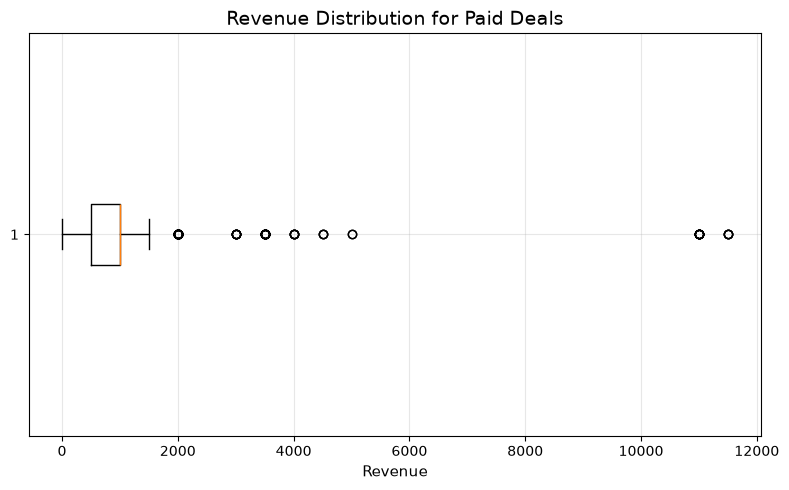

In [63]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    deals_with_revenue['Revenue'].dropna(),
    vert=False
)

plt.xlabel('Revenue')
plt.title('Revenue Distribution for Paid Deals')
plt.tight_layout()
plt.show()

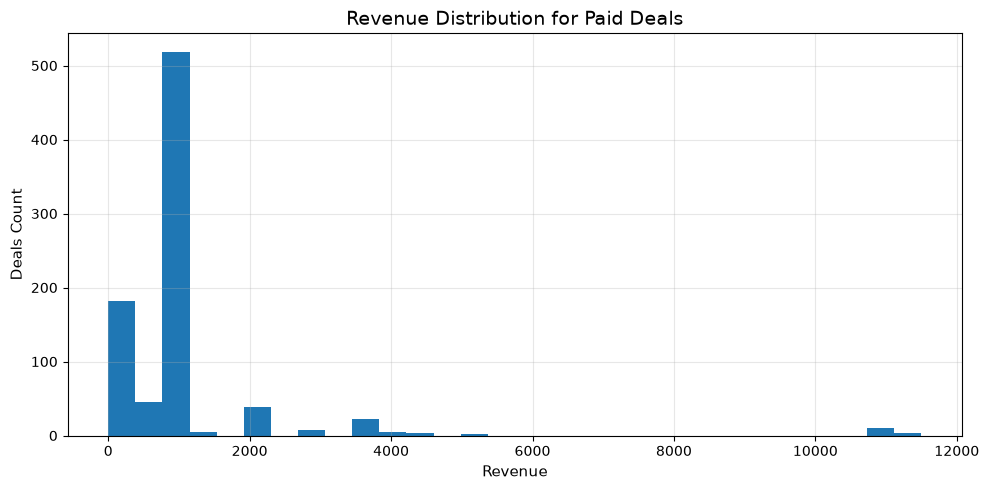

In [64]:
plt.figure(figsize=(10, 5))

plt.hist(
    deals_with_revenue['Revenue'].dropna(),
    bins=30
)

plt.xlabel('Revenue')
plt.ylabel('Deals Count')
plt.title('Revenue Distribution for Paid Deals')
plt.tight_layout()
plt.show()

/var/folders/rr/1fh34nmj2wg6nb7cz3t9_4kr0000gn/T/ipykernel_10964/1033957713.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


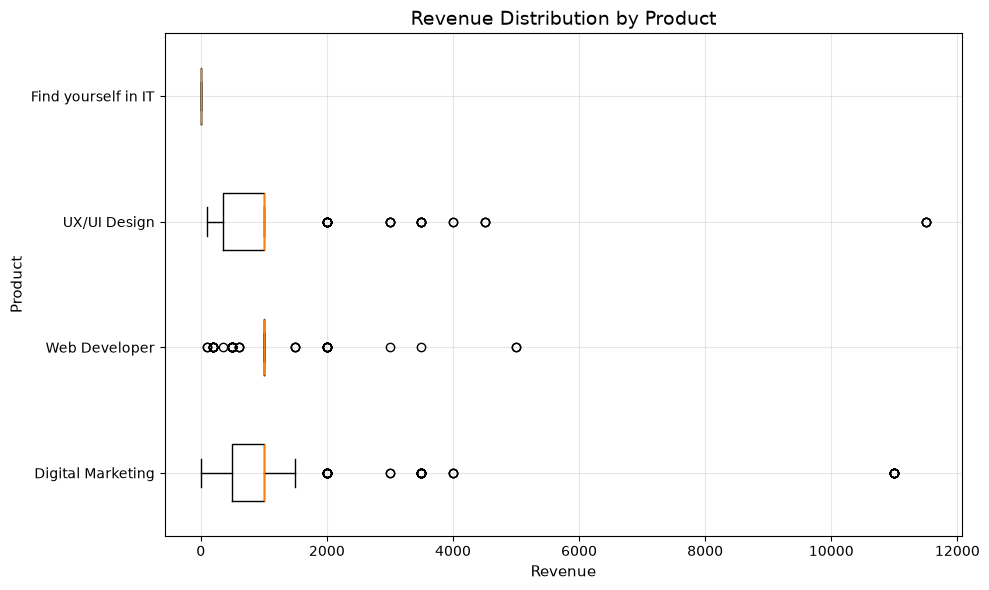

In [65]:
revenue_by_product_boxplot = deals_with_revenue[
    deals_with_revenue['Product'].notna()
].copy()

revenue_by_product_boxplot = revenue_by_product_boxplot[
    revenue_by_product_boxplot['Product'] != 'Unknown'
]

products = revenue_by_product_boxplot['Product'].dropna().unique()

product_revenue_data = [
    revenue_by_product_boxplot[
        revenue_by_product_boxplot['Product'] == product
    ]['Revenue'].dropna()
    for product in products
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    product_revenue_data,
    tick_labels=products,
    vert=False
)

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Revenue Distribution by Product')
plt.tight_layout()
plt.show()

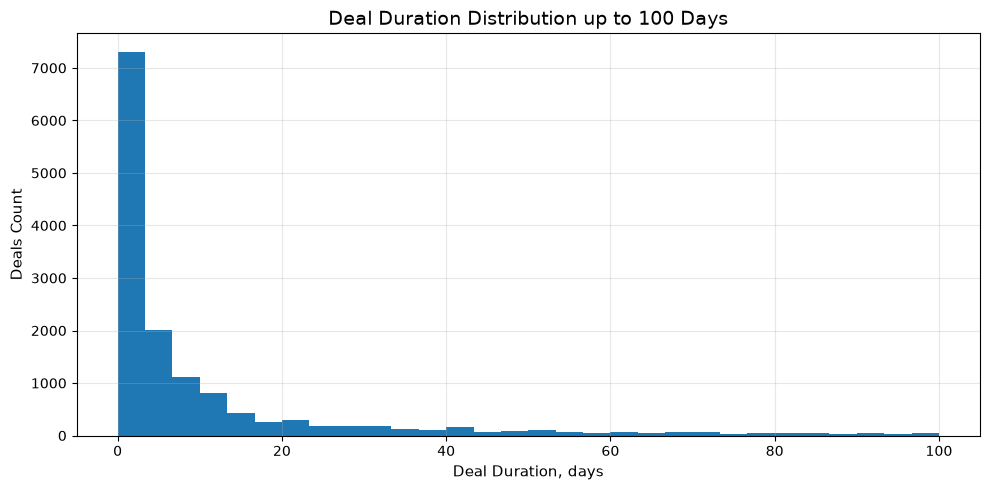

In [66]:
deal_duration_limited = valid_deal_duration[
    valid_deal_duration['Deal Duration Days'] <= 100
].copy()

plt.figure(figsize=(10, 5))

plt.hist(
    deal_duration_limited['Deal Duration Days'].dropna(),
    bins=30
)

plt.xlabel('Deal Duration, days')
plt.ylabel('Deals Count')
plt.title('Deal Duration Distribution up to 100 Days')
plt.tight_layout()
plt.show()

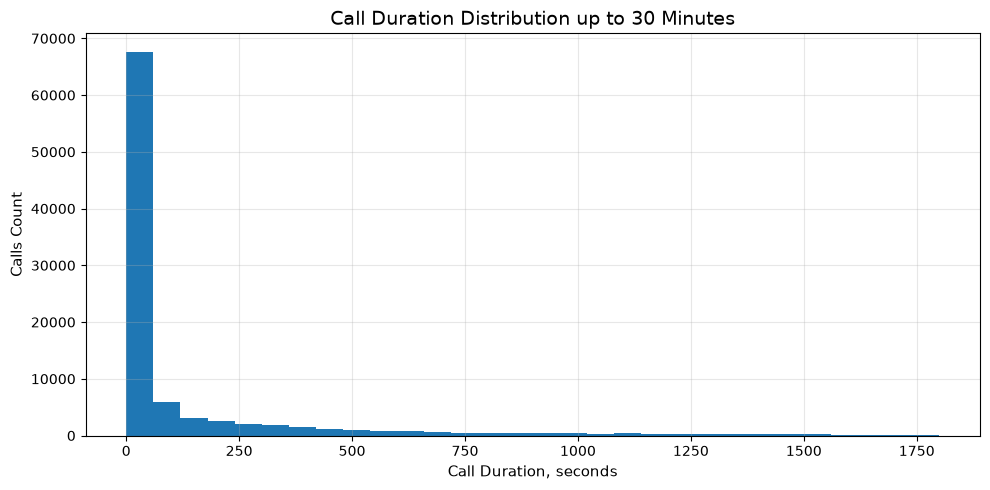

In [67]:
call_duration_limited = valid_calls_duration[
    valid_calls_duration['Call Duration (in seconds)'] <= 1800
].copy()

plt.figure(figsize=(10, 5))

plt.hist(
    call_duration_limited['Call Duration (in seconds)'].dropna(),
    bins=30
)

plt.xlabel('Call Duration, seconds')
plt.ylabel('Calls Count')
plt.title('Call Duration Distribution up to 30 Minutes')
plt.tight_layout()
plt.show()

### Numeric Statistics Summary

**Deals.** Financial fields show a clear difference between averages and medians. The median `Initial Amount Paid` is 1,000, while the average is around 950. This means that a typical first payment is close to 1,000, although the dataset also contains larger payments.

The median `Offer Total Amount` is 11,000, which reflects the typical full offer value. `Initial Amount Paid` is materially lower than `Offer Total Amount`, which is consistent with the business logic: the first payment may represent only part of the total course price.

`Revenue` is calculated only for deals with `Payment Done` and a recorded payment amount. The number of revenue values is lower than the number of paid deals because some paid deals do not have a fixed payment amount in CRM.

`Deal Duration Days` has a median of 4 days and an average of about 15 days. This indicates a right-skewed distribution: most deals close relatively quickly, while a smaller number of long deals increases the average.

---

**Spend.** Marketing metrics also show high variability. Median values of `Impressions`, `Spend` and `Clicks` are much lower than their averages, which indicates that some rows or campaigns have much higher advertising activity. Therefore, marketing performance should be analyzed by source and campaign, not only at the total table level.

The average `CPC` is about 0.68, while the median is about 0.49. A typical click is cheaper than the average value, while a subset of more expensive clicks increases the mean.

---

**Calls.** The median call duration is 8 seconds, while the average is about 165 seconds. Most calls are very short, but several long calls significantly increase the average. For call analysis, it is important to review the duration distribution and the share of short calls separately.

## Categorical Descriptive Statistics

This section reviews the distribution of key categorical fields.

These fields are used in the following business analysis sections: sales funnel, sources, lead quality, products, payment types, managers, cities and German language level.

In [68]:
# `Stage` shows the current deal status and is the main field for funnel analysis and paid deal identification.

categorical_summary(deals, 'Stage')

,Stage,Count,"Share, %"
0,Lost,15743,72.91
1,Call Delayed,2248,10.41
2,Registered on Webinar,2072,9.60
3,Payment Done,858,3.97
4,Waiting For Payment,325,1.51
5,Qualificated,128,0.59
6,Registered on Offline Day,100,0.46
7,Need to Call - Sales,33,0.15
8,Need To Call,31,0.14
9,Test Sent,25,0.12


In [69]:
# `Quality` reflects lead quality based on the sales team's assessment and is used to analyze lead quality by source and campaign.

categorical_summary(deals, 'Quality')

,Quality,Count,"Share, %"
0,E - Non Qualified,7634,35.35
1,D - Non Target,6248,28.94
2,C - Low,3459,16.02
3,Unknown,2253,10.43
4,B - Medium,1564,7.24
5,A - High,432,2.00
6,F,3,0.01


In [70]:
# `Source` shows the acquisition channel and is the main level for linking deals with marketing spend.

categorical_summary(deals, 'Source')

,Source,Count,"Share, %"
0,Facebook Ads,4850,22.46
1,Google Ads,4226,19.57
2,Organic,2590,11.99
3,Tiktok Ads,2051,9.50
4,SMM,1730,8.01
5,Youtube Ads,1657,7.67
6,CRM,1656,7.67
7,Bloggers,1089,5.04
8,Telegram posts,1001,4.64
9,Webinar,379,1.76


In [71]:
# `Product` is used to analyze product popularity, payments and revenue.
# `Unknown` marks paid deals where the product was not recorded in CRM.

categorical_summary(deals, 'Product')

,Product,Count,"Share, %"
0,NaN,17984,83.29
1,Digital Marketing,1990,9.22
2,UX/UI Design,1022,4.73
3,Web Developer,575,2.66
4,Unknown,17,0.08
5,Find yourself in IT,4,0.02
6,Data Analytics,1,0.00


In [72]:
# `Education Type` shows the education format and is used to analyze customer preferences and format performance.

categorical_summary(deals, 'Education Type')

,Education Type,Count,"Share, %"
0,NaN,18269,84.61
1,Morning,2895,13.41
2,Evening,404,1.87
3,Unknown,25,0.12


In [73]:
# `Payment Type` is used to analyze payment methods. `Unknown` marks paid deals where the payment type was not recorded.

categorical_summary(deals, 'Payment Type')

,Payment Type,Count,"Share, %"
0,NaN,20603,95.42
1,Unknown,494,2.29
2,Recurring Payments,350,1.62
3,One Payment,141,0.65
4,Reservation,5,0.02


In [74]:
# `Deal Owner Name` shows the manager responsible for the deal and is used for sales team performance analysis.

categorical_summary(deals, 'Deal Owner Name')

,Deal Owner Name,Count,"Share, %"
0,Charlie Davis,2963,13.72
1,Julia Nelson,2241,10.38
2,Ulysses Adams,2165,10.03
3,Quincy Vincent,1884,8.73
4,Paula Underwood,1862,8.62
5,Ben Hall,1345,6.23
6,Nina Scott,1283,5.94
7,Victor Barnes,1232,5.71
8,Cara Iverson,1056,4.89
9,Diana Evans,1013,4.69


In [75]:
# `City` is used for geographic analysis. Since there are many cities, I first review the top 20 values.

categorical_summary(deals, 'City', top_n=20)

,City,Count,"Share, %"
0,Unknown,19430,89.98
1,Berlin,182,0.84
2,München,74,0.34
3,Hamburg,62,0.29
4,Nürnberg,45,0.21
5,Leipzig,45,0.21
6,Düsseldorf,33,0.15
7,Dresden,28,0.13
8,Frankfurt,27,0.13
9,Dortmund,26,0.12


In [76]:
# `Level of Deutsch` is used to analyze the relationship between German language level and deal success.
# `Unknown` means that reliable language-level information is missing.

categorical_summary(deals, 'Level of Deutsch')

,Level of Deutsch,Count,"Share, %"
0,Unknown,21096,97.70
1,B1,382,1.77
2,B2,76,0.35
3,A2,28,0.13
4,A1,6,0.03
5,C1,4,0.02
6,C2,1,0.00


### Categorical Fields Summary

The categorical analysis shows that the deal funnel is heavily shifted toward lost leads. The largest stage is `Lost`: 15,743 deals, or 72.91% of all deals. `Payment Done`, which represents confirmed payment according to the business rules, accounts for 858 deals, or 3.97%. This means that further analysis should focus not only on lead volume, but also on factors that influence conversion to payment.

Lead quality is also an important limitation. `E - Non Qualified` and `D - Non Target` together account for more than 64% of all deals. High-quality leads represent a much smaller share: `A - High` is 2.00% and `B - Medium` is 7.24%.

Paid acquisition channels generate the largest share of leads. The leading sources are `Facebook Ads`, `Google Ads`, `Organic`, `Tiktok Ads`, `SMM`, `Youtube Ads` and `CRM`. This confirms that `Source` is a key level for marketing analysis.

`Product`, `Education Type` and `Payment Type` are not filled for all deals, which is consistent with CRM logic: these fields become more relevant for paid deals and later funnel stages. Because of this, product and payment analysis should focus primarily on paid deals.

Manager workload is distributed unevenly. The largest number of deals is assigned to Charlie Davis, Julia Nelson, Ulysses Adams, Quincy Vincent and Paula Underwood. At this stage, this only reflects processed volume, not effectiveness; conversion, revenue and SLA need to be analyzed separately.

Geography and German language level have strong data quality limitations. `City = Unknown` accounts for 89.98% of all deals, and `Level of Deutsch = Unknown` accounts for 97.70%. These fields can still be used for additional cuts, but conclusions should be interpreted carefully.

Overall, categorical statistics point to three key analytical directions: lead quality by source, acquisition channel performance and sales manager effectiveness.

## Core Business Metrics

After descriptive statistics, I summarize the main business metrics for deals, payments and revenue.

This section sets the context for further analysis: total deals, paid deals, overall payment conversion and recorded CRM revenue.

In [77]:
basic_business_metrics = {
    'Total Deals': deals.shape[0],
    'Paid Deals': paid_deals.shape[0],
    'Payment Conversion, %': round(paid_deals.shape[0] / deals.shape[0] * 100, 2),
    'Deals with Calculated Revenue': deals_with_revenue.shape[0],
    'Total Revenue': deals_with_revenue['Revenue'].sum(),
    'Average Check': deals_with_revenue['Revenue'].mean(),
    'Median Check': deals_with_revenue['Revenue'].median(),
    'Payment Done without Payment Amount': deals['Unknown Payment Amount'].sum(),
    'Symbolic Payments': deals['Is Symbolic Payment'].sum()
}

basic_business_metrics_df = pd.DataFrame(
    basic_business_metrics.items(),
    columns=['Metric', 'Value']
)

basic_business_metrics_df

,Metric,Value
0,Total Deals,"21,593.00"
1,Paid Deals,858.00
2,"Payment Conversion, %",3.97
3,Deals with Calculated Revenue,843.00
4,Total Revenue,"978,651.00"
5,Average Check,"1,160.91"
6,Median Check,"1,000.00"
7,Payment Done without Payment Amount,15.00
8,Symbolic Payments,4.00


### Core Business Metrics Summary

The cleaned `Deals` table contains 21,593 deals. Of these, 858 deals have the `Payment Done` status and are treated as paid according to the project business rules.

Overall payment conversion is 3.97%, which means the funnel is wide at the top but only a small share of deals reaches payment.

Revenue is calculated for 843 paid deals. Another 15 deals have `Payment Done` status but no recorded payment amount; they are included in conversion, but excluded from revenue and average check calculations.

Total recorded revenue is 978,651. The average check is 1,160.91, while the median check is 1,000.00. The average is slightly higher than the median because some payments are larger.

There are also 4 symbolic payments. They are kept in the analysis because, according to the business rules, they may represent demo access or symbolic payments. If needed, the average check can be analyzed separately without them.

The key task of the following analysis is to understand which sources, managers, products and lead characteristics are associated with stronger conversion and revenue.

## Sales Funnel Analysis

This section analyzes the distribution of deals across funnel stages.

The goal is to understand how deals are distributed, what share reaches payment and which stages account for most unsuccessful deals.

In [78]:
stage_summary = (
    deals
    .groupby('Stage', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

stage_summary['Share, %'] = (
    stage_summary['deals_count'] / stage_summary['deals_count'].sum() * 100
).round(2)

stage_summary['Payment Conversion, %'] = (
    stage_summary['paid_deals'] / stage_summary['deals_count'] * 100
).round(2)

stage_summary = (
    stage_summary
    .sort_values('deals_count', ascending=False)
    .rename(columns={
        'deals_count': 'Deals Count',
        'paid_deals': 'Paid Deals',
        'revenue': 'Revenue'
    })
)

stage_summary

,Stage,Deals Count,Paid Deals,Revenue,"Share, %","Payment Conversion, %"
2,Lost,15743,0,0.00,72.91,0.00
0,Call Delayed,2248,0,0.00,10.41,0.00
10,Registered on Webinar,2072,0,0.00,9.60,0.00
7,Payment Done,858,858,"978,651.00",3.97,100.00
12,Waiting For Payment,325,0,0.00,1.51,0.00
8,Qualificated,128,0,0.00,0.59,0.00
9,Registered on Offline Day,100,0,0.00,0.46,0.00
5,Need to Call - Sales,33,0,0.00,0.15,0.00
3,Need To Call,31,0,0.00,0.14,0.00
11,Test Sent,25,0,0.00,0.12,0.00


In [79]:
funnel_metrics = {
    'Total Deals': deals.shape[0],
    'Paid Deals: Payment Done': paid_deals.shape[0],
    'Overall Payment Conversion, %': round(paid_deals.shape[0] / deals.shape[0] * 100, 2),
    'Lost Deals': (deals['Stage'] == 'Lost').sum(),
    'Lost Share, %': round((deals['Stage'] == 'Lost').mean() * 100, 2)
}

pd.DataFrame(
    funnel_metrics.items(),
    columns=['Metric', 'Value']
)

,Metric,Value
0,Total Deals,"21,593.00"
1,Paid Deals: Payment Done,858.00
2,"Overall Payment Conversion, %",3.97
3,Lost Deals,"15,743.00"
4,"Lost Share, %",72.91


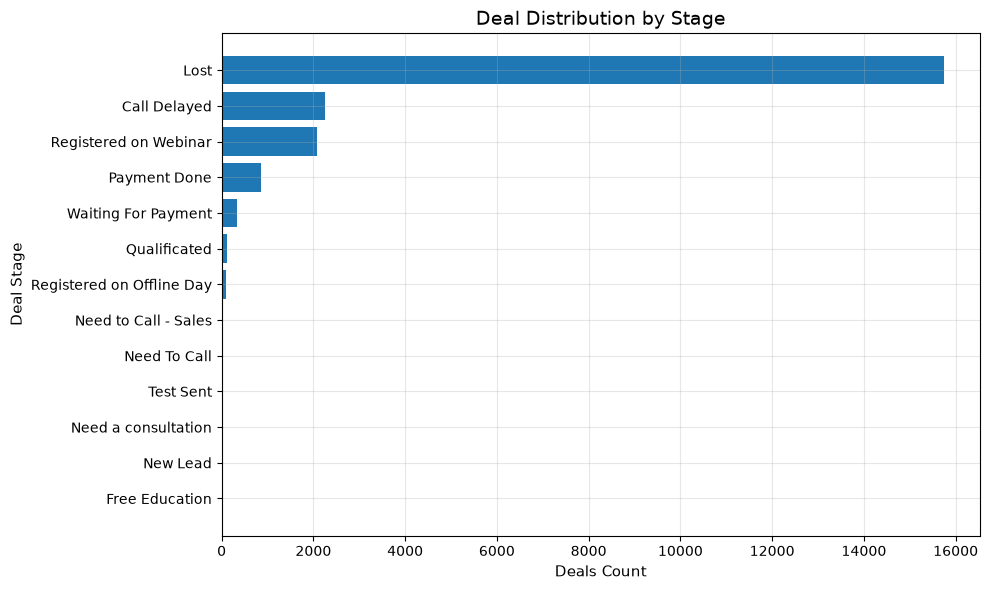

In [80]:
stage_plot_data = stage_summary.sort_values('Deals Count', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(stage_plot_data['Stage'], stage_plot_data['Deals Count'])
plt.xlabel('Deals Count')
plt.ylabel('Deal Stage')
plt.title('Deal Distribution by Stage')
plt.tight_layout()
plt.show()

### Sales Funnel Summary

The sales funnel is strongly shifted toward lost deals.

After cleaning, the dataset contains 21,593 deals. Of these, 15,743 deals are in `Lost`, representing 72.91% of the funnel. This means that most leads do not reach payment.

There are 858 paid deals with `Payment Done`, or 3.97% of all deals. This stage is used as the payment fact in the project. Total recorded revenue for paid deals is 978,651.

Intermediate stages also have meaningful volume: `Call Delayed` accounts for 10.41% and `Registered on Webinar` for 9.60%. These may be important areas for deeper analysis because they include leads that have not yet reached a final outcome.

The funnel confirms that improving business performance requires more than increasing lead volume. Lead quality, sales speed, manager performance and movement toward payment are also critical.

## Time Series Analysis

This section analyzes deal and call dynamics over time.

The goals are to:

- review monthly deal creation dynamics;
- compare all deals with paid deals;
- evaluate monthly sales call activity;
- compare deal creation and calls at the monthly level;
- review deal closing dynamics;
- analyze the duration from deal creation to closing.

In [81]:
# Create deal creation month
deals['Created Month'] = deals['Created Date'].dt.to_period('M').dt.to_timestamp()

# Create deal closing month
deals['Closing Month'] = deals['Closing Date Only'].dt.to_period('M').dt.to_timestamp()

# Create call month
calls['Call Month'] = calls['Call Start Time'].dt.to_period('M').dt.to_timestamp()

### Deal Creation and Paid Deal Dynamics

I review how the number of created deals and paid deals changed by month.

Paid deals are defined by the rule `Stage == Payment Done`.

In [82]:
monthly_deals = (
    deals
    .groupby('Created Month', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

monthly_deals['Payment Conversion, %'] = (
    monthly_deals['paid_deals'] / monthly_deals['deals_count'] * 100
).round(2)

monthly_deals = monthly_deals.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

monthly_deals

,Created Month,Deals Count,Paid Deals,Revenue,"Payment Conversion, %"
0,2023-07-01,654,10,"7,150.00",1.53
1,2023-08-01,1085,49,"32,200.00",4.52
2,2023-09-01,1079,53,"41,350.00",4.91
3,2023-10-01,1598,86,"75,600.00",5.38
4,2023-11-01,1947,104,"107,400.00",5.34
5,2023-12-01,1811,105,"89,100.00",5.80
6,2024-01-01,2243,114,"128,150.00",5.08
7,2024-02-01,2184,72,"84,900.00",3.30
8,2024-03-01,2252,100,"111,400.00",4.44
9,2024-04-01,3082,76,"144,101.00",2.47


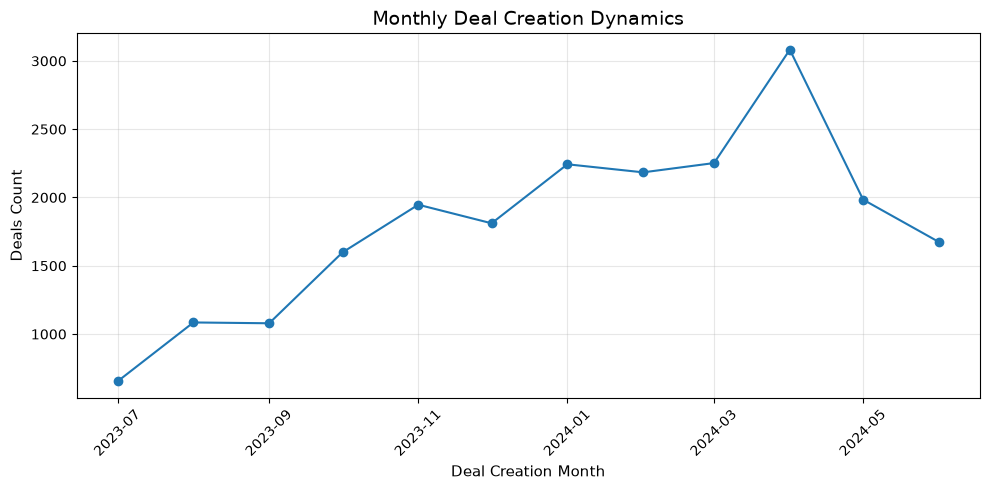

In [83]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_deals['Created Month'],
    monthly_deals['Deals Count'],
    marker='o'
)

plt.xlabel('Deal Creation Month')
plt.ylabel('Deals Count')
plt.title('Monthly Deal Creation Dynamics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

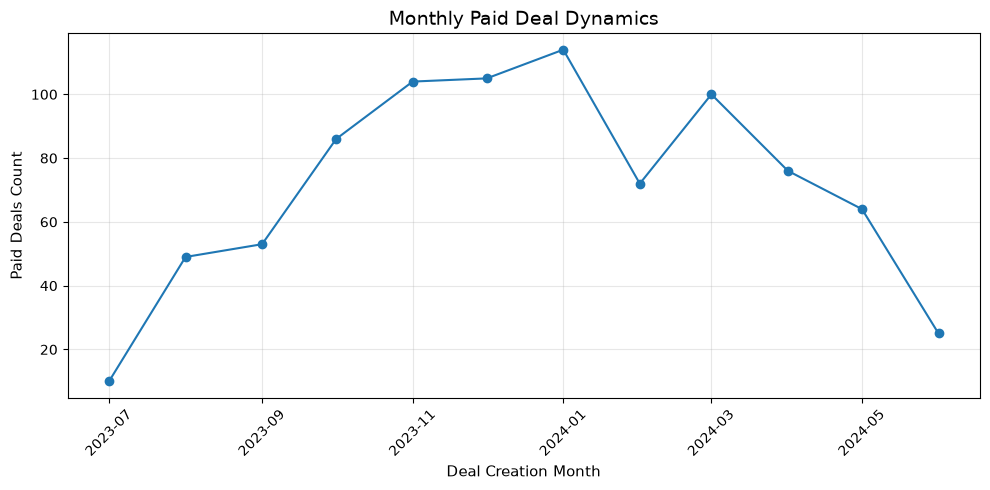

In [84]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_deals['Created Month'],
    monthly_deals['Paid Deals'],
    marker='o'
)

plt.xlabel('Deal Creation Month')
plt.ylabel('Paid Deals Count')
plt.title('Monthly Paid Deal Dynamics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

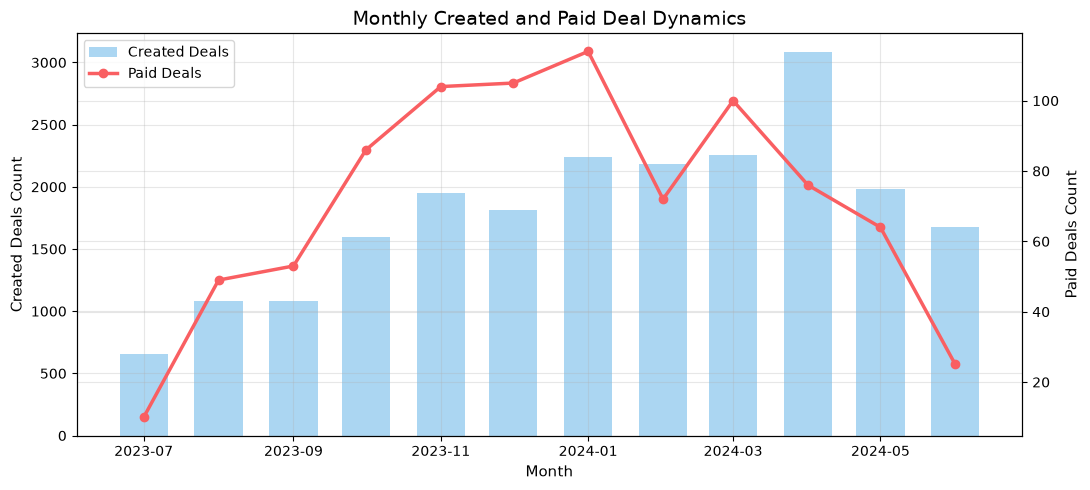

In [85]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.bar(
    monthly_deals['Created Month'],
    monthly_deals['Deals Count'],
    width=20,
    label='Created Deals',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Created Deals Count')

ax2 = ax1.twinx()

ax2.plot(
    monthly_deals['Created Month'],
    monthly_deals['Paid Deals'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Paid Deals'
)

ax2.set_ylabel('Paid Deals Count')

plt.title('Monthly Created and Paid Deal Dynamics')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

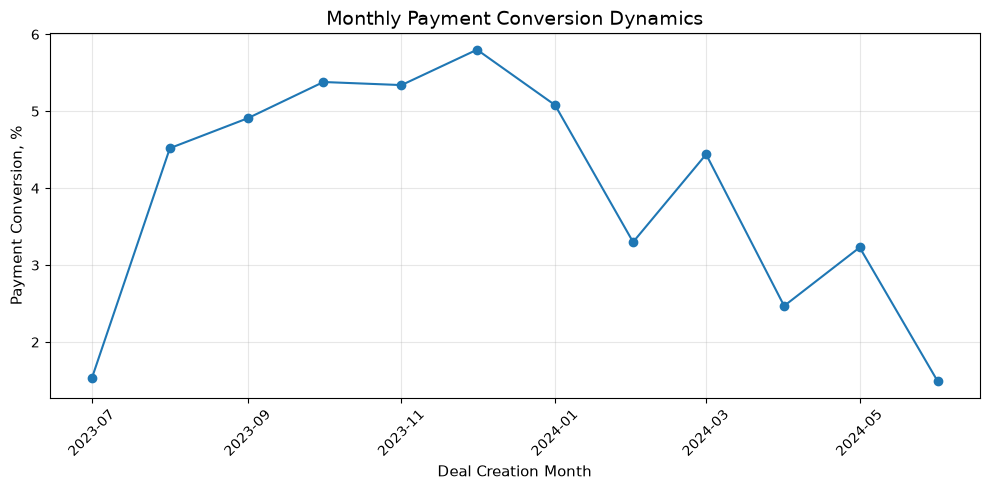

In [86]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_deals['Created Month'],
    monthly_deals['Payment Conversion, %'],
    marker='o'
)

plt.xlabel('Deal Creation Month')
plt.ylabel('Payment Conversion, %')
plt.title('Monthly Payment Conversion Dynamics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Call Dynamics

I review how sales call activity changed over time.

The analysis uses all calls recorded in the `Calls` table.

In [87]:
monthly_calls = (
    calls
    .groupby('Call Month', dropna=False)
    .agg(
        calls_count=('Id', 'count')
    )
    .reset_index()
)

monthly_calls = monthly_calls.rename(columns={
    'calls_count': 'Calls Count'
})

monthly_calls

,Call Month,Calls Count
0,2023-06-01,7
1,2023-07-01,1935
2,2023-08-01,4251
3,2023-09-01,5156
4,2023-10-01,7102
5,2023-11-01,7170
6,2023-12-01,7099
7,2024-01-01,9804
8,2024-02-01,9599
9,2024-03-01,10081


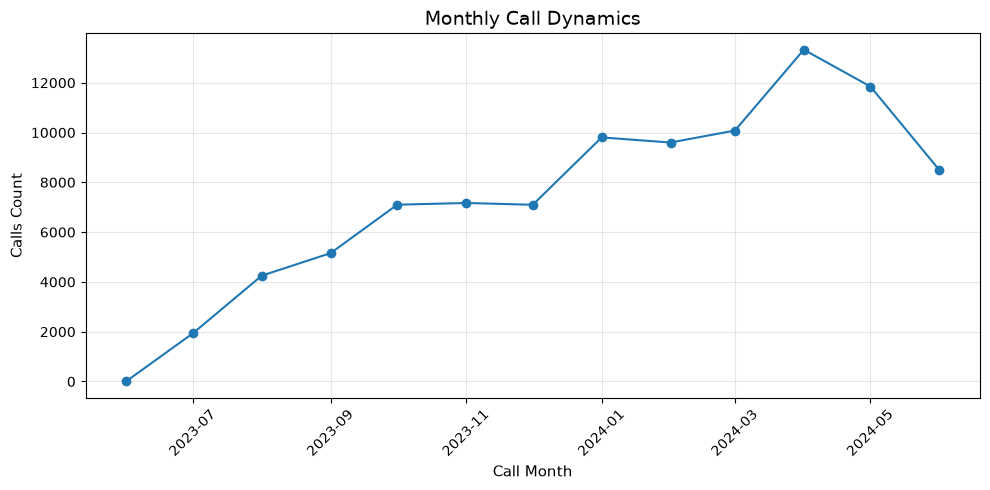

In [88]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_calls['Call Month'],
    monthly_calls['Calls Count'],
    marker='o'
)

plt.xlabel('Call Month')
plt.ylabel('Calls Count')
plt.title('Monthly Call Dynamics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Relationship Between Deal and Call Dynamics

I compare created deals and calls at the monthly level.

This is an aggregated check. It does not link each call to a specific deal, but helps understand whether sales activity changed together with the deal flow.

In [89]:
monthly_deals_calls = monthly_deals.merge(
    monthly_calls,
    left_on='Created Month',
    right_on='Call Month',
    how='outer'
)

monthly_deals_calls['Month'] = monthly_deals_calls['Created Month'].combine_first(
    monthly_deals_calls['Call Month']
)

monthly_deals_calls = (
    monthly_deals_calls
    .sort_values('Month')
    .drop(columns=['Created Month', 'Call Month'])
)

monthly_deals_calls = monthly_deals_calls[
    ['Month', 'Deals Count', 'Paid Deals', 'Payment Conversion, %', 'Revenue', 'Calls Count']
]

monthly_deals_calls

,Month,Deals Count,Paid Deals,"Payment Conversion, %",Revenue,Calls Count
0,2023-06-01,NaN,NaN,NaN,NaN,7
1,2023-07-01,654.00,10.00,1.53,"7,150.00",1935
2,2023-08-01,"1,085.00",49.00,4.52,"32,200.00",4251
3,2023-09-01,"1,079.00",53.00,4.91,"41,350.00",5156
4,2023-10-01,"1,598.00",86.00,5.38,"75,600.00",7102
5,2023-11-01,"1,947.00",104.00,5.34,"107,400.00",7170
6,2023-12-01,"1,811.00",105.00,5.80,"89,100.00",7099
7,2024-01-01,"2,243.00",114.00,5.08,"128,150.00",9804
8,2024-02-01,"2,184.00",72.00,3.30,"84,900.00",9599
9,2024-03-01,"2,252.00",100.00,4.44,"111,400.00",10081


In [90]:
# For the chart, keep only months with deals.
# June 2023 contains only calls and is outside the main deal analysis period.

monthly_deals_calls_plot = monthly_deals_calls[
    monthly_deals_calls['Deals Count'].notna()
].copy()

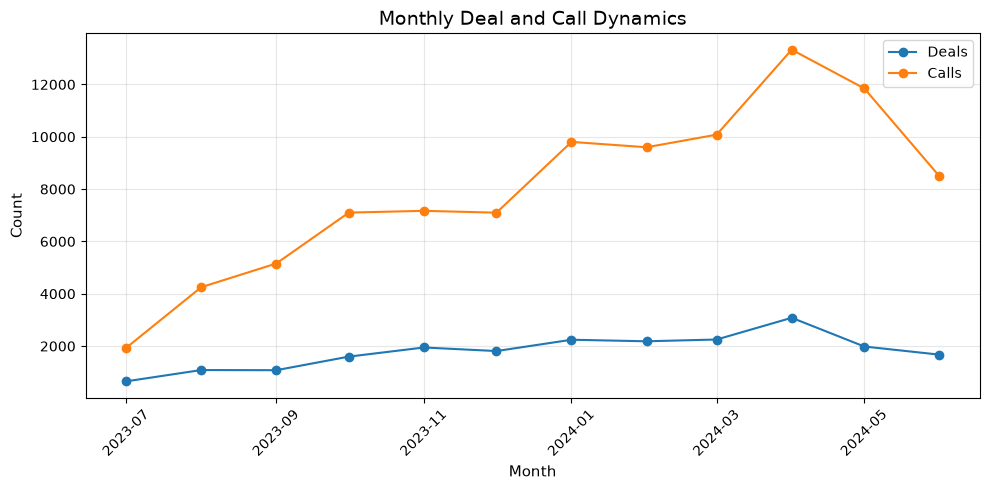

In [91]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_deals_calls_plot['Month'],
    monthly_deals_calls_plot['Deals Count'],
    marker='o',
    label='Deals'
)

plt.plot(
    monthly_deals_calls_plot['Month'],
    monthly_deals_calls_plot['Calls Count'],
    marker='o',
    label='Calls'
)

plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Monthly Deal and Call Dynamics')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

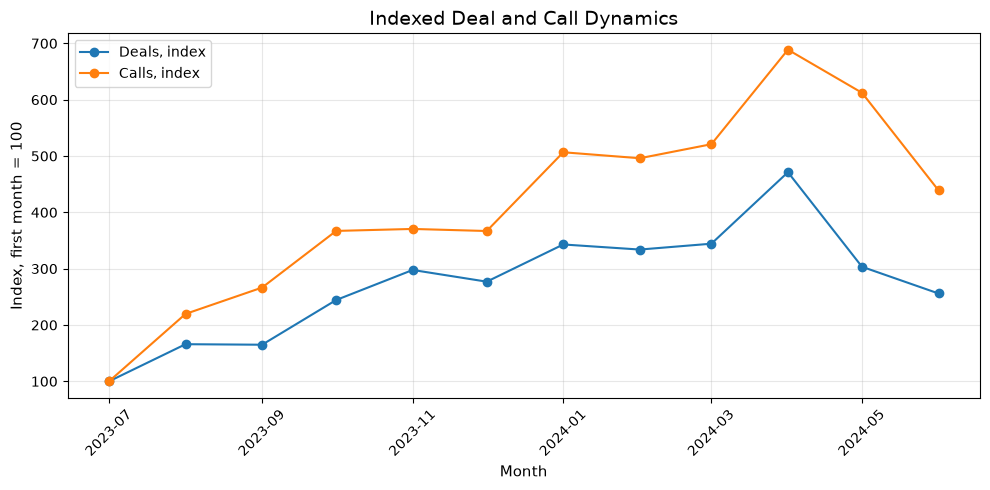

In [92]:
monthly_deals_calls_index = monthly_deals_calls_plot.copy()

monthly_deals_calls_index = monthly_deals_calls_index[
    monthly_deals_calls_index['Deals Count'].notna() &
    monthly_deals_calls_index['Calls Count'].notna()
].copy()

monthly_deals_calls_index['Deals Index'] = (
    monthly_deals_calls_index['Deals Count'] /
    monthly_deals_calls_index['Deals Count'].iloc[0] * 100
)

monthly_deals_calls_index['Calls Index'] = (
    monthly_deals_calls_index['Calls Count'] /
    monthly_deals_calls_index['Calls Count'].iloc[0] * 100
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_deals_calls_index['Month'],
    monthly_deals_calls_index['Deals Index'],
    marker='o',
    label='Deals, index'
)

plt.plot(
    monthly_deals_calls_index['Month'],
    monthly_deals_calls_index['Calls Index'],
    marker='o',
    label='Calls, index'
)

plt.xlabel('Month')
plt.ylabel('Index, first month = 100')
plt.title('Indexed Deal and Call Dynamics')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Monthly correlation shows only the overall relationship between metric dynamics. It does not prove a causal relationship between calls and payments.

In [93]:
deals_calls_corr = monthly_deals_calls_plot[
    ['Deals Count', 'Calls Count', 'Paid Deals']
].corr()

deals_calls_corr

,Deals Count,Calls Count,Paid Deals
Deals Count,1.00,0.93,0.61
Calls Count,0.93,1.00,0.47
Paid Deals,0.61,0.47,1.00


### Deal Closing Dynamics

I review how closed deals are distributed by closing month.

Because `Closing Date` is not filled for every deal, the analysis uses only rows with a recorded closing date.

In [94]:
monthly_closed_deals = (
    deals[deals['Closing Month'].notna()]
    .groupby('Closing Month')
    .agg(
        closed_deals=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

monthly_closed_deals = monthly_closed_deals.rename(columns={
    'closed_deals': 'Closed Deals',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

monthly_closed_deals

,Closing Month,Closed Deals,Paid Deals,Revenue
0,2022-10-01,1,0,0.00
1,2023-07-01,357,3,"2,000.00"
2,2023-08-01,702,28,"15,600.00"
3,2023-09-01,683,28,"18,950.00"
4,2023-10-01,1416,32,"30,700.00"
5,2023-11-01,1381,50,"46,000.00"
6,2023-12-01,1075,38,"34,250.00"
7,2024-01-01,1342,59,"55,500.00"
8,2024-02-01,1450,52,"55,650.00"
9,2024-03-01,1560,59,"61,900.00"


In [95]:
# For the closing chart, keep the main analysis period.
# Single closing dates outside the deal creation period are not removed from the dataset,
# but they are not used in this chart to avoid distorting visual dynamics.

closed_deals_plot = monthly_closed_deals[
    (monthly_closed_deals['Closing Month'] >= monthly_deals['Created Month'].min()) &
    (monthly_closed_deals['Closing Month'] <= monthly_deals['Created Month'].max())
].copy()

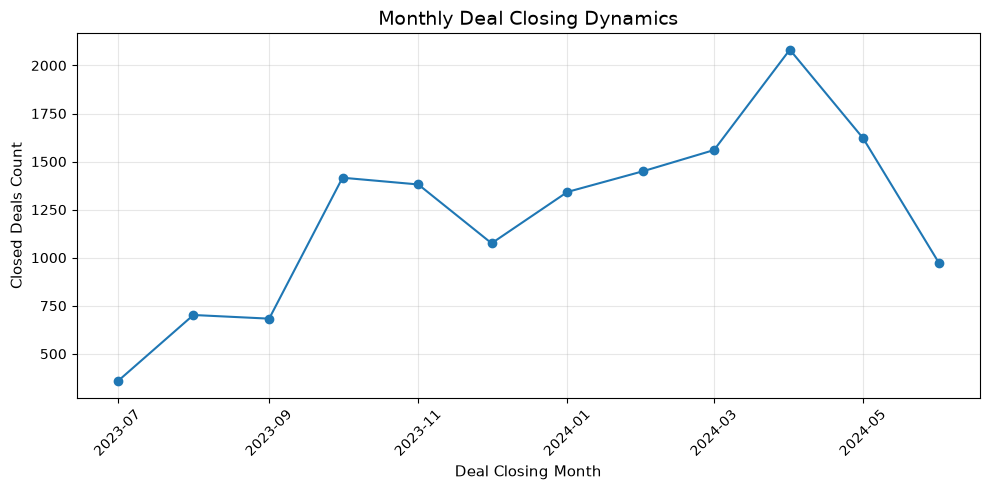

In [96]:
plt.figure(figsize=(10, 5))

plt.plot(
    closed_deals_plot['Closing Month'],
    closed_deals_plot['Closed Deals'],
    marker='o'
)

plt.xlabel('Deal Closing Month')
plt.ylabel('Closed Deals Count')
plt.title('Monthly Deal Closing Dynamics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Deal Duration from Creation to Closing

I analyze the duration between deal creation and deal closing.

Only rows with valid date logic are used:

- closing date is not earlier than creation date;
- `Deal Duration Days` is filled.

In [97]:
numeric_summary(valid_deal_duration, ['Deal Duration Days'])

,Field,Non-Missing Values,Mean,Median,Mode,Minimum,Maximum,Range
0,Deal Duration Days,14601,15.01,4.00,0.00,0.00,335.00,335.00


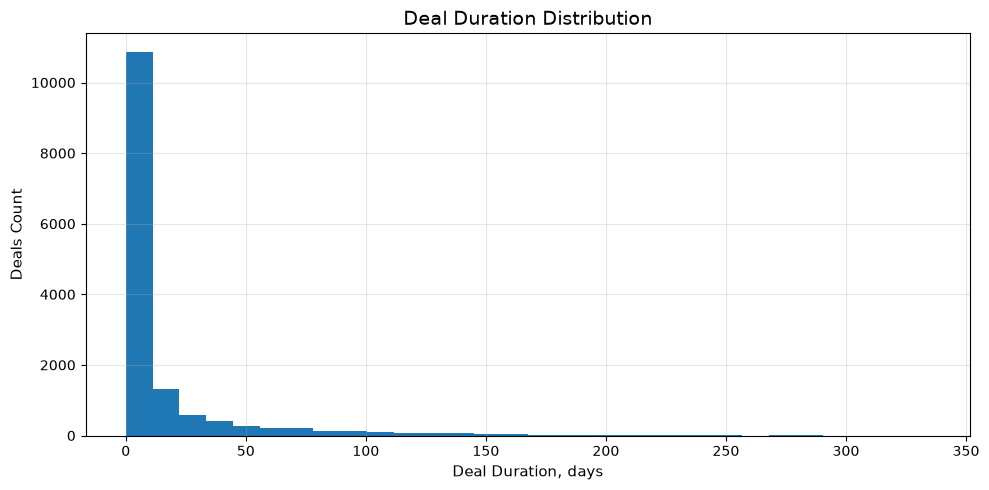

In [98]:
plt.figure(figsize=(10, 5))
plt.hist(valid_deal_duration['Deal Duration Days'].dropna(), bins=30)
plt.xlabel('Deal Duration, days')
plt.ylabel('Deals Count')
plt.title('Deal Duration Distribution')
plt.tight_layout()
plt.show()

### Deal Duration by Payment Status

I compare deal duration for paid and unpaid deals.

This helps understand whether deals that reach payment differ in closing time.

In [99]:
deal_duration_by_payment = (
    valid_deal_duration
    .groupby('Is Paid')
    .agg(
        deals_count=('Id', 'count'),
        avg_duration_days=('Deal Duration Days', 'mean'),
        median_duration_days=('Deal Duration Days', 'median'),
        min_duration_days=('Deal Duration Days', 'min'),
        max_duration_days=('Deal Duration Days', 'max')
    )
    .reset_index()
)

deal_duration_by_payment['Payment Status'] = np.where(
    deal_duration_by_payment['Is Paid'],
    'Payment Done',
    'Not Paid'
)

deal_duration_by_payment = deal_duration_by_payment.rename(columns={
    'deals_count': 'Deals Count',
    'avg_duration_days': 'Avg Duration Days',
    'median_duration_days': 'Median Duration Days',
    'min_duration_days': 'Min Duration Days',
    'max_duration_days': 'Max Duration Days'
})

deal_duration_by_payment = deal_duration_by_payment[
    ['Payment Status', 'Deals Count', 'Avg Duration Days', 'Median Duration Days', 'Min Duration Days', 'Max Duration Days']
]

deal_duration_by_payment

,Payment Status,Deals Count,Avg Duration Days,Median Duration Days,Min Duration Days,Max Duration Days
0,Not Paid,14084,14.33,3.00,0.00,335.00
1,Payment Done,517,33.55,17.00,0.00,305.00


### Time Series Analysis Summary

The flow of created deals increased from July 2023 and reached its maximum in April 2024, when 3,082 deals were created. After April, the number of created deals declined: 1,984 in May and 1,674 in June.

Paid deal dynamics do not fully repeat the total deal dynamics. The highest number of paid deals was observed in January 2024, with 114 paid deals. In April 2024, despite the maximum number of created deals, only 76 deals were paid. This shows that lead growth does not automatically produce proportional payment growth.

Payment conversion was higher in the second half of 2023 and in January 2024. The maximum conversion was in December 2023 at 5.80%. After January 2024, conversion became more unstable and decreased to 2.47% in April and 1.49% in June. This may be related to changes in lead quality, source mix, sales team workload or seasonality.

Call dynamics generally increased together with deal volume. The highest call activity was observed in April 2024, with 13,328 calls. Monthly correlation between deals and calls is high at 0.93, which means sales activity followed the incoming deal flow.

The relationship between calls and paid deals is weaker: the correlation between `Calls Count` and `Paid Deals` is 0.47. Call volume alone is not enough to explain payment growth; lead quality, source, manager, product and response speed also matter.

Deal duration is right-skewed. Median deal duration is 4 days, while the average is about 15 days. Paid deals close more slowly: the median duration for `Payment Done` is 17 days, compared with 3 days for unpaid deals. This may indicate that successful deals require a longer decision cycle and more customer support.

## Marketing Performance Analysis

This section analyzes marketing sources and campaigns.

The analysis covers:

- campaigns that generate the largest lead volume;
- campaigns with higher payment conversion;
- sources that generate deals and paid deals;
- sources that generate higher-quality leads;
- the relationship between spend, leads, payments and revenue at the `Source` level.

The main join level between `Deals` and `Spend` is `Source`. `Campaign` is used as additional detail because campaign matching between the tables is partial.

### Quality Lead Flag

For lead quality analysis, I create the `Is Quality Lead` flag.

The following quality categories are treated as quality leads:

- `A - High`;
- `B - Medium`;
- `C - Low`.

`D - Non Target`, `E - Non Qualified`, `F` and `Unknown` are not treated as quality leads for this analysis.

In [100]:
quality_lead_values = ['A - High', 'B - Medium', 'C - Low']

deals['Is Quality Lead'] = deals['Quality'].isin(quality_lead_values)

In [101]:
quality_lead_check = {
    'Total Deals': deals.shape[0],
    'Quality Leads': deals['Is Quality Lead'].sum(),
    'Quality Lead Share, %': round(deals['Is Quality Lead'].mean() * 100, 2)
}

pd.DataFrame(
    quality_lead_check.items(),
    columns=['Metric', 'Value']
)

,Metric,Value
0,Total Deals,"21,593.00"
1,Quality Leads,"5,455.00"
2,"Quality Lead Share, %",25.26


### Campaign Performance by Leads and Conversion

I compare campaigns by deal count, paid deals, payment conversion, revenue and quality lead share.

Only deals with a filled `Campaign` are used because missing values mean either no campaign attribution or no reliable attribution at the campaign level.

In [102]:
deals_with_campaign = deals[deals['Campaign'].notna()].copy()

In [103]:
campaign_summary = (
    deals_with_campaign
    .groupby('Campaign', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum'),
        quality_leads=('Is Quality Lead', 'sum')
    )
    .reset_index()
)

campaign_summary['Payment Conversion, %'] = (
    campaign_summary['paid_deals'] / campaign_summary['deals_count'] * 100
).round(2)

campaign_summary['Quality Lead Share, %'] = (
    campaign_summary['quality_leads'] / campaign_summary['deals_count'] * 100
).round(2)

campaign_summary = campaign_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'quality_leads': 'Quality Leads'
})

campaign_summary = campaign_summary.sort_values(
    ['Deals Count', 'Paid Deals'],
    ascending=False
)

campaign_summary.head(30)

,Campaign,Deals Count,Paid Deals,Revenue,Quality Leads,"Payment Conversion, %","Quality Lead Share, %"
118,performancemax_digitalmarkt_ru_DE,2653,112,"107,500.00",645,4.22,24.31
152,youtube_shorts_DE,1635,53,"62,950.00",424,3.24,25.93
18,12.07.2023wide_DE,1575,48,"61,850.00",414,3.05,26.29
2,02.07.23wide_DE,975,52,"63,250.00",336,5.33,34.46
5,04.07.23recentlymoved_DE,750,31,"36,300.00",219,4.13,29.20
4,03.07.23women,612,31,"31,100.00",196,5.07,32.03
60,Dis_DE,581,30,"24,200.00",209,5.16,35.97
8,07.07.23LAL_DE,542,28,"47,150.00",161,5.17,29.70
19,12.09.23interests_Uxui_DE,531,27,"29,100.00",203,5.08,38.23
40,24.09.23retargeting_DE,479,17,"16,200.00",157,3.55,32.78


In [104]:
# Select top 15 campaigns by deal count

top_campaigns_by_leads = (
    campaign_summary
    .sort_values('Deals Count', ascending=False)
    .head(15)
)

top_campaigns_by_leads

,Campaign,Deals Count,Paid Deals,Revenue,Quality Leads,"Payment Conversion, %","Quality Lead Share, %"
118,performancemax_digitalmarkt_ru_DE,2653,112,"107,500.00",645,4.22,24.31
152,youtube_shorts_DE,1635,53,"62,950.00",424,3.24,25.93
18,12.07.2023wide_DE,1575,48,"61,850.00",414,3.05,26.29
2,02.07.23wide_DE,975,52,"63,250.00",336,5.33,34.46
5,04.07.23recentlymoved_DE,750,31,"36,300.00",219,4.13,29.20
4,03.07.23women,612,31,"31,100.00",196,5.07,32.03
60,Dis_DE,581,30,"24,200.00",209,5.16,35.97
8,07.07.23LAL_DE,542,28,"47,150.00",161,5.17,29.70
19,12.09.23interests_Uxui_DE,531,27,"29,100.00",203,5.08,38.23
40,24.09.23retargeting_DE,479,17,"16,200.00",157,3.55,32.78


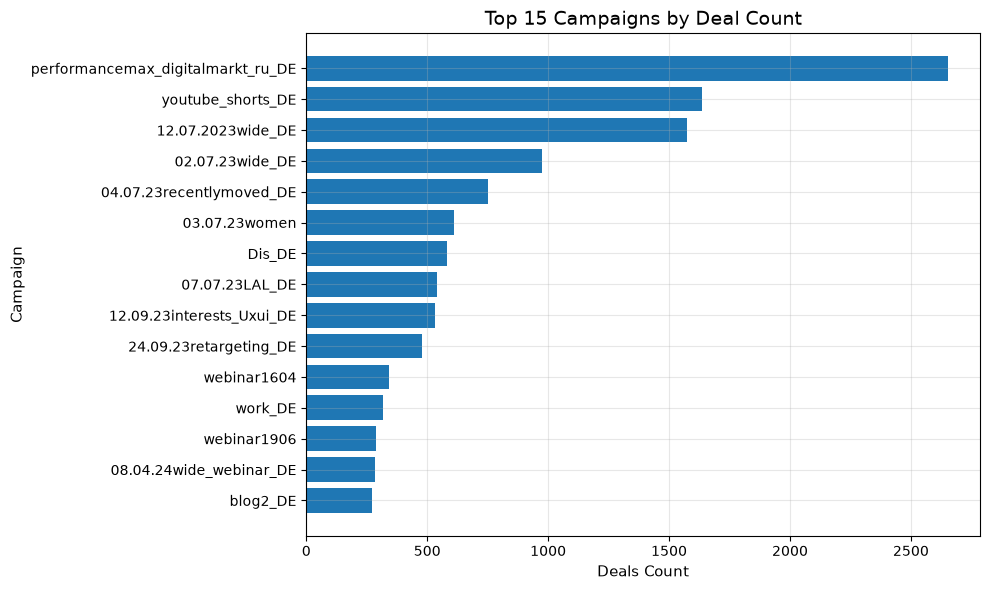

In [105]:
top_campaigns_by_leads_plot = top_campaigns_by_leads.sort_values(
    'Deals Count',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_campaigns_by_leads_plot['Campaign'],
    top_campaigns_by_leads_plot['Deals Count']
)

plt.xlabel('Deals Count')
plt.ylabel('Campaign')
plt.title('Top 15 Campaigns by Deal Count')
plt.tight_layout()
plt.show()

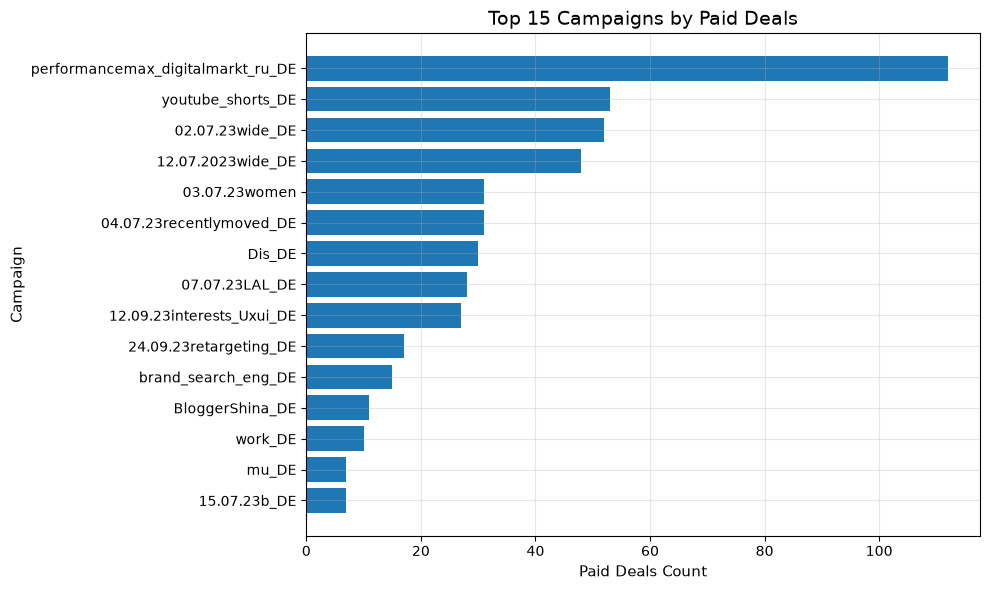

In [106]:
top_campaigns_by_paid_deals = (
    campaign_summary
    .sort_values('Paid Deals', ascending=False)
    .head(15)
)

top_campaigns_by_paid_deals_plot = top_campaigns_by_paid_deals.sort_values(
    'Paid Deals',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_campaigns_by_paid_deals_plot['Campaign'],
    top_campaigns_by_paid_deals_plot['Paid Deals']
)

plt.xlabel('Paid Deals Count')
plt.ylabel('Campaign')
plt.title('Top 15 Campaigns by Paid Deals')
plt.tight_layout()
plt.show()

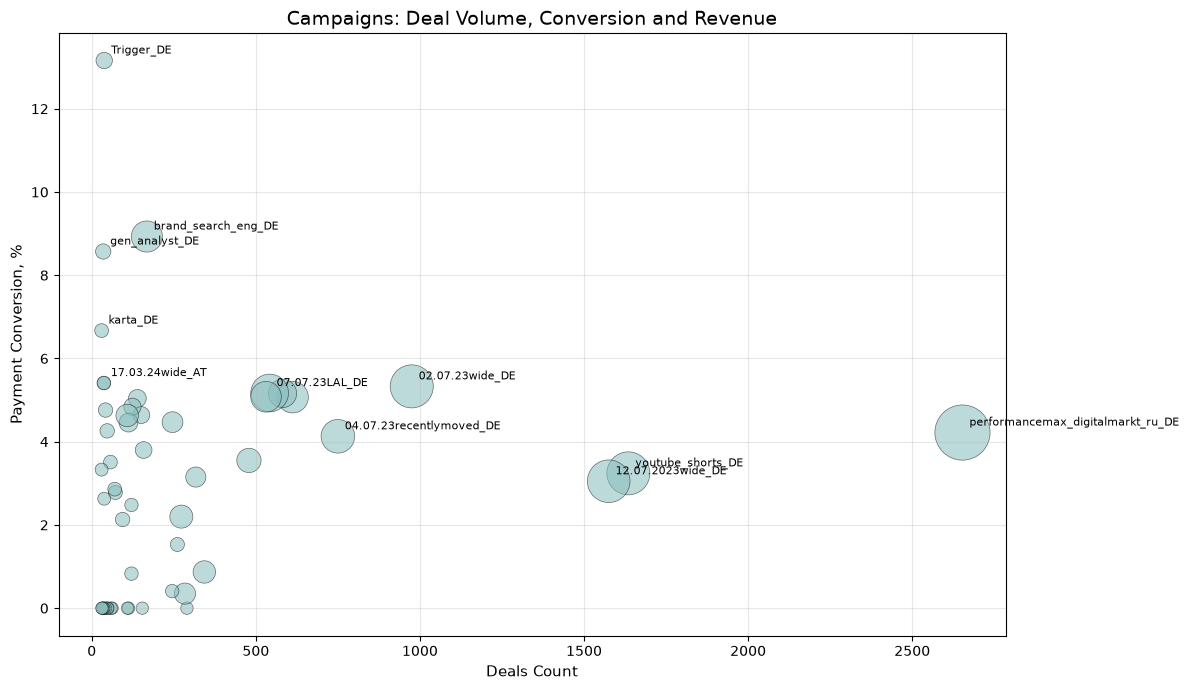

In [107]:
campaign_quadrant_plot = campaign_summary[
    campaign_summary['Deals Count'] >= 30
].copy()

max_campaign_revenue = campaign_quadrant_plot['Revenue'].max()

if max_campaign_revenue > 0:
    campaign_quadrant_plot['Bubble Size'] = (
        campaign_quadrant_plot['Revenue'] / max_campaign_revenue * 1500 + 80
    )
else:
    campaign_quadrant_plot['Bubble Size'] = 200

plt.figure(figsize=(12, 7))

plt.scatter(
    campaign_quadrant_plot['Deals Count'],
    campaign_quadrant_plot['Payment Conversion, %'],
    s=campaign_quadrant_plot['Bubble Size'],
    alpha=0.55,
    color=scatter_color,
    edgecolors='black',
    linewidth=0.5
)

# Label only key campaigns to avoid overcrowding the chart
top_campaign_labels = pd.concat([
    campaign_quadrant_plot.nlargest(5, 'Deals Count'),
    campaign_quadrant_plot.nlargest(5, 'Payment Conversion, %'),
    campaign_quadrant_plot.nlargest(5, 'Revenue')
]).drop_duplicates(subset=['Campaign'])

for _, row in top_campaign_labels.iterrows():
    plt.annotate(
        row['Campaign'],
        xy=(row['Deals Count'], row['Payment Conversion, %']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Deals Count')
plt.ylabel('Payment Conversion, %')
plt.title('Campaigns: Deal Volume, Conversion and Revenue')

plt.tight_layout()
plt.show()

### Top Campaigns by Payment Conversion

For campaign conversion analysis, I use a minimum deal-count threshold to avoid drawing conclusions from very small samples.

In [108]:
min_campaign_deals = 30

top_campaigns_by_conversion = (
    campaign_summary[
        campaign_summary['Deals Count'] >= min_campaign_deals
    ]
    .sort_values('Payment Conversion, %', ascending=False)
)

top_campaigns_by_conversion.head(15)

,Campaign,Deals Count,Paid Deals,Revenue,Quality Leads,"Payment Conversion, %","Quality Lead Share, %"
70,Trigger_DE,38,5,"4,300.00",14,13.16,36.84
83,brand_search_eng_DE,168,15,"30,250.00",64,8.93,38.10
95,gen_analyst_DE,35,3,"3,000.00",22,8.57,62.86
105,karta_DE,30,2,"1,350.00",11,6.67,36.67
25,17.03.24wide_AT,37,2,800.00,12,5.41,32.43
56,Bloggernina_DE,37,2,"1,200.00",11,5.41,29.73
2,02.07.23wide_DE,975,52,"63,250.00",336,5.33,34.46
8,07.07.23LAL_DE,542,28,"47,150.00",161,5.17,29.70
60,Dis_DE,581,30,"24,200.00",209,5.16,35.97
19,12.09.23interests_Uxui_DE,531,27,"29,100.00",203,5.08,38.23


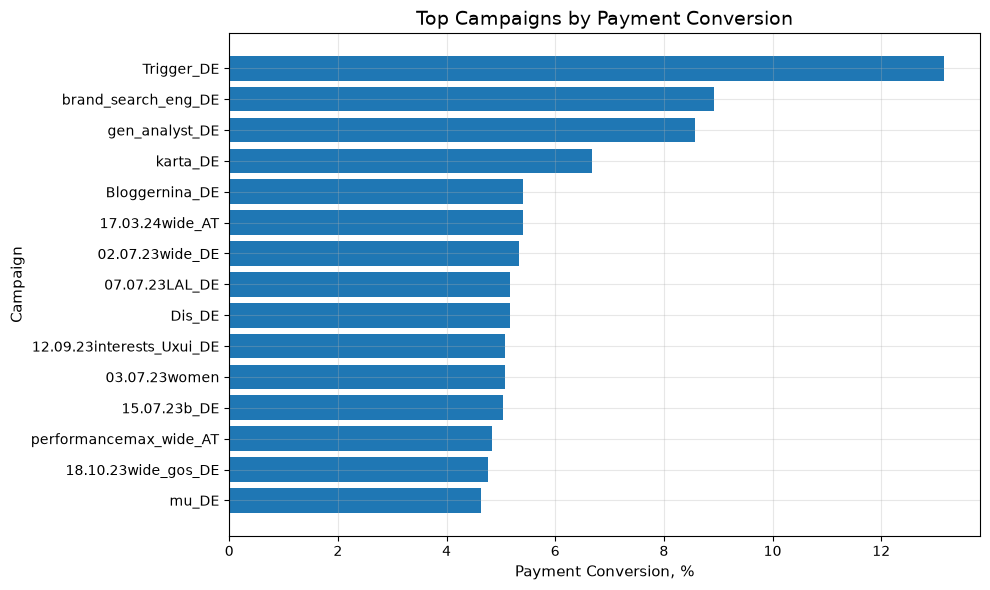

In [109]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_campaigns_by_conversion.head(15).sort_values('Payment Conversion, %')['Campaign'],
    top_campaigns_by_conversion.head(15).sort_values('Payment Conversion, %')['Payment Conversion, %']
)

plt.xlabel('Payment Conversion, %')
plt.ylabel('Campaign')
plt.title('Top Campaigns by Payment Conversion')
plt.tight_layout()
plt.show()

### Source Performance by Leads, Payments and Quality

I analyze `Source` by:

- deal count;
- paid deals;
- payment conversion;
- revenue;
- number of quality leads;
- quality lead share.

This section evaluates which marketing sources generate higher-quality leads.

In [110]:
source_summary = (
    deals
    .groupby('Source', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum'),
        quality_leads=('Is Quality Lead', 'sum')
    )
    .reset_index()
)

source_summary['Payment Conversion, %'] = (
    source_summary['paid_deals'] / source_summary['deals_count'] * 100
).round(2)

source_summary['Quality Lead Share, %'] = (
    source_summary['quality_leads'] / source_summary['deals_count'] * 100
).round(2)

source_summary = source_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'quality_leads': 'Quality Leads'
})

source_summary = source_summary.sort_values(
    ['Deals Count', 'Paid Deals'],
    ascending=False
)

source_summary

,Source,Deals Count,Paid Deals,Revenue,Quality Leads,"Payment Conversion, %","Quality Lead Share, %"
2,Facebook Ads,4850,202,"236,150.00",1480,4.16,30.52
3,Google Ads,4226,173,"174,850.00",1097,4.09,25.96
5,Organic,2590,147,"183,451.00",594,5.68,22.93
10,Tiktok Ads,2051,56,"66,650.00",475,2.73,23.16
7,SMM,1730,91,"99,750.00",509,5.26,29.42
12,Youtube Ads,1657,53,"62,950.00",430,3.20,25.95
1,CRM,1656,24,"15,600.00",136,1.45,8.21
0,Bloggers,1089,39,"33,100.00",305,3.58,28.01
8,Telegram posts,1001,40,"45,450.00",294,4.00,29.37
11,Webinar,379,26,"55,150.00",98,6.86,25.86


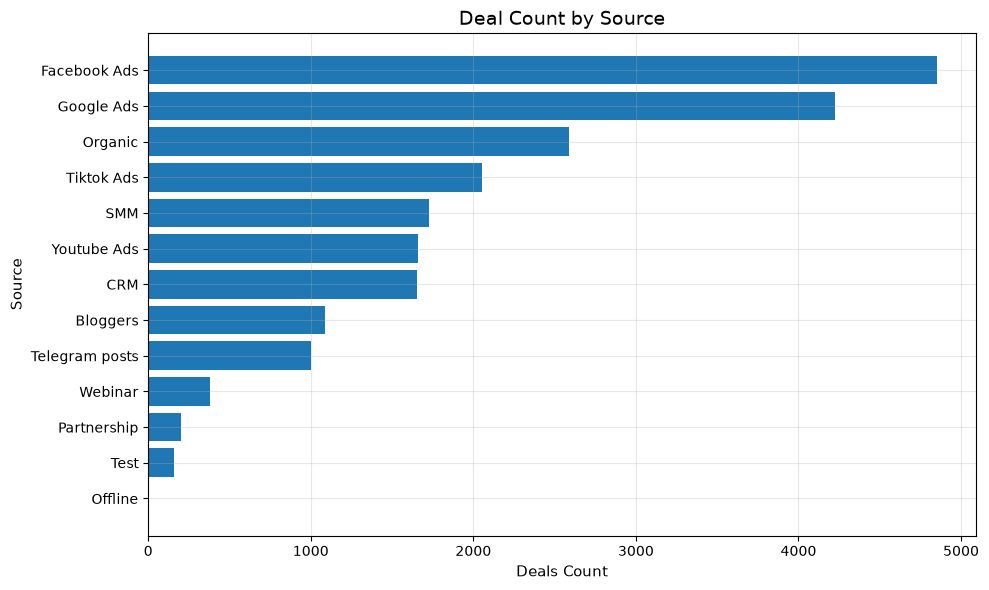

In [111]:
source_plot_data = source_summary.sort_values('Deals Count', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(source_plot_data['Source'], source_plot_data['Deals Count'])

plt.xlabel('Deals Count')
plt.ylabel('Source')
plt.title('Deal Count by Source')
plt.tight_layout()
plt.show()

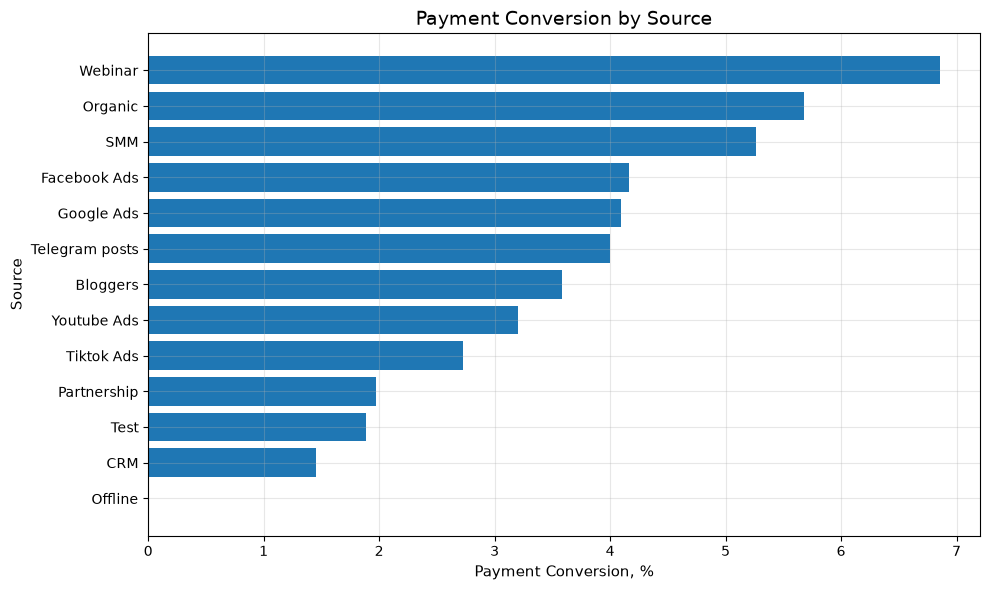

In [112]:
source_conversion_plot = source_summary.sort_values('Payment Conversion, %', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(source_conversion_plot['Source'], source_conversion_plot['Payment Conversion, %'])

plt.xlabel('Payment Conversion, %')
plt.ylabel('Source')
plt.title('Payment Conversion by Source')
plt.tight_layout()
plt.show()

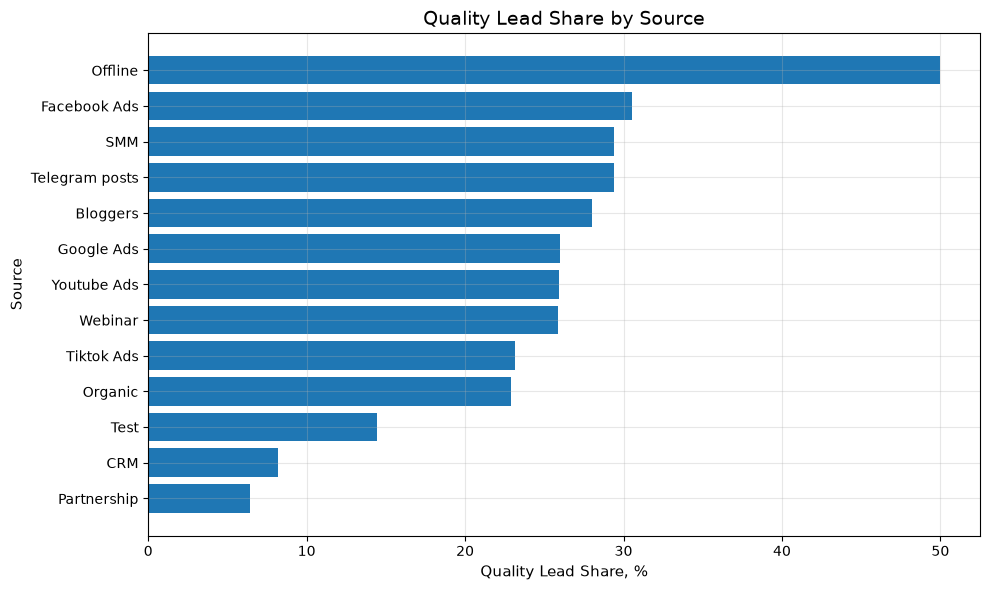

In [113]:
source_quality_plot = source_summary.sort_values('Quality Lead Share, %', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(source_quality_plot['Source'], source_quality_plot['Quality Lead Share, %'])

plt.xlabel('Quality Lead Share, %')
plt.ylabel('Source')
plt.title('Quality Lead Share by Source')
plt.tight_layout()
plt.show()

### Linking Sources with Marketing Spend

I additionally match `Deals` sources with marketing spend from `Spend`.

This allows analysis of not only leads and payments, but also spend, clicks, impressions and basic marketing metrics at the `Source` level.

*Deep unit economics is covered in a separate notebook; here spend metrics are used as additional context.*

In [114]:
spend_source_summary = (
    spend
    .groupby('Source', dropna=False)
    .agg(
        spend=('Spend', 'sum'),
        impressions=('Impressions', 'sum'),
        clicks=('Clicks', 'sum')
    )
    .reset_index()
)

spend_source_summary['CPC'] = safe_divide(
    spend_source_summary['spend'],
    spend_source_summary['clicks']
)

spend_source_summary = spend_source_summary.rename(columns={
    'spend': 'Spend',
    'impressions': 'Impressions',
    'clicks': 'Clicks'
})

spend_source_summary

,Source,Spend,Impressions,Clicks,CPC
0,Bloggers,"13,439.00",738460,14250,0.94
1,CRM,0.00,0,7995,0.00
2,Facebook Ads,"33,754.72",2850200,48133,0.70
3,Google Ads,"57,798.60",32752334,248487,0.23
4,Offline,0.00,0,57,0.00
5,Organic,0.00,0,59128,0.00
6,Partnership,0.00,0,350,0.00
7,Radio,300.00,0,0,NaN
8,SMM,"7,269.52",23772,11528,0.63
9,Telegram posts,"6,860.36",705415,16777,0.41


In [115]:
valid_spend_ctr_source = (
    valid_spend_ctr
    .groupby('Source', dropna=False)
    .agg(
        valid_impressions=('Impressions', 'sum'),
        valid_clicks=('Clicks', 'sum')
    )
    .reset_index()
)

valid_spend_ctr_source['CTR, %'] = (
    safe_divide(
        valid_spend_ctr_source['valid_clicks'],
        valid_spend_ctr_source['valid_impressions']
    ) * 100
).round(2)

valid_spend_ctr_source = valid_spend_ctr_source[
    ['Source', 'CTR, %']
]

valid_spend_ctr_source

,Source,"CTR, %"
0,Bloggers,1.93
1,CRM,NaN
2,Facebook Ads,1.69
3,Google Ads,0.76
4,Offline,NaN
5,Organic,NaN
6,Partnership,NaN
7,Radio,NaN
8,SMM,0.13
9,Telegram posts,2.38


In [116]:
source_marketing_summary = source_summary.merge(
    spend_source_summary,
    on='Source',
    how='left'
)

source_marketing_summary = source_marketing_summary.merge(
    valid_spend_ctr_source,
    on='Source',
    how='left'
)

source_marketing_summary['CPL'] = safe_divide(
    source_marketing_summary['Spend'],
    source_marketing_summary['Deals Count']
)

source_marketing_summary['Cost per Paid Deal'] = safe_divide(
    source_marketing_summary['Spend'],
    source_marketing_summary['Paid Deals']
)

source_marketing_summary['Revenue / Spend'] = safe_divide(
    source_marketing_summary['Revenue'],
    source_marketing_summary['Spend']
)

source_marketing_summary = source_marketing_summary.sort_values(
    ['Deals Count', 'Paid Deals'],
    ascending=False
)

source_marketing_summary

,Source,Deals Count,Paid Deals,Revenue,Quality Leads,"Payment Conversion, %","Quality Lead Share, %",Spend,Impressions,Clicks,CPC,"CTR, %",CPL,Cost per Paid Deal,Revenue / Spend
0,Facebook Ads,4850,202,"236,150.00",1480,4.16,30.52,"33,754.72",2850200,48133,0.70,1.69,6.96,167.10,7.00
1,Google Ads,4226,173,"174,850.00",1097,4.09,25.96,"57,798.60",32752334,248487,0.23,0.76,13.68,334.10,3.03
2,Organic,2590,147,"183,451.00",594,5.68,22.93,0.00,0,59128,0.00,NaN,0.00,0.00,NaN
3,Tiktok Ads,2051,56,"66,650.00",475,2.73,23.16,"11,985.67",5007212,28268,0.42,0.56,5.84,214.03,5.56
4,SMM,1730,91,"99,750.00",509,5.26,29.42,"7,269.52",23772,11528,0.63,0.13,4.20,79.88,13.72
5,Youtube Ads,1657,53,"62,950.00",430,3.20,25.95,"14,633.33",8655978,59061,0.25,0.68,8.83,276.10,4.30
6,CRM,1656,24,"15,600.00",136,1.45,8.21,0.00,0,7995,0.00,NaN,0.00,0.00,NaN
7,Bloggers,1089,39,"33,100.00",305,3.58,28.01,"13,439.00",738460,14250,0.94,1.93,12.34,344.59,2.46
8,Telegram posts,1001,40,"45,450.00",294,4.00,29.37,"6,860.36",705415,16777,0.41,2.38,6.85,171.51,6.63
9,Webinar,379,26,"55,150.00",98,6.86,25.86,"2,874.04",301670,3241,0.89,1.07,7.58,110.54,19.19


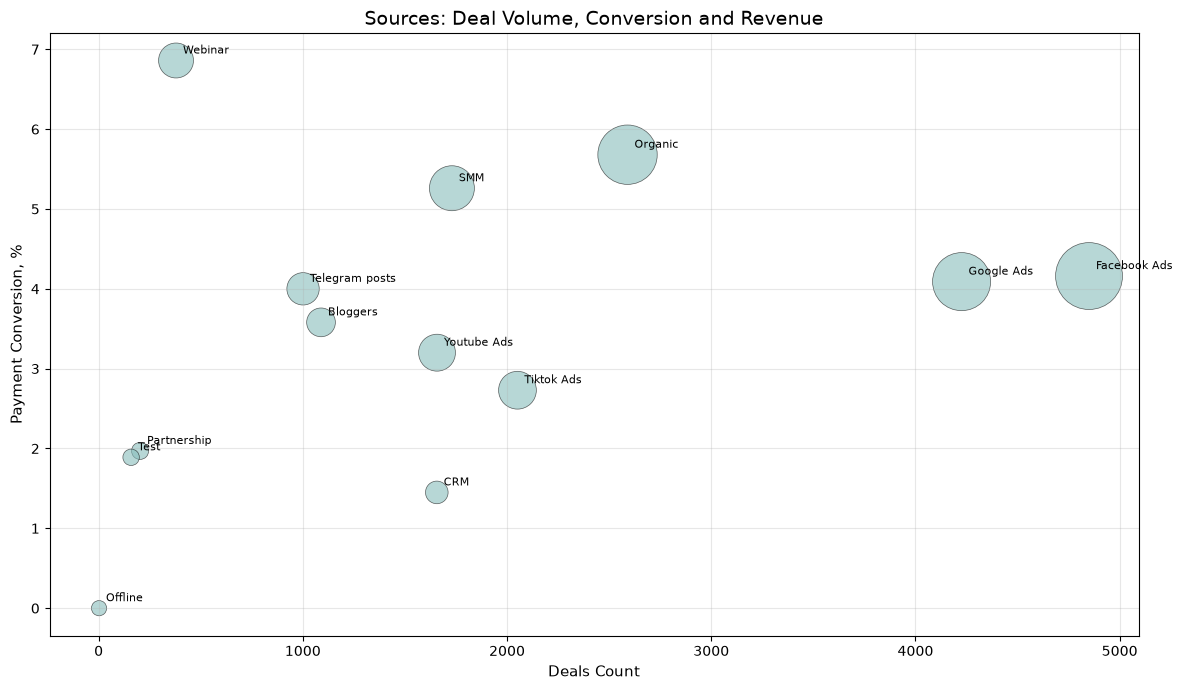

In [117]:
source_bubble_plot = source_marketing_summary[
    source_marketing_summary['Deals Count'] > 0
].copy()

source_bubble_plot['Bubble Size'] = (
    source_bubble_plot['Revenue'] / source_bubble_plot['Revenue'].max() * 2200 + 120
)

plt.figure(figsize=(12, 7))

plt.scatter(
    source_bubble_plot['Deals Count'],
    source_bubble_plot['Payment Conversion, %'],
    s=source_bubble_plot['Bubble Size'],
    alpha=0.6,
    color=scatter_color,
    edgecolors='black',
    linewidth=0.5
)

for _, row in source_bubble_plot.iterrows():
    plt.annotate(
        row['Source'],
        xy=(row['Deals Count'], row['Payment Conversion, %']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Deals Count')
plt.ylabel('Payment Conversion, %')
plt.title('Sources: Deal Volume, Conversion and Revenue')

plt.tight_layout()
plt.show()

The dashed line shows `Revenue = Spend`.

Sources above the line generate revenue above advertising spend.

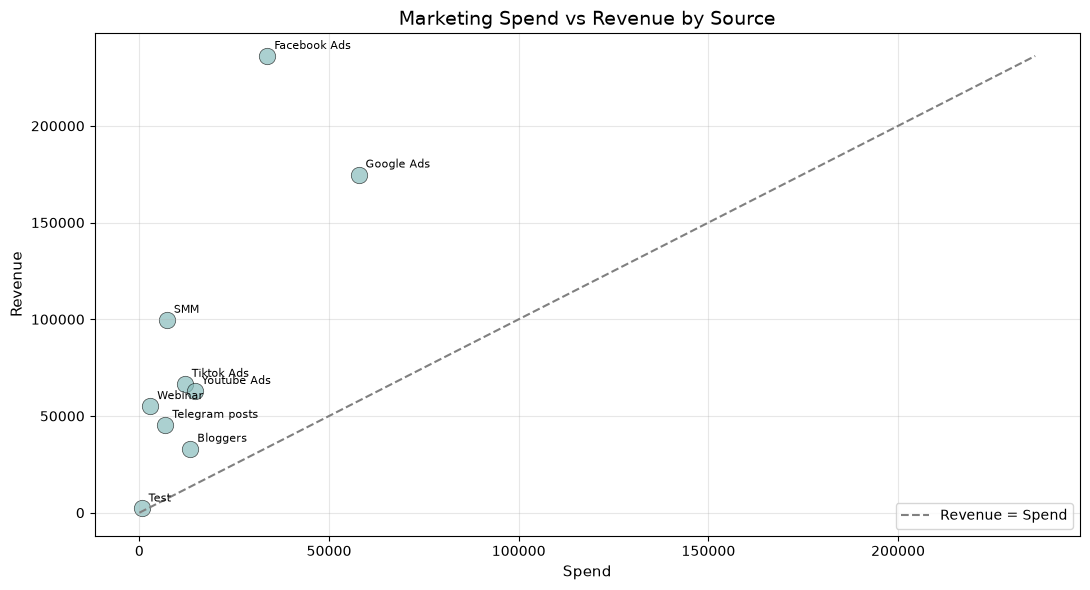

In [118]:
source_spend_revenue_plot = source_marketing_summary[
    source_marketing_summary['Spend'] > 0
].copy()

plt.figure(figsize=(11, 6))

plt.scatter(
    source_spend_revenue_plot['Spend'],
    source_spend_revenue_plot['Revenue'],
    s=140,
    alpha=0.7,
    color=scatter_color,
    edgecolors='black',
    linewidth=0.5
)

for _, row in source_spend_revenue_plot.iterrows():
    plt.annotate(
        row['Source'],
        xy=(row['Spend'], row['Revenue']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

max_value = max(
    source_spend_revenue_plot['Spend'].max(),
    source_spend_revenue_plot['Revenue'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    linewidth=1.5,
    color=reference_color,
    label='Revenue = Spend'
)

plt.xlabel('Spend')
plt.ylabel('Revenue')
plt.title('Marketing Spend vs Revenue by Source')
plt.legend()
plt.tight_layout()
plt.show()

### Campaign-Level Spend Matching

Because campaign matching between `Deals` and `Spend` is partial, campaign-level cost metrics are used only as an additional view and not as the main level of marketing performance evaluation.

In [119]:
spend_campaign_summary = (
    spend[spend['Campaign'].notna()]
    .groupby('Campaign', dropna=False)
    .agg(
        spend=('Spend', 'sum'),
        impressions=('Impressions', 'sum'),
        clicks=('Clicks', 'sum')
    )
    .reset_index()
)

spend_campaign_summary = spend_campaign_summary.rename(columns={
    'spend': 'Spend',
    'impressions': 'Impressions',
    'clicks': 'Clicks'
})

In [120]:
campaign_marketing_summary = campaign_summary.merge(
    spend_campaign_summary,
    on='Campaign',
    how='left'
)

campaign_marketing_summary['CPL'] = np.where(
    campaign_marketing_summary['Spend'] > 0,
    campaign_marketing_summary['Spend'] / campaign_marketing_summary['Deals Count'],
    np.nan
)

campaign_marketing_summary['Cost per Paid Deal'] = np.where(
    (campaign_marketing_summary['Spend'] > 0) & (campaign_marketing_summary['Paid Deals'] > 0),
    campaign_marketing_summary['Spend'] / campaign_marketing_summary['Paid Deals'],
    np.nan
)

campaign_marketing_summary['Revenue / Spend'] = np.where(
    campaign_marketing_summary['Spend'] > 0,
    campaign_marketing_summary['Revenue'] / campaign_marketing_summary['Spend'],
    np.nan
)

campaign_marketing_summary = campaign_marketing_summary.sort_values(
    ['Deals Count', 'Paid Deals'],
    ascending=False
)

campaign_marketing_summary.head(30)

,Campaign,Deals Count,Paid Deals,Revenue,Quality Leads,"Payment Conversion, %","Quality Lead Share, %",Spend,Impressions,Clicks,CPL,Cost per Paid Deal,Revenue / Spend
0,performancemax_digitalmarkt_ru_DE,2653,112,"107,500.00",645,4.22,24.31,NaN,NaN,NaN,NaN,NaN,NaN
1,youtube_shorts_DE,1635,53,"62,950.00",424,3.24,25.93,"14,149.22","8,481,054.00","57,873.00",8.65,266.97,4.45
2,12.07.2023wide_DE,1575,48,"61,850.00",414,3.05,26.29,"9,471.52","3,302,301.00","22,768.00",6.01,197.32,6.53
3,02.07.23wide_DE,975,52,"63,250.00",336,5.33,34.46,"6,913.60","594,807.00","10,281.00",7.09,132.95,9.15
4,04.07.23recentlymoved_DE,750,31,"36,300.00",219,4.13,29.20,"4,523.31","417,891.00","7,611.00",6.03,145.91,8.03
5,03.07.23women,612,31,"31,100.00",196,5.07,32.03,"4,219.75","348,089.00","7,139.00",6.90,136.12,7.37
6,Dis_DE,581,30,"24,200.00",209,5.16,35.97,NaN,NaN,NaN,NaN,NaN,NaN
7,07.07.23LAL_DE,542,28,"47,150.00",161,5.17,29.70,"4,200.37","335,725.00","5,813.00",7.75,150.01,11.23
8,12.09.23interests_Uxui_DE,531,27,"29,100.00",203,5.08,38.23,"3,753.06","319,463.00","6,301.00",7.07,139.00,7.75
9,24.09.23retargeting_DE,479,17,"16,200.00",157,3.55,32.78,"2,817.29","252,080.00","4,143.00",5.88,165.72,5.75


### Sources with the Best Conversion

For source conversion comparison, I use a minimum deal-count threshold to avoid conclusions based on very small samples.

In [121]:
min_source_deals = 100

top_sources_by_conversion = (
    source_marketing_summary[
        source_marketing_summary['Deals Count'] >= min_source_deals
    ]
    .sort_values('Payment Conversion, %', ascending=False)
)

top_sources_by_conversion[
    [
        'Source',
        'Deals Count',
        'Paid Deals',
        'Payment Conversion, %',
        'Quality Leads',
        'Quality Lead Share, %',
        'Revenue',
        'Spend',
        'CPL',
        'Cost per Paid Deal',
        'Revenue / Spend'
    ]
]

,Source,Deals Count,Paid Deals,"Payment Conversion, %",Quality Leads,"Quality Lead Share, %",Revenue,Spend,CPL,Cost per Paid Deal,Revenue / Spend
9,Webinar,379,26,6.86,98,25.86,"55,150.00","2,874.04",7.58,110.54,19.19
2,Organic,2590,147,5.68,594,22.93,"183,451.00",0.00,0.00,0.00,NaN
4,SMM,1730,91,5.26,509,29.42,"99,750.00","7,269.52",4.20,79.88,13.72
0,Facebook Ads,4850,202,4.16,1480,30.52,"236,150.00","33,754.72",6.96,167.10,7.00
1,Google Ads,4226,173,4.09,1097,25.96,"174,850.00","57,798.60",13.68,334.10,3.03
8,Telegram posts,1001,40,4.00,294,29.37,"45,450.00","6,860.36",6.85,171.51,6.63
7,Bloggers,1089,39,3.58,305,28.01,"33,100.00","13,439.00",12.34,344.59,2.46
5,Youtube Ads,1657,53,3.20,430,25.95,"62,950.00","14,633.33",8.83,276.10,4.30
3,Tiktok Ads,2051,56,2.73,475,23.16,"66,650.00","11,985.67",5.84,214.03,5.56
10,Partnership,203,4,1.97,13,6.40,"3,350.00",0.00,0.00,0.00,NaN


In [122]:
top_sources_by_quality = (
    source_marketing_summary[
        source_marketing_summary['Deals Count'] >= min_source_deals
    ]
    .sort_values('Quality Lead Share, %', ascending=False)
)

top_sources_by_quality[
    [
        'Source',
        'Deals Count',
        'Paid Deals',
        'Payment Conversion, %',
        'Quality Leads',
        'Quality Lead Share, %',
        'Revenue',
        'Spend',
        'CPL',
        'Cost per Paid Deal',
        'Revenue / Spend'
    ]
]

,Source,Deals Count,Paid Deals,"Payment Conversion, %",Quality Leads,"Quality Lead Share, %",Revenue,Spend,CPL,Cost per Paid Deal,Revenue / Spend
0,Facebook Ads,4850,202,4.16,1480,30.52,"236,150.00","33,754.72",6.96,167.10,7.00
4,SMM,1730,91,5.26,509,29.42,"99,750.00","7,269.52",4.20,79.88,13.72
8,Telegram posts,1001,40,4.00,294,29.37,"45,450.00","6,860.36",6.85,171.51,6.63
7,Bloggers,1089,39,3.58,305,28.01,"33,100.00","13,439.00",12.34,344.59,2.46
1,Google Ads,4226,173,4.09,1097,25.96,"174,850.00","57,798.60",13.68,334.10,3.03
5,Youtube Ads,1657,53,3.20,430,25.95,"62,950.00","14,633.33",8.83,276.10,4.30
9,Webinar,379,26,6.86,98,25.86,"55,150.00","2,874.04",7.58,110.54,19.19
3,Tiktok Ads,2051,56,2.73,475,23.16,"66,650.00","11,985.67",5.84,214.03,5.56
2,Organic,2590,147,5.68,594,22.93,"183,451.00",0.00,0.00,0.00,NaN
11,Test,159,3,1.89,23,14.47,"2,200.00",608.21,3.83,202.74,3.62


### Marketing Analysis Summary

Marketing performance differs significantly by source and campaign. High lead volume does not always mean high conversion, high lead quality or better financial return.

At the campaign level, `performancemax_digitalmarkt_ru_DE` generates the largest volume: 2,653 deals, 112 paid deals and 107,500 revenue. However, its conversion is 4.22% and quality lead share is 24.31%, so the campaign is strong in volume but not the strongest in quality or conversion.

Among campaigns with a minimum threshold of 30 deals, `Trigger_DE` has the highest conversion at 13.16%, but the volume is small. A more stable example is `brand_search_eng_DE`: 168 deals, 15 paid deals, 8.93% conversion and 38.10% quality lead share.

At the source level, the largest lead generators are `Facebook Ads`, `Google Ads`, `Organic`, `Tiktok Ads` and `SMM`. `Facebook Ads` leads by paid deals and revenue: 202 paid deals and 236,150 revenue. `Google Ads`, `Organic` and `SMM` also contribute meaningful paid volume.

The highest payment conversion among sources with sufficient volume is observed for `Webinar`, `Organic` and `SMM`. `Facebook Ads` and `Google Ads` provide large scale but more moderate conversion. `Tiktok Ads` shows weaker conversion.

Cost analysis shows that not all sources are equally efficient. `SMM` has low CPL, low cost per paid deal and high `Revenue / Spend`. `Webinar` also looks financially efficient, but its deal volume is lower. `Facebook Ads` combines scale with acceptable cost metrics. `Google Ads` is important by volume, but its cost efficiency is weaker and should be analyzed further by campaign and traffic quality.

Campaign-level spend matching is partial. Some large campaigns from `Deals` do not have matching spend in `Spend`, so campaign-level cost metrics should be treated as an additional view rather than the main basis for decisions.

Overall, marketing channels should be managed by role: `Facebook Ads` and `Google Ads` provide scale, `SMM` and `Webinar` look more cost-effective, `Organic` brings strong non-paid results, and selected campaigns such as `brand_search_eng_DE`, `Trigger_DE` and `gen_analyst_DE` deserve additional review as potentially high-quality or high-converting campaigns.

### Key Observations

- `Facebook Ads` is the largest source by deals and paid deals.
- `Google Ads` is the largest paid source by spend, but its cost efficiency is lower than several other channels.
- `SMM` and `Webinar` look strong by the relationship between spend, payments and revenue.
- `Organic` shows high conversion and revenue without advertising spend in the `Spend` table.
- High lead volume does not guarantee high conversion or lead quality.
- Campaign-level spend is not matched for all campaigns, so campaign-level cost metrics are used only as additional analysis.
- `Source` remains the main level for marketing performance analysis, while `Campaign` helps identify strong or problematic points within channels.

## Sales Team Performance Analysis

This section analyzes sales team performance.

The analysis covers:

- deals by manager;
- paid deals;
- payment conversion;
- revenue;
- average check;
- SLA;
- deal duration;
- call activity;
- manager relationships with campaigns and sources.

The main field for deal-level manager analysis is `Deal Owner Name`. For calls, the field is `Call Owner Name`.

### Manager Performance by Deals

I compare managers by processed deals, paid deals, payment conversion and revenue.

In [123]:
manager_summary = (
    deals
    .groupby('Deal Owner Name', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

manager_summary['Payment Conversion, %'] = (
    manager_summary['paid_deals'] / manager_summary['deals_count'] * 100
).round(2)

manager_summary = manager_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

manager_summary = manager_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

manager_summary

,Deal Owner Name,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %"
5,Charlie Davis,2963,148,"141,750.00",957.77,"1,000.00",4.99
21,Ulysses Adams,2165,141,"127,100.00",901.42,"1,000.00",6.51
17,Paula Underwood,1862,93,"101,650.00","1,093.01","1,000.00",4.99
12,Julia Nelson,2241,93,"85,051.00",914.53,"1,000.00",4.15
18,Quincy Vincent,1884,65,"72,400.00","1,113.85","1,000.00",3.45
16,Oliver Taylor,163,50,"50,250.00","1,005.00","1,000.00",30.67
2,Ben Hall,1345,46,"58,700.00","1,276.09","1,000.00",3.42
15,Nina Scott,1283,46,"40,700.00",904.44,"1,000.00",3.59
23,Victor Barnes,1232,44,"66,700.00","1,515.91","1,000.00",3.57
13,Kevin Parker,574,40,"23,950.00",921.15,"1,000.00",6.97


In [124]:
top_managers_by_deals = manager_summary.sort_values(
    'Deals Count',
    ascending=False
).head(15)

top_managers_by_deals

,Deal Owner Name,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %"
5,Charlie Davis,2963,148,"141,750.00",957.77,"1,000.00",4.99
12,Julia Nelson,2241,93,"85,051.00",914.53,"1,000.00",4.15
21,Ulysses Adams,2165,141,"127,100.00",901.42,"1,000.00",6.51
18,Quincy Vincent,1884,65,"72,400.00","1,113.85","1,000.00",3.45
17,Paula Underwood,1862,93,"101,650.00","1,093.01","1,000.00",4.99
2,Ben Hall,1345,46,"58,700.00","1,276.09","1,000.00",3.42
15,Nina Scott,1283,46,"40,700.00",904.44,"1,000.00",3.59
23,Victor Barnes,1232,44,"66,700.00","1,515.91","1,000.00",3.57
4,Cara Iverson,1056,27,"151,900.00","5,625.93","5,000.00",2.56
6,Diana Evans,1013,1,350.00,350.00,350.00,0.10


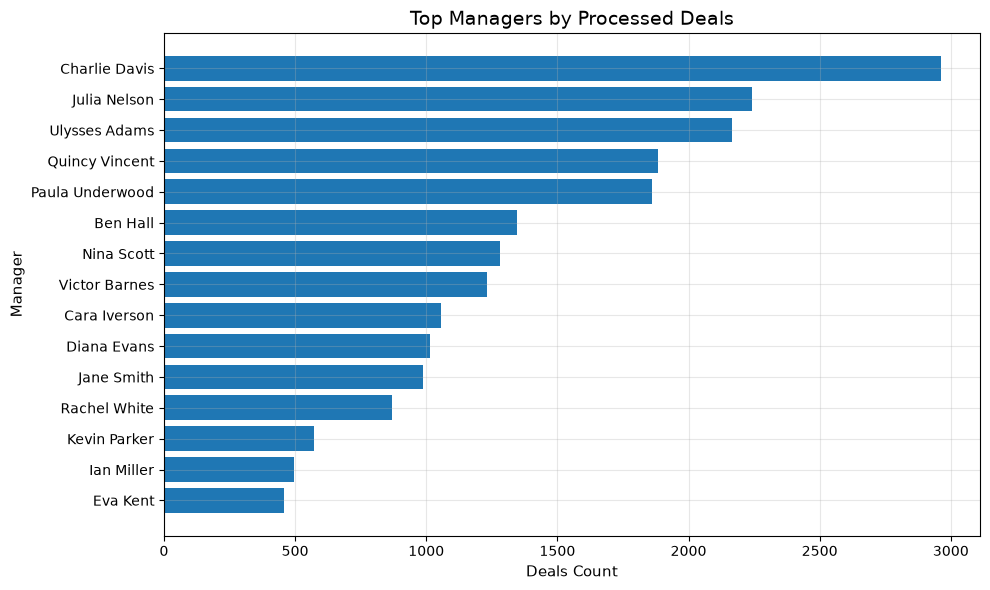

In [125]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_managers_by_deals.sort_values('Deals Count')['Deal Owner Name'],
    top_managers_by_deals.sort_values('Deals Count')['Deals Count']
)

plt.xlabel('Deals Count')
plt.ylabel('Manager')
plt.title('Top Managers by Processed Deals')
plt.tight_layout()
plt.show()

### Top Managers by Payment Conversion

For conversion analysis, I use a minimum deal-count threshold to avoid conclusions based on very small samples.

In [126]:
min_manager_deals = 100

top_managers_by_conversion = (
    manager_summary[
        manager_summary['Deals Count'] >= min_manager_deals
    ]
    .sort_values('Payment Conversion, %', ascending=False)
)

top_managers_by_conversion.head(15)

,Deal Owner Name,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %"
16,Oliver Taylor,163,50,"50,250.00","1,005.00","1,000.00",30.67
13,Kevin Parker,574,40,"23,950.00",921.15,"1,000.00",6.97
21,Ulysses Adams,2165,141,"127,100.00",901.42,"1,000.00",6.51
5,Charlie Davis,2963,148,"141,750.00",957.77,"1,000.00",4.99
17,Paula Underwood,1862,93,"101,650.00","1,093.01","1,000.00",4.99
12,Julia Nelson,2241,93,"85,051.00",914.53,"1,000.00",4.15
7,Eva Kent,459,18,"20,100.00","1,116.67","1,000.00",3.92
15,Nina Scott,1283,46,"40,700.00",904.44,"1,000.00",3.59
23,Victor Barnes,1232,44,"66,700.00","1,515.91","1,000.00",3.57
18,Quincy Vincent,1884,65,"72,400.00","1,113.85","1,000.00",3.45


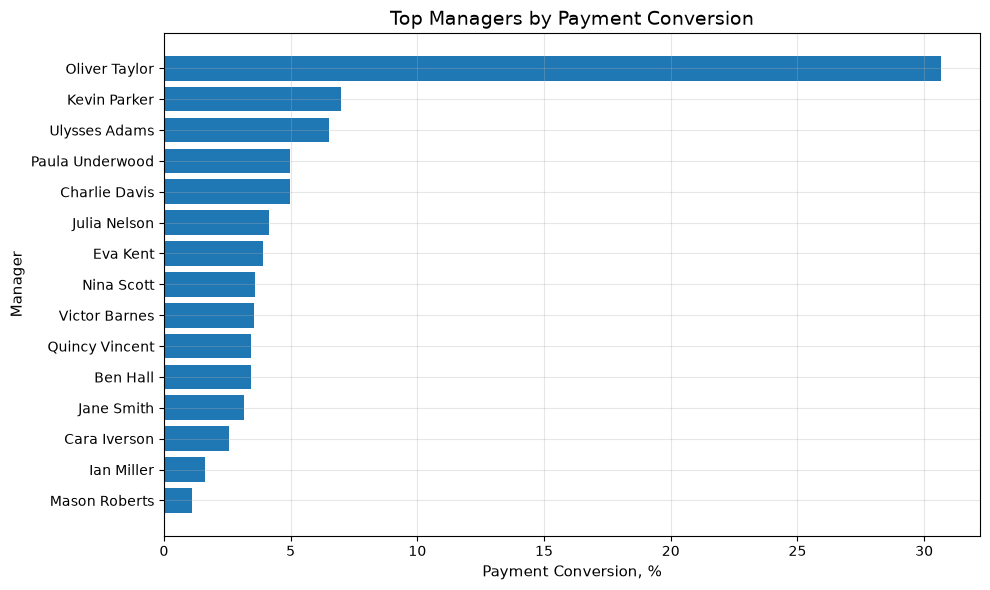

In [127]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_managers_by_conversion.head(15).sort_values('Payment Conversion, %')['Deal Owner Name'],
    top_managers_by_conversion.head(15).sort_values('Payment Conversion, %')['Payment Conversion, %']
)

plt.xlabel('Payment Conversion, %')
plt.ylabel('Manager')
plt.title('Top Managers by Payment Conversion')
plt.tight_layout()
plt.show()

In [128]:
top_managers_by_revenue = manager_summary.sort_values(
    'Revenue',
    ascending=False
).head(15)

top_managers_by_revenue

,Deal Owner Name,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %"
4,Cara Iverson,1056,27,"151,900.00","5,625.93","5,000.00",2.56
5,Charlie Davis,2963,148,"141,750.00",957.77,"1,000.00",4.99
21,Ulysses Adams,2165,141,"127,100.00",901.42,"1,000.00",6.51
17,Paula Underwood,1862,93,"101,650.00","1,093.01","1,000.00",4.99
12,Julia Nelson,2241,93,"85,051.00",914.53,"1,000.00",4.15
18,Quincy Vincent,1884,65,"72,400.00","1,113.85","1,000.00",3.45
23,Victor Barnes,1232,44,"66,700.00","1,515.91","1,000.00",3.57
2,Ben Hall,1345,46,"58,700.00","1,276.09","1,000.00",3.42
16,Oliver Taylor,163,50,"50,250.00","1,005.00","1,000.00",30.67
15,Nina Scott,1283,46,"40,700.00",904.44,"1,000.00",3.59


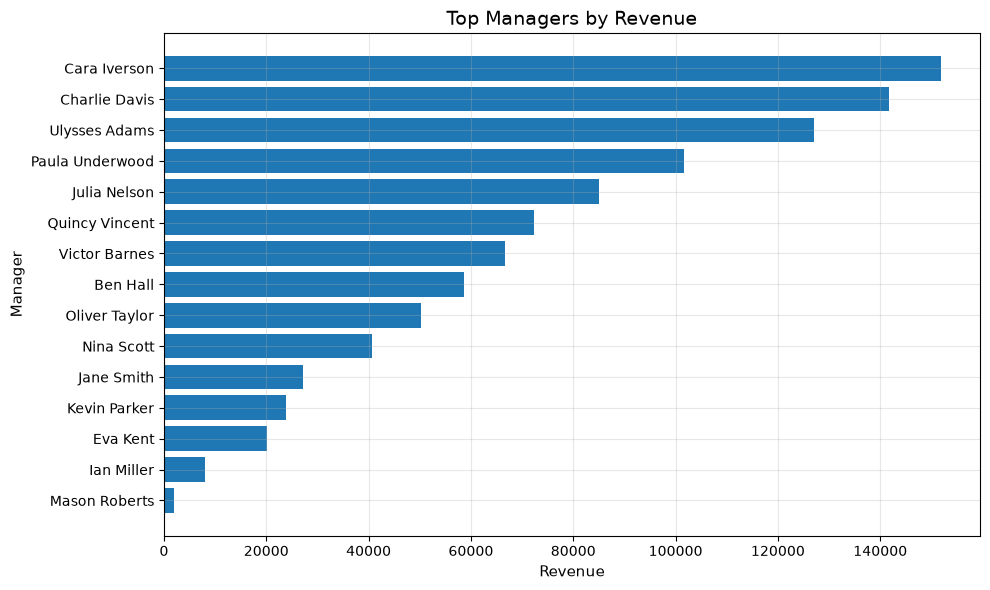

In [129]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_managers_by_revenue.sort_values('Revenue')['Deal Owner Name'],
    top_managers_by_revenue.sort_values('Revenue')['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Manager')
plt.title('Top Managers by Revenue')
plt.tight_layout()
plt.show()

### SLA by Manager

I analyze lead response speed by manager.

`SLA` shows the time between lead creation and the first sales contact or response.

In [130]:
deals['SLA Minutes'] = deals['SLA'].dt.total_seconds() / 60

In [131]:
manager_sla_summary = (
    deals[deals['SLA Minutes'].notna()]
    .groupby('Deal Owner Name', dropna=False)
    .agg(
        deals_with_sla=('Id', 'count'),
        avg_sla_minutes=('SLA Minutes', 'mean'),
        median_sla_minutes=('SLA Minutes', 'median')
    )
    .reset_index()
)

manager_sla_summary = manager_sla_summary.rename(columns={
    'deals_with_sla': 'Deals with SLA',
    'avg_sla_minutes': 'Avg SLA Minutes',
    'median_sla_minutes': 'Median SLA Minutes'
})

manager_sla_summary = manager_sla_summary.sort_values(
    'Median SLA Minutes',
    ascending=True
)

manager_sla_summary

,Deal Owner Name,Deals with SLA,Avg SLA Minutes,Median SLA Minutes
3,Bob Brown,131,718.50,54.92
22,Unknown Manager,15,195.32,72.78
10,Jane Smith,698,"1,972.15",152.99
16,Oliver Taylor,156,"1,967.57",179.59
6,Diana Evans,716,854.68,219.11
7,Eva Kent,345,762.89,255.30
5,Charlie Davis,2137,"2,233.66",265.75
17,Paula Underwood,1390,"1,087.09",294.71
21,Ulysses Adams,1702,"1,312.17",295.47
8,George King,76,"2,200.50",305.17


### Deal Duration by Manager

I additionally analyze the average time from deal creation to closing by manager.

Only deals with valid date logic are used.

In [132]:
manager_duration_summary = (
    valid_deal_duration
    .groupby('Deal Owner Name', dropna=False)
    .agg(
        deals_with_duration=('Id', 'count'),
        avg_deal_duration_days=('Deal Duration Days', 'mean'),
        median_deal_duration_days=('Deal Duration Days', 'median')
    )
    .reset_index()
)

manager_duration_summary = manager_duration_summary.rename(columns={
    'deals_with_duration': 'Deals with Duration',
    'avg_deal_duration_days': 'Avg Deal Duration Days',
    'median_deal_duration_days': 'Median Deal Duration Days'
})

manager_duration_summary = manager_duration_summary.sort_values(
    'Median Deal Duration Days',
    ascending=True
)

manager_duration_summary

,Deal Owner Name,Deals with Duration,Avg Deal Duration Days,Median Deal Duration Days
0,Alice Johnson,25,1.12,0.00
19,Rachel White,744,2.75,0.00
26,Yara Edwards,48,6.71,1.00
1,Amy Green,30,2.17,1.50
3,Bob Brown,325,2.36,2.00
24,Wendy Clark,1,2.00,2.00
23,Victor Barnes,469,9.32,2.00
20,Sam Young,53,2.85,2.00
7,Eva Kent,218,5.08,2.00
2,Ben Hall,572,5.12,2.00


### Manager Summary: Deals, Payments, Revenue and SLA

I combine manager performance metrics with SLA to compare not only outcomes, but also lead response speed.

In [133]:
manager_performance_summary = manager_summary.merge(
    manager_sla_summary,
    on='Deal Owner Name',
    how='left'
)

manager_performance_summary = manager_performance_summary.merge(
    manager_duration_summary,
    on='Deal Owner Name',
    how='left'
)

manager_performance_summary = manager_performance_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

manager_performance_summary

,Deal Owner Name,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %",Deals with SLA,Avg SLA Minutes,Median SLA Minutes,Deals with Duration,Avg Deal Duration Days,Median Deal Duration Days
0,Charlie Davis,2963,148,"141,750.00",957.77,"1,000.00",4.99,"2,137.00","2,233.66",265.75,"2,163.00",19.77,5.00
1,Ulysses Adams,2165,141,"127,100.00",901.42,"1,000.00",6.51,"1,702.00","1,312.17",295.47,"1,478.00",17.63,4.00
2,Paula Underwood,1862,93,"101,650.00","1,093.01","1,000.00",4.99,"1,390.00","1,087.09",294.71,"1,289.00",12.32,3.00
3,Julia Nelson,2241,93,"85,051.00",914.53,"1,000.00",4.15,"1,613.00","2,035.22",428.12,"1,514.00",19.14,5.00
4,Quincy Vincent,1884,65,"72,400.00","1,113.85","1,000.00",3.45,"1,468.00","1,282.86",348.24,"1,345.00",14.68,4.00
5,Oliver Taylor,163,50,"50,250.00","1,005.00","1,000.00",30.67,156.00,"1,967.57",179.59,65.00,74.86,47.00
6,Ben Hall,1345,46,"58,700.00","1,276.09","1,000.00",3.42,"1,032.00","1,492.77",319.42,572.00,5.12,2.00
7,Nina Scott,1283,46,"40,700.00",904.44,"1,000.00",3.59,884.00,"2,038.20",521.99,878.00,23.46,6.00
8,Victor Barnes,1232,44,"66,700.00","1,515.91","1,000.00",3.57,996.00,"3,012.77",332.82,469.00,9.32,2.00
9,Kevin Parker,574,40,"23,950.00",921.15,"1,000.00",6.97,453.00,"6,408.31",757.75,195.00,28.13,3.00


High revenue is not always driven only by the number of paid deals.

For example, Cara Iverson has fewer paid deals than the volume leaders, but the highest revenue because of a higher average check.

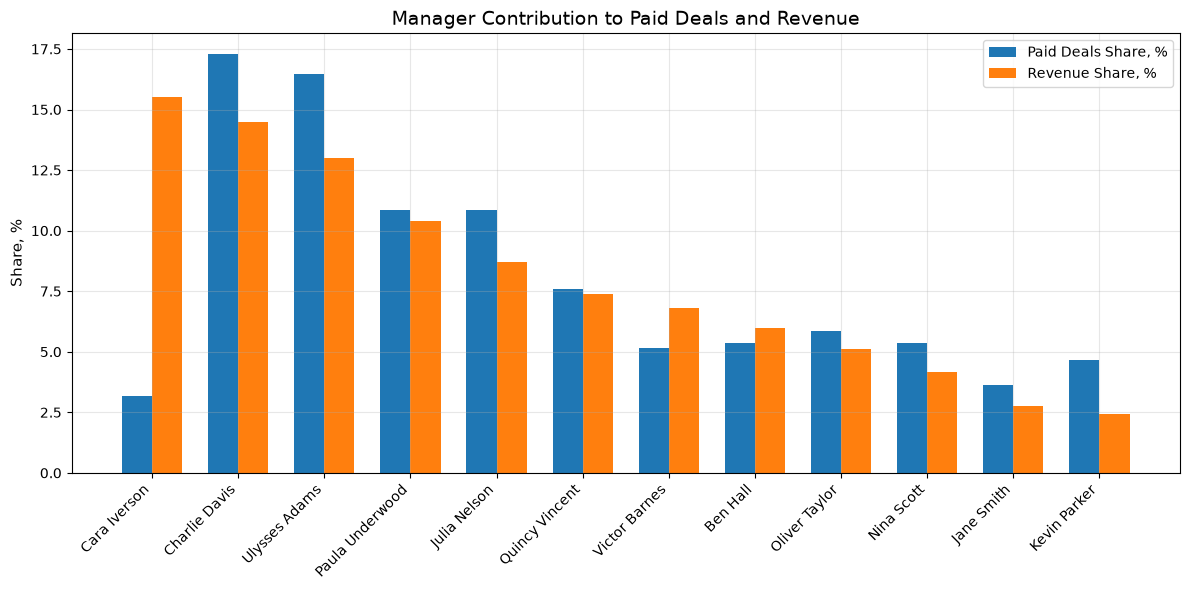

In [134]:
manager_share_plot = (
    manager_performance_summary[
        (manager_performance_summary['Paid Deals'] > 0) &
        (manager_performance_summary['Revenue'] > 0)
    ]
    .copy()
)

manager_share_plot['Paid Deals Share, %'] = (
    manager_share_plot['Paid Deals'] / manager_share_plot['Paid Deals'].sum() * 100
)

manager_share_plot['Revenue Share, %'] = (
    manager_share_plot['Revenue'] / manager_share_plot['Revenue'].sum() * 100
)

manager_share_plot = (
    manager_share_plot
    .sort_values('Revenue Share, %', ascending=False)
    .head(12)
)

x = np.arange(len(manager_share_plot))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    manager_share_plot['Paid Deals Share, %'],
    width,
    label='Paid Deals Share, %'
)

plt.bar(
    x + width / 2,
    manager_share_plot['Revenue Share, %'],
    width,
    label='Revenue Share, %'
)

plt.xticks(
    x,
    manager_share_plot['Deal Owner Name'],
    rotation=45,
    ha='right'
)

plt.ylabel('Share, %')
plt.title('Manager Contribution to Paid Deals and Revenue')
plt.legend()

plt.tight_layout()
plt.show()

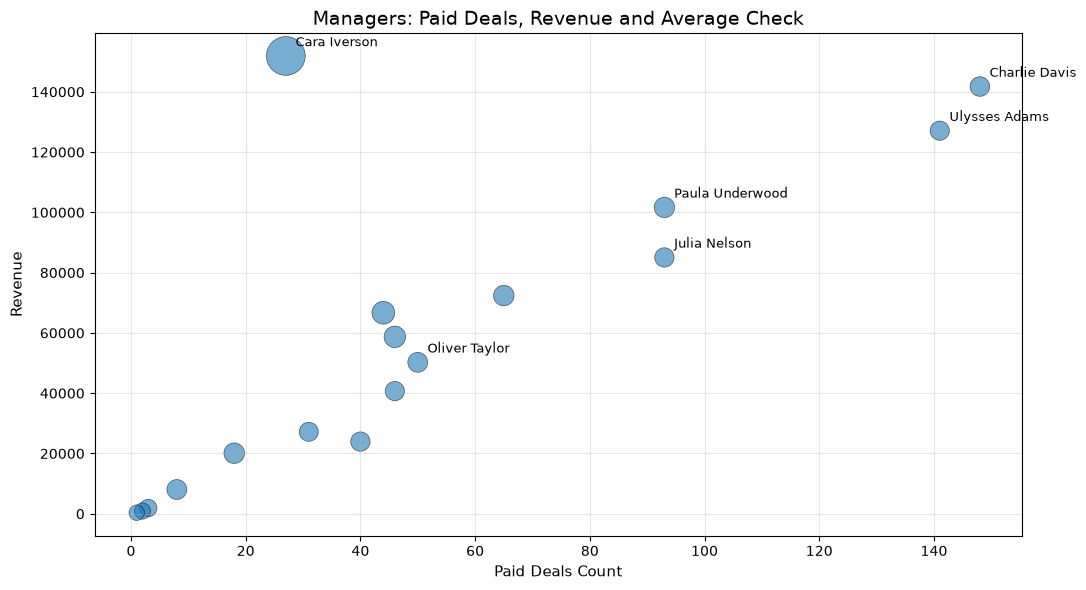

In [135]:
manager_paid_revenue_plot = manager_performance_summary[
    (manager_performance_summary['Paid Deals'] > 0) &
    (manager_performance_summary['Revenue'] > 0)
].copy()

manager_paid_revenue_plot['Point Size'] = (
    manager_paid_revenue_plot['Avg Revenue'] /
    manager_paid_revenue_plot['Avg Revenue'].max() * 700 + 80
)

key_managers = [
    'Charlie Davis',
    'Ulysses Adams',
    'Paula Underwood',
    'Julia Nelson',
    'Cara Iverson',
    'Oliver Taylor'
]

plt.figure(figsize=(11, 6))

plt.scatter(
    manager_paid_revenue_plot['Paid Deals'],
    manager_paid_revenue_plot['Revenue'],
    s=manager_paid_revenue_plot['Point Size'],
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

for _, row in manager_paid_revenue_plot.iterrows():
    if row['Deal Owner Name'] in key_managers:
        plt.annotate(
            row['Deal Owner Name'],
            xy=(row['Paid Deals'], row['Revenue']),
            xytext=(7, 7),
            textcoords='offset points',
            fontsize=9
        )

plt.xlabel('Paid Deals Count')
plt.ylabel('Revenue')
plt.title('Managers: Paid Deals, Revenue and Average Check')

plt.tight_layout()
plt.show()

For this chart, I use only managers with at least 100 deals to remove micro-samples and make the comparison more stable.

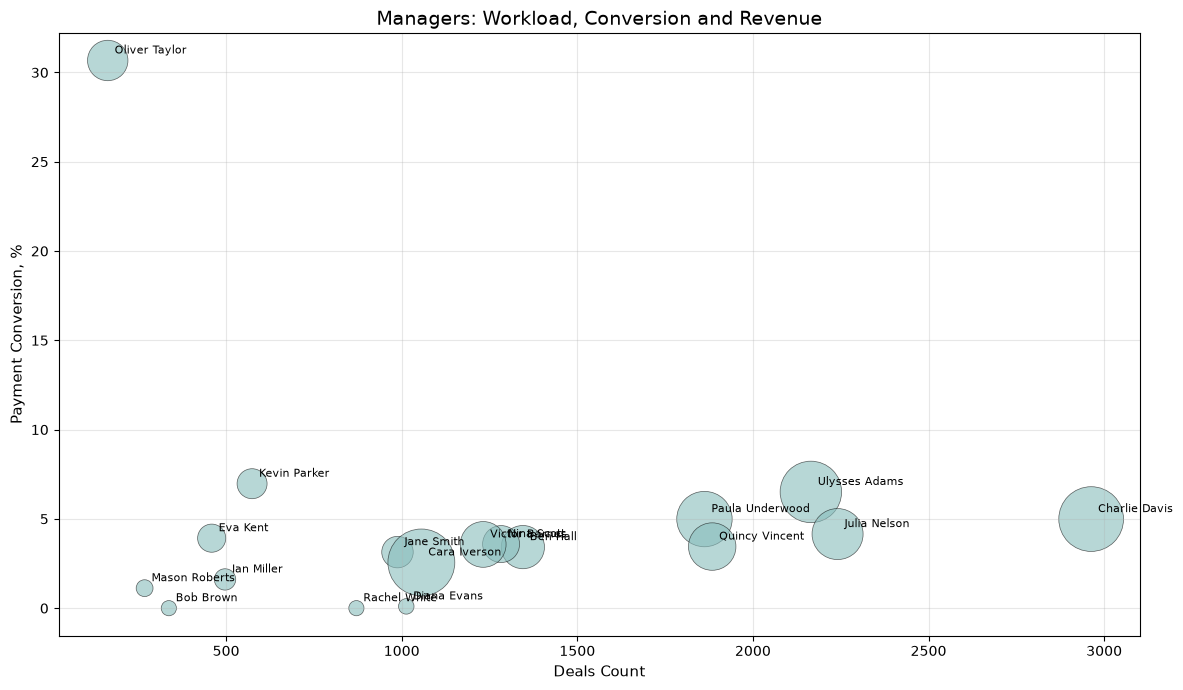

In [136]:
manager_bubble_plot = manager_performance_summary[
    manager_performance_summary['Deals Count'] >= 100
].copy()

manager_bubble_plot['Bubble Size'] = (
    manager_bubble_plot['Revenue'] / manager_bubble_plot['Revenue'].max() * 2200 + 120
)

plt.figure(figsize=(12, 7))

plt.scatter(
    manager_bubble_plot['Deals Count'],
    manager_bubble_plot['Payment Conversion, %'],
    s=manager_bubble_plot['Bubble Size'],
    alpha=0.6,
    color=scatter_color,
    edgecolors='black',
    linewidth=0.5
)

for _, row in manager_bubble_plot.iterrows():
    plt.annotate(
        row['Deal Owner Name'],
        xy=(row['Deals Count'], row['Payment Conversion, %']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Deals Count')
plt.ylabel('Payment Conversion, %')
plt.title('Managers: Workload, Conversion and Revenue')

plt.tight_layout()
plt.show()

### Manager Call Activity

I analyze call activity by manager: number of calls, average call duration and median call duration.

Call analysis is based on `Call Owner Name`.

In [137]:
calls_manager_summary = (
    valid_calls_duration
    .groupby('Call Owner Name', dropna=False)
    .agg(
        calls_count=('Id', 'count'),
        avg_call_duration=('Call Duration (in seconds)', 'mean'),
        median_call_duration=('Call Duration (in seconds)', 'median')
    )
    .reset_index()
)

calls_manager_summary = calls_manager_summary.rename(columns={
    'calls_count': 'Calls Count',
    'avg_call_duration': 'Avg Call Duration',
    'median_call_duration': 'Median Call Duration'
})

calls_manager_summary = calls_manager_summary.sort_values(
    'Calls Count',
    ascending=False
)

calls_manager_summary

,Call Owner Name,Calls Count,Avg Call Duration,Median Call Duration
31,Yara Edwards,9059,94.30,6.00
16,Julia Nelson,7445,202.19,6.00
13,Ian Miller,7215,118.74,9.00
5,Charlie Davis,7213,216.97,8.00
7,Diana Evans,6857,183.40,6.00
27,Ulysses Adams,6085,201.60,7.00
1,Amy Green,5982,97.74,15.00
20,Nina Scott,5581,126.26,6.00
17,Kevin Parker,5397,125.13,6.00
28,Victor Barnes,5370,145.12,43.00


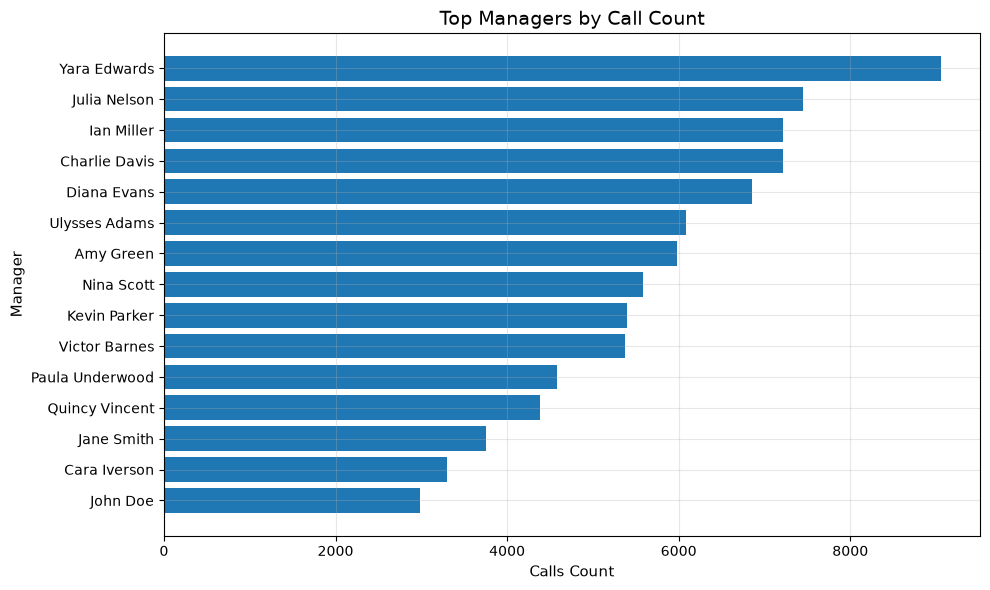

In [138]:
top_managers_by_calls = calls_manager_summary.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_managers_by_calls.sort_values('Calls Count')['Call Owner Name'],
    top_managers_by_calls.sort_values('Calls Count')['Calls Count']
)

plt.xlabel('Calls Count')
plt.ylabel('Manager')
plt.title('Top Managers by Call Count')
plt.tight_layout()
plt.show()

### Comparing Deals and Calls by Manager

I compare manager metrics from deals and calls.

This is an aggregated comparison: it reflects overall manager activity but does not link every call to a specific deal.

In [139]:
manager_sales_calls_summary = manager_performance_summary.merge(
    calls_manager_summary,
    left_on='Deal Owner Name',
    right_on='Call Owner Name',
    how='left'
)

manager_sales_calls_summary = manager_sales_calls_summary.drop(columns=['Call Owner Name'])

manager_sales_calls_summary['Calls per Deal'] = (
    manager_sales_calls_summary['Calls Count'] / manager_sales_calls_summary['Deals Count']
).replace([np.inf, -np.inf], np.nan)

manager_sales_calls_summary['Calls per Paid Deal'] = (
    manager_sales_calls_summary['Calls Count'] / manager_sales_calls_summary['Paid Deals']
).replace([np.inf, -np.inf], np.nan)

manager_sales_calls_summary = manager_sales_calls_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

manager_sales_calls_summary

,Deal Owner Name,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %",Deals with SLA,Avg SLA Minutes,Median SLA Minutes,Deals with Duration,Avg Deal Duration Days,Median Deal Duration Days,Calls Count,Avg Call Duration,Median Call Duration,Calls per Deal,Calls per Paid Deal
0,Charlie Davis,2963,148,"141,750.00",957.77,"1,000.00",4.99,"2,137.00","2,233.66",265.75,"2,163.00",19.77,5.00,"7,213.00",216.97,8.00,2.43,48.74
1,Ulysses Adams,2165,141,"127,100.00",901.42,"1,000.00",6.51,"1,702.00","1,312.17",295.47,"1,478.00",17.63,4.00,"6,085.00",201.60,7.00,2.81,43.16
2,Paula Underwood,1862,93,"101,650.00","1,093.01","1,000.00",4.99,"1,390.00","1,087.09",294.71,"1,289.00",12.32,3.00,"4,580.00",196.15,10.00,2.46,49.25
3,Julia Nelson,2241,93,"85,051.00",914.53,"1,000.00",4.15,"1,613.00","2,035.22",428.12,"1,514.00",19.14,5.00,"7,445.00",202.19,6.00,3.32,80.05
4,Quincy Vincent,1884,65,"72,400.00","1,113.85","1,000.00",3.45,"1,468.00","1,282.86",348.24,"1,345.00",14.68,4.00,"4,383.00",270.68,8.00,2.33,67.43
5,Oliver Taylor,163,50,"50,250.00","1,005.00","1,000.00",30.67,156.00,"1,967.57",179.59,65.00,74.86,47.00,10.00,103.90,17.00,0.06,0.20
6,Ben Hall,1345,46,"58,700.00","1,276.09","1,000.00",3.42,"1,032.00","1,492.77",319.42,572.00,5.12,2.00,"2,947.00",249.57,9.00,2.19,64.07
7,Nina Scott,1283,46,"40,700.00",904.44,"1,000.00",3.59,884.00,"2,038.20",521.99,878.00,23.46,6.00,"5,581.00",126.26,6.00,4.35,121.33
8,Victor Barnes,1232,44,"66,700.00","1,515.91","1,000.00",3.57,996.00,"3,012.77",332.82,469.00,9.32,2.00,"5,370.00",145.12,43.00,4.36,122.05
9,Kevin Parker,574,40,"23,950.00",921.15,"1,000.00",6.97,453.00,"6,408.31",757.75,195.00,28.13,3.00,"5,397.00",125.13,6.00,9.40,134.93


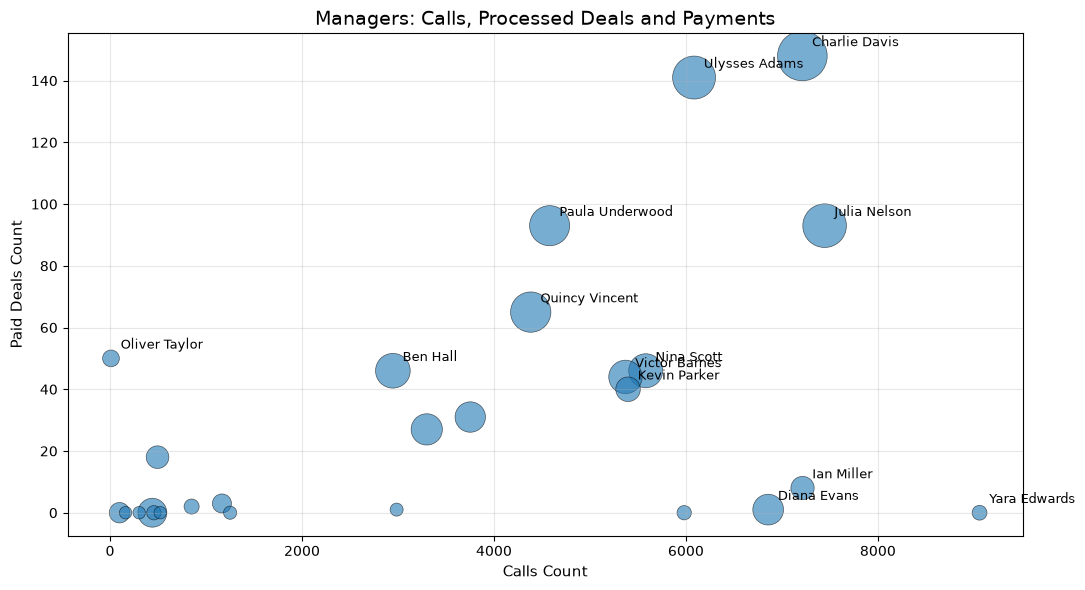

In [140]:
manager_calls_deals_paid_plot = manager_sales_calls_summary[
    (manager_sales_calls_summary['Deals Count'] > 0) |
    (manager_sales_calls_summary['Calls Count'] > 0)
].copy()

manager_calls_deals_paid_plot['Bubble Size'] = (
    manager_calls_deals_paid_plot['Deals Count'] /
    manager_calls_deals_paid_plot['Deals Count'].max() * 1200 + 80
)

key_managers = manager_calls_deals_paid_plot[
    (manager_calls_deals_paid_plot['Paid Deals'] >= 40) |
    (manager_calls_deals_paid_plot['Deals Count'] >= 1800) |
    (manager_calls_deals_paid_plot['Calls Count'] >= 6000)
]['Deal Owner Name'].tolist()

plt.figure(figsize=(11, 6))

plt.scatter(
    manager_calls_deals_paid_plot['Calls Count'],
    manager_calls_deals_paid_plot['Paid Deals'],
    s=manager_calls_deals_paid_plot['Bubble Size'],
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

for _, row in manager_calls_deals_paid_plot.iterrows():
    if row['Deal Owner Name'] in key_managers:
        plt.annotate(
            row['Deal Owner Name'],
            xy=(row['Calls Count'], row['Paid Deals']),
            xytext=(7, 7),
            textcoords='offset points',
            fontsize=9
        )

plt.xlabel('Calls Count')
plt.ylabel('Paid Deals Count')
plt.title('Managers: Calls, Processed Deals and Payments')

plt.tight_layout()
plt.show()

### Managers and Campaigns

I additionally review the relationship between managers and advertising campaigns.

This view helps understand which campaigns managers worked with and which manager-campaign combinations produced more paid deals and revenue.

In [141]:
manager_campaign_summary = (
    deals[deals['Campaign'].notna()]
    .groupby(['Deal Owner Name', 'Campaign'], dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

manager_campaign_summary['Payment Conversion, %'] = (
    manager_campaign_summary['paid_deals'] / manager_campaign_summary['deals_count'] * 100
).round(2)

manager_campaign_summary = manager_campaign_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

manager_campaign_summary = manager_campaign_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

manager_campaign_summary.head(30)

,Deal Owner Name,Campaign,Deals Count,Paid Deals,Revenue,"Payment Conversion, %"
283,Charlie Davis,performancemax_digitalmarkt_ru_DE,375,24,"26,350.00",6.40
1080,Ulysses Adams,performancemax_digitalmarkt_ru_DE,275,21,"20,300.00",7.64
592,Julia Nelson,performancemax_digitalmarkt_ru_DE,305,15,"12,800.00",4.92
511,Jane Smith,performancemax_digitalmarkt_ru_DE,163,11,"9,000.00",6.75
201,Charlie Davis,02.07.23wide_DE,145,9,"9,700.00",6.21
1018,Ulysses Adams,12.07.2023wide_DE,162,9,"8,100.00",5.56
1006,Ulysses Adams,02.07.23wide_DE,92,9,"7,950.00",9.78
720,Nina Scott,performancemax_digitalmarkt_ru_DE,133,9,"5,450.00",6.77
773,Paula Underwood,12.07.2023wide_DE,139,8,"8,600.00",5.76
835,Paula Underwood,performancemax_digitalmarkt_ru_DE,201,8,"8,100.00",3.98


### Managers and Sources

I additionally analyze which sources managers worked with.

This is important for fair manager comparison because sources may differ in lead quality and payment probability.

In [142]:
manager_source_summary = (
    deals
    .groupby(['Deal Owner Name', 'Source'], dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

manager_source_summary['Payment Conversion, %'] = (
    manager_source_summary['paid_deals'] / manager_source_summary['deals_count'] * 100
).round(2)

manager_source_summary = manager_source_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

manager_source_summary = manager_source_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

manager_source_summary.head(30)

,Deal Owner Name,Source,Deals Count,Paid Deals,Revenue,"Payment Conversion, %"
48,Charlie Davis,Facebook Ads,716,36,"37,450.00",5.03
220,Ulysses Adams,Facebook Ads,463,35,"29,450.00",7.56
49,Charlie Davis,Google Ads,573,32,"33,700.00",5.58
221,Ulysses Adams,Google Ads,412,29,"24,500.00",7.04
118,Julia Nelson,Facebook Ads,510,25,"24,000.00",4.90
50,Charlie Davis,Organic,283,24,"27,450.00",8.48
119,Julia Nelson,Google Ads,446,21,"16,600.00",4.71
222,Ulysses Adams,Organic,192,20,"21,700.00",10.42
177,Paula Underwood,Organic,204,20,"21,600.00",9.80
176,Paula Underwood,Google Ads,335,17,"21,600.00",5.07


### SLA and Payment Conversion

I additionally check how payment conversion differs by lead response speed.

For this, deals are grouped into SLA ranges.

In [143]:
sla_deals = deals[
    deals['SLA Minutes'].notna()
].copy()

sla_bins = [0, 5, 15, 60, 1440, np.inf]
sla_labels = [
    '0–5 min',
    '5–15 min',
    '15–60 min',
    '1–24 hours',
    '24+ hours'
]

sla_deals['SLA Group'] = pd.cut(
    sla_deals['SLA Minutes'],
    bins=sla_bins,
    labels=sla_labels,
    include_lowest=True
)

In [144]:
sla_conversion_summary = (
    sla_deals
    .groupby('SLA Group', observed=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

sla_conversion_summary['Payment Conversion, %'] = (
    sla_conversion_summary['paid_deals'] / sla_conversion_summary['deals_count'] * 100
).round(2)

sla_conversion_summary = sla_conversion_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

sla_conversion_summary

,SLA Group,Deals Count,Paid Deals,Revenue,"Payment Conversion, %"
0,0–5 min,239,12,"11,300.00",5.02
1,5–15 min,749,51,"42,950.00",6.81
2,15–60 min,2484,148,"185,150.00",5.96
3,1–24 hours,10200,537,"599,750.00",5.26
4,24+ hours,1861,83,"112,450.00",4.46


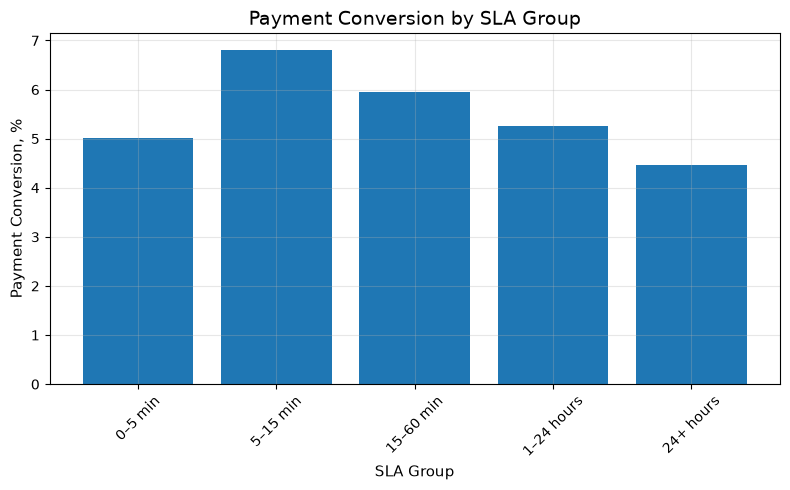

In [145]:
plt.figure(figsize=(8, 5))
plt.bar(
    sla_conversion_summary['SLA Group'].astype(str),
    sla_conversion_summary['Payment Conversion, %']
)

plt.xlabel('SLA Group')
plt.ylabel('Payment Conversion, %')
plt.title('Payment Conversion by SLA Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

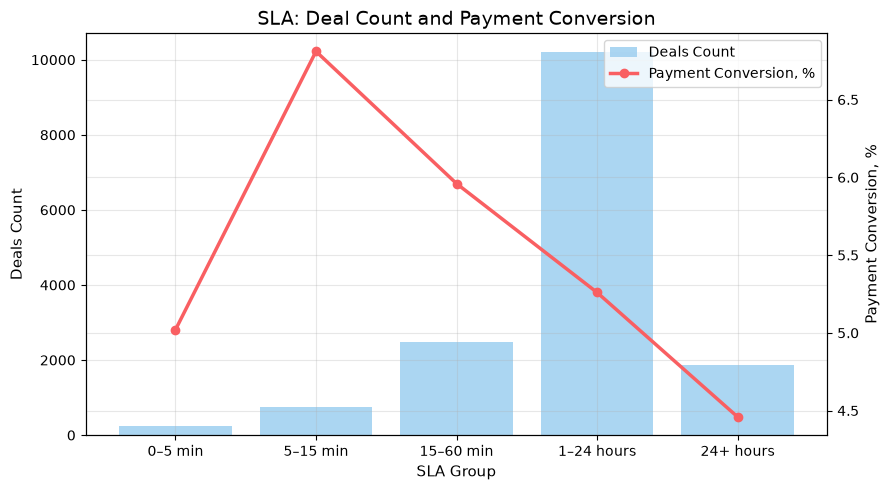

In [146]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    sla_conversion_summary['SLA Group'].astype(str),
    sla_conversion_summary['Deals Count'],
    label='Deals Count',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('SLA Group')
ax1.set_ylabel('Deals Count')

ax2 = ax1.twinx()

ax2.plot(
    sla_conversion_summary['SLA Group'].astype(str),
    sla_conversion_summary['Payment Conversion, %'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Payment Conversion, %'
)

ax2.set_ylabel('Payment Conversion, %')

plt.title('SLA: Deal Count and Payment Conversion')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper right'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales Team Performance Summary

Manager workload and performance are unevenly distributed.

By processed deals, the leaders are `Charlie Davis`, `Julia Nelson`, `Ulysses Adams`, `Quincy Vincent` and `Paula Underwood`. By paid deals, `Charlie Davis` and `Ulysses Adams` lead; both also make a significant revenue contribution.

`Oliver Taylor` has the highest payment conversion at 30.67%, but only 163 deals. This is a strong result, but it should be interpreted carefully because it may reflect a different lead mix, lower workload or a longer sales cycle.

Among high-volume managers, `Ulysses Adams` stands out: 2,165 deals, 141 paid deals and 6.51% conversion. `Kevin Parker` also has strong conversion, although with a lower volume.

`Cara Iverson` is an important exception: she has only 27 paid deals but the highest revenue, 151,900, with an average check of 5,625.93 and median check of 5,000. Her deals likely differ by product mix, source or customer segment and should be reviewed separately.

Deal duration and SLA vary by manager. Some managers close deals within a median range of 0–5 days, while others have much longer cycles. `Oliver Taylor`, for example, combines the highest conversion with a median deal duration of 47 days, which supports the idea that his deals may follow a different sales pattern.

SLA analysis shows that the highest payment conversion is not in the fastest `0–5 min` group, but in the `5–15 min` group at 6.81%. The `24+ hours` group has lower conversion at 4.46%. The largest volume of deals is in the `1–24 hours` group, so optimization of this range may have the strongest absolute business impact.

Call analysis shows that the number of calls is not a direct measure of sales effectiveness. For example, high call activity does not always correspond to paid deals. This suggests that `Call Owner Name` and `Deal Owner Name` may reflect different roles or process stages.

Overall, sales effectiveness should be evaluated across multiple dimensions: deals, paid deals, revenue, SLA, calls, deal duration, lead source and lead quality.

### Key Observations

- `Charlie Davis` and `Ulysses Adams` contribute the most to paid deals and revenue.
- `Ulysses Adams` shows strong conversion with high deal volume.
- `Oliver Taylor` has the highest conversion, but with much lower lead volume and a longer closing cycle.
- `Cara Iverson` stands out with an unusually high average and median check.
- The highest SLA-based conversion is in the `5–15 min` group, not the fastest response group.
- SLA above 24 hours is associated with lower payment conversion.
- The largest number of deals and paid deals is in the `1–24 hours` SLA range.
- Call volume should be analyzed together with paid deals, revenue and manager role.
- Fair manager comparison requires consideration of source mix and lead quality.

## Product and Payment Analysis

This section analyzes products, education formats and payment types.

The goal is to understand:

- which products appear most often in deals;
- which products generate more paid deals and revenue;
- which education formats are preferred by customers;
- how payment type relates to paid deals, revenue and average check.

Because `Product`, `Education Type` and `Payment Type` are mostly filled at later funnel stages, this section focuses primarily on paid deals.

### Product Popularity and Success

I compare products by deal count, paid deals, payment conversion, revenue and average check.

In [147]:
product_summary = (
    deals
    .groupby('Product', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

product_summary['Payment Conversion, %'] = (
    product_summary['paid_deals'] / product_summary['deals_count'] * 100
).round(2)

product_summary = product_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

product_summary = product_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

product_summary

,Product,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %"
1,Digital Marketing,1990,474,"556,600.00","1,174.26","1,000.00",23.82
3,UX/UI Design,1022,229,"278,600.00","1,216.59","1,000.00",22.41
5,Web Developer,575,137,"143,450.00","1,047.08","1,000.00",23.83
4,Unknown,17,17,0.00,0.00,0.00,100.00
2,Find yourself in IT,4,1,1.00,1.00,1.00,25.00
0,Data Analytics,1,0,0.00,NaN,NaN,0.00
6,NaN,17984,0,0.00,NaN,NaN,0.00


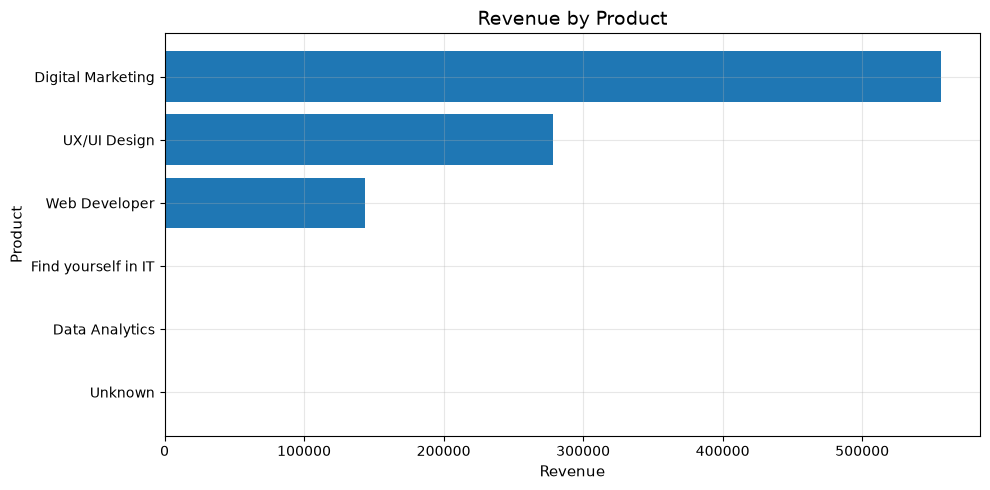

In [148]:
product_revenue_plot = (
    product_summary[
        product_summary['Product'].notna()
    ]
    .sort_values('Revenue', ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(
    product_revenue_plot['Product'],
    product_revenue_plot['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Revenue by Product')
plt.tight_layout()
plt.show()

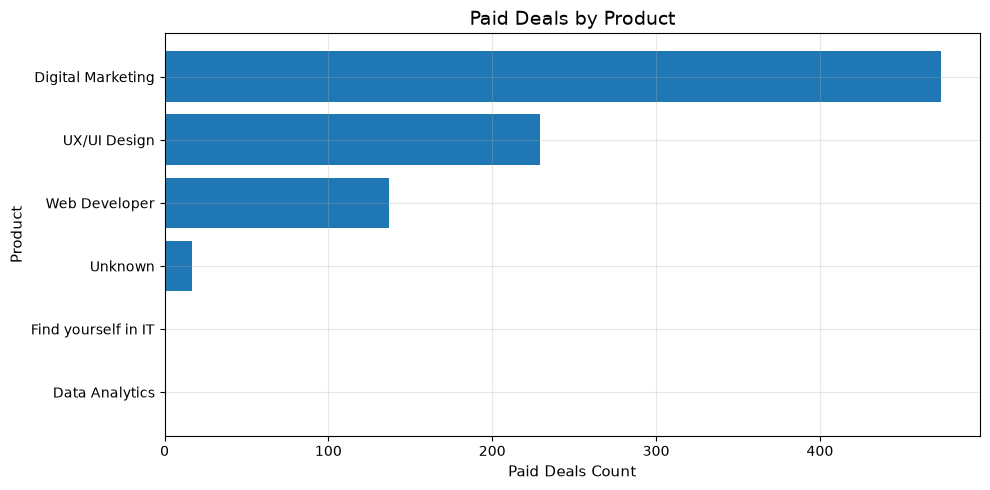

In [149]:
product_paid_plot = (
    product_summary[
        product_summary['Product'].notna()
    ]
    .sort_values('Paid Deals', ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(
    product_paid_plot['Product'],
    product_paid_plot['Paid Deals']
)

plt.xlabel('Paid Deals Count')
plt.ylabel('Product')
plt.title('Paid Deals by Product')
plt.tight_layout()
plt.show()

### Products Among Paid Deals

Because `Product` is more often filled at later deal stages, I separately analyze product distribution among paid deals.

In [150]:
paid_product_summary = (
    paid_deals
    .groupby('Product', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

paid_product_summary['Paid Deals Share, %'] = (
    paid_product_summary['paid_deals'] / paid_product_summary['paid_deals'].sum() * 100
).round(2)

paid_product_summary = paid_product_summary.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

paid_product_summary = paid_product_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

paid_product_summary

,Product,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Paid Deals Share, %"
0,Digital Marketing,474,"556,600.00","1,174.26","1,000.00",55.24
2,UX/UI Design,229,"278,600.00","1,216.59","1,000.00",26.69
4,Web Developer,137,"143,450.00","1,047.08","1,000.00",15.97
3,Unknown,17,0.00,0.00,0.00,1.98
1,Find yourself in IT,1,1.00,1.00,1.00,0.12


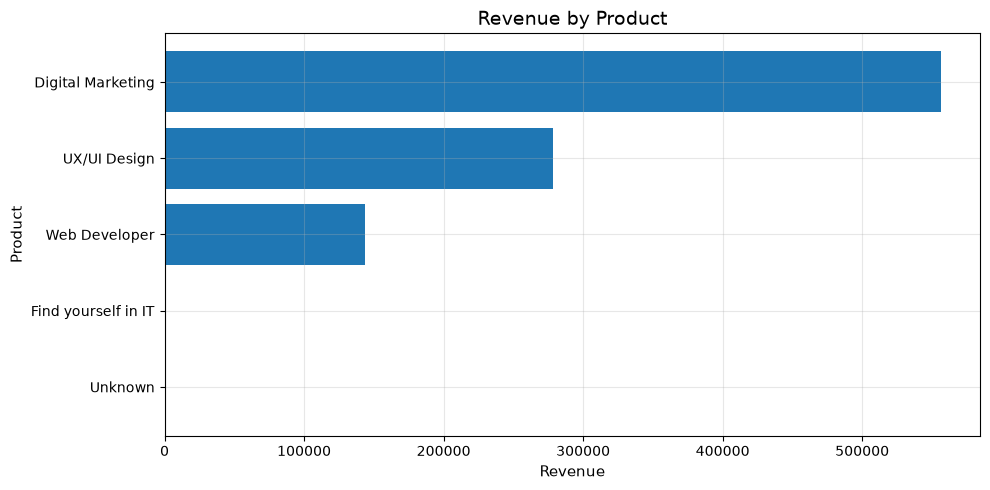

In [151]:
product_revenue_plot = (
    paid_product_summary
    .sort_values('Revenue', ascending=True)
)

plt.figure(figsize=(10, 5))

plt.barh(
    product_revenue_plot['Product'],
    product_revenue_plot['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Revenue by Product')
plt.tight_layout()
plt.show()

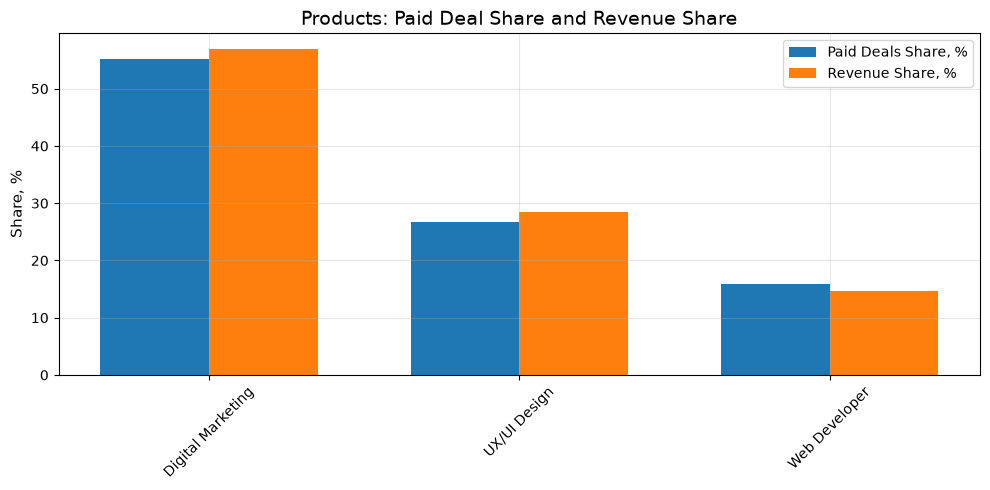

In [152]:
product_share_plot = paid_product_summary[
    (paid_product_summary['Product'] != 'Unknown') &
    (paid_product_summary['Paid Deals'] >= 5) &
    (paid_product_summary['Revenue'] > 0)
].copy()

product_share_plot = product_share_plot[
    product_share_plot['Product'] != 'Unknown'
].copy()

product_share_plot['Revenue Share, %'] = (
    product_share_plot['Revenue'] / product_share_plot['Revenue'].sum() * 100
).round(2)

x = np.arange(len(product_share_plot['Product']))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    product_share_plot['Paid Deals Share, %'],
    width,
    label='Paid Deals Share, %'
)

plt.bar(
    x + width / 2,
    product_share_plot['Revenue Share, %'],
    width,
    label='Revenue Share, %'
)

plt.xticks(
    x,
    product_share_plot['Product'],
    rotation=45
)

plt.ylabel('Share, %')
plt.title('Products: Paid Deal Share and Revenue Share')
plt.legend()
plt.tight_layout()
plt.show()

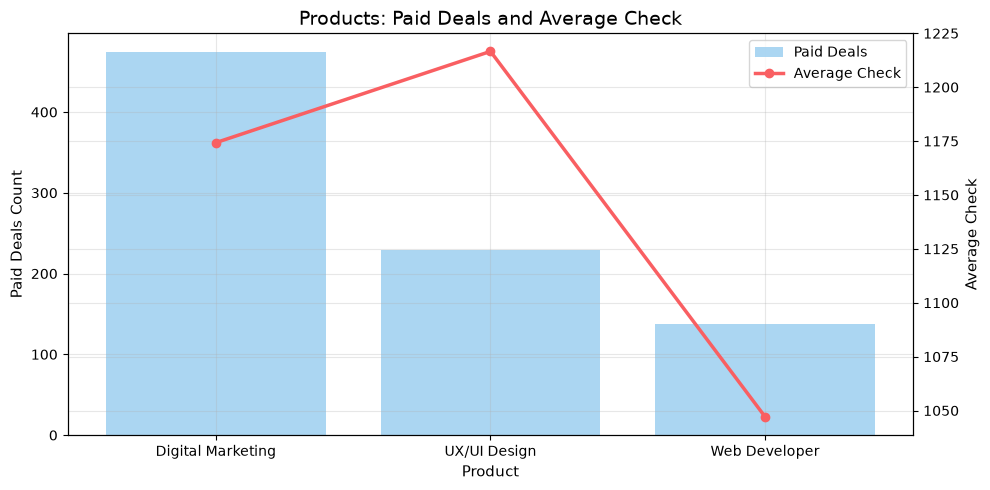

In [153]:
product_paid_avg_plot = paid_product_summary[
    (paid_product_summary['Product'] != 'Unknown') &
    (paid_product_summary['Paid Deals'] >= 5) &
    (paid_product_summary['Revenue'] > 0)
].copy()

product_paid_avg_plot = product_paid_avg_plot.sort_values(
    'Paid Deals',
    ascending=False
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    product_paid_avg_plot['Product'],
    product_paid_avg_plot['Paid Deals'],
    label='Paid Deals',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('Product')
ax1.set_ylabel('Paid Deals Count')

ax2 = ax1.twinx()

ax2.plot(
    product_paid_avg_plot['Product'],
    product_paid_avg_plot['Avg Revenue'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Average Check'
)

ax2.set_ylabel('Average Check')

plt.title('Products: Paid Deals and Average Check')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper right'
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Education Formats

I analyze `Education Type` to understand which formats are more common and which generate more paid deals and revenue.

In [154]:
education_type_summary = (
    deals
    .groupby('Education Type', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

education_type_summary['Payment Conversion, %'] = (
    education_type_summary['paid_deals'] / education_type_summary['deals_count'] * 100
).round(2)

education_type_summary = education_type_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

education_type_summary = education_type_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

education_type_summary

,Education Type,Deals Count,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Payment Conversion, %"
1,Morning,2895,662,"810,650.00","1,224.55","1,000.00",22.87
0,Evening,404,171,"161,000.00",941.52,350.00,42.33
2,Unknown,25,25,"7,001.00",700.10,"1,000.00",100.00
3,NaN,18269,0,0.00,NaN,NaN,0.00


In [155]:
# Education formats among paid deals only

paid_education_type_summary = (
    paid_deals
    .groupby('Education Type', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

paid_education_type_summary['Paid Deals Share, %'] = (
    paid_education_type_summary['paid_deals'] / paid_education_type_summary['paid_deals'].sum() * 100
).round(2)

paid_education_type_summary = paid_education_type_summary.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

paid_education_type_summary = paid_education_type_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

paid_education_type_summary

,Education Type,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Paid Deals Share, %"
1,Morning,662,"810,650.00","1,224.55","1,000.00",77.16
0,Evening,171,"161,000.00",941.52,350.00,19.93
2,Unknown,25,"7,001.00",700.10,"1,000.00",2.91


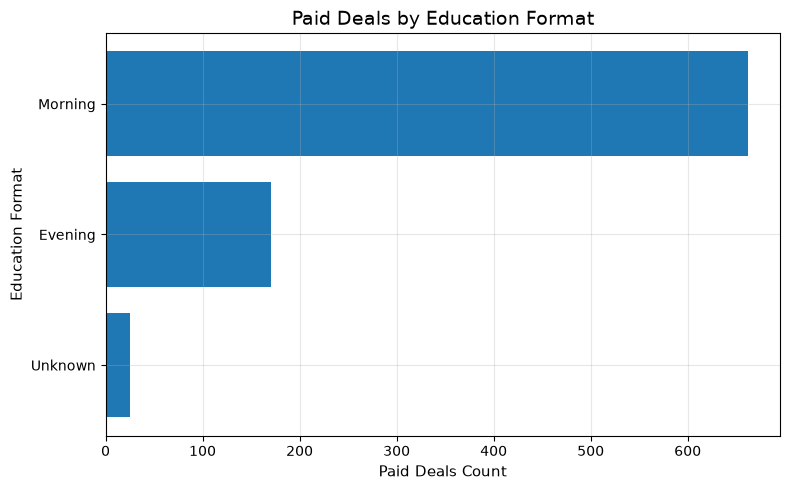

In [156]:
education_type_plot = (
    paid_education_type_summary
    .sort_values('Paid Deals', ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    education_type_plot['Education Type'],
    education_type_plot['Paid Deals']
)

plt.xlabel('Paid Deals Count')
plt.ylabel('Education Format')
plt.title('Paid Deals by Education Format')
plt.tight_layout()
plt.show()

### Payment Types

I analyze `Payment Type` to understand which payment methods are more common among paid deals and how they relate to revenue and average check.

Since payment type is primarily relevant for paid deals, the main analysis uses `paid_deals`.

In [157]:
payment_type_summary = (
    paid_deals
    .groupby('Payment Type', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

payment_type_summary['Paid Deals Share, %'] = (
    payment_type_summary['paid_deals'] / payment_type_summary['paid_deals'].sum() * 100
).round(2)

payment_type_summary = payment_type_summary.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

payment_type_summary = payment_type_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

payment_type_summary

,Payment Type,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Paid Deals Share, %"
3,Unknown,494,"628,000.00","1,311.06","1,000.00",57.58
1,Recurring Payments,250,"111,100.00",444.40,350.00,29.14
0,One Payment,113,"239,451.00","2,119.04","2,000.00",13.17
2,Reservation,1,100.00,100.00,100.00,0.12


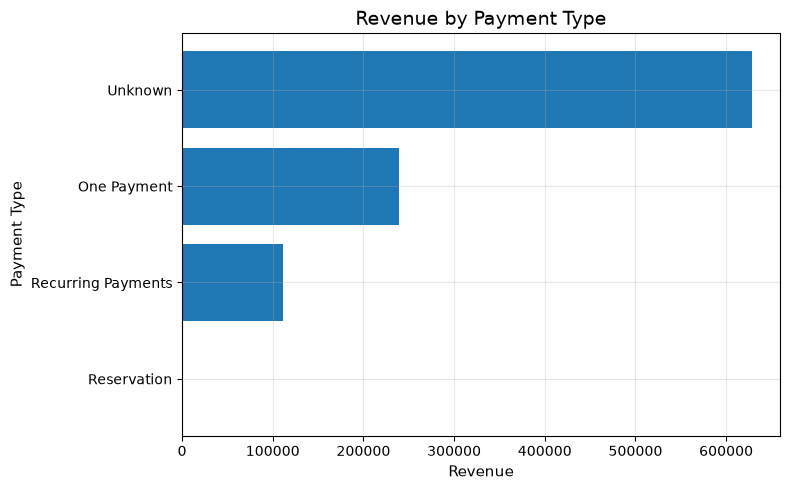

In [158]:
payment_type_revenue_plot = (
    payment_type_summary
    .sort_values('Revenue', ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    payment_type_revenue_plot['Payment Type'],
    payment_type_revenue_plot['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Payment Type')
plt.title('Revenue by Payment Type')
plt.tight_layout()
plt.show()

`Reservation` is excluded from the chart because it is a single value.

`Unknown` is kept because the large share of unknown payment type is an important data limitation.

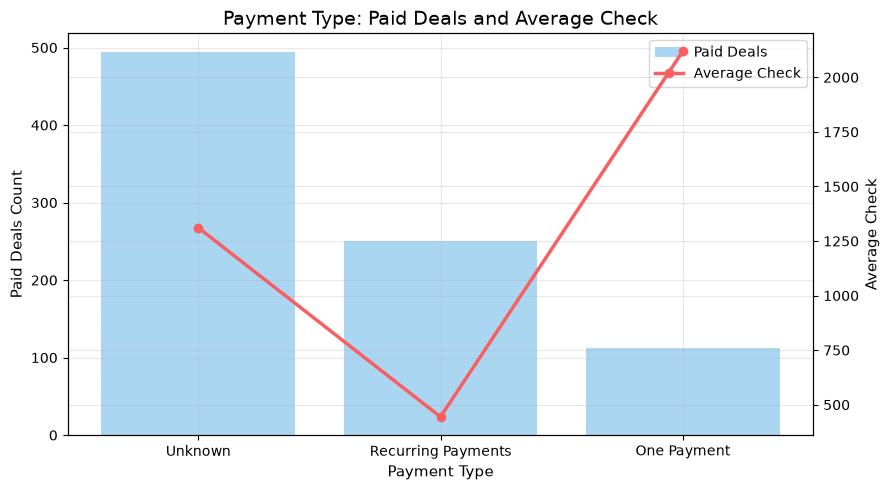

In [159]:
payment_type_plot = payment_type_summary[
    payment_type_summary['Payment Type'] != 'Reservation'
].copy()

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    payment_type_plot['Payment Type'],
    payment_type_plot['Paid Deals'],
    label='Paid Deals',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('Payment Type')
ax1.set_ylabel('Paid Deals Count')

ax2 = ax1.twinx()

ax2.plot(
    payment_type_plot['Payment Type'],
    payment_type_plot['Avg Revenue'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Average Check'
)

ax2.set_ylabel('Average Check')

plt.title('Payment Type: Paid Deals and Average Check')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper right'
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Products and Payment Types

I additionally review the relationship between `Product` and `Payment Type` among paid deals.

This view helps understand which payment types are used more often for different products.

In [160]:
product_payment_summary = (
    paid_deals
    .groupby(['Product', 'Payment Type'], dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

product_payment_summary = product_payment_summary.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

product_payment_summary = product_payment_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

product_payment_summary.head(30)

,Product,Payment Type,Paid Deals,Revenue,Avg Revenue,Median Revenue
2,Digital Marketing,Unknown,267,"366,000.00","1,370.79","1,000.00"
1,Digital Marketing,Recurring Payments,156,"74,650.00",478.53,350.00
6,UX/UI Design,Unknown,130,"172,000.00","1,323.08","1,000.00"
12,Web Developer,Unknown,82,"90,000.00","1,097.56","1,000.00"
5,UX/UI Design,Recurring Payments,68,"26,100.00",383.82,300.00
0,Digital Marketing,One Payment,51,"115,950.00","2,273.53","2,000.00"
4,UX/UI Design,One Payment,31,"80,500.00","2,596.77","2,000.00"
9,Web Developer,One Payment,28,"43,000.00","1,535.71","1,250.00"
10,Web Developer,Recurring Payments,26,"10,350.00",398.08,500.00
8,Unknown,Unknown,15,0.00,NaN,NaN


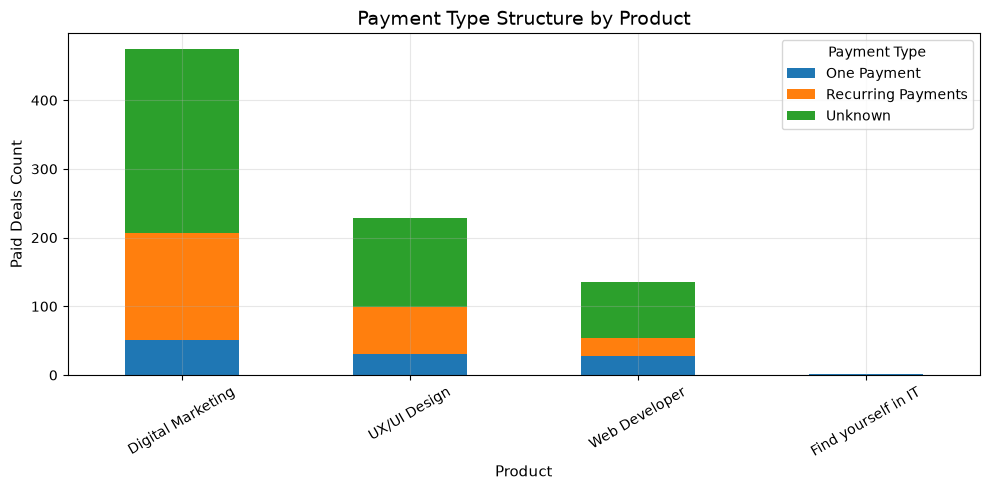

In [161]:
product_payment_pivot = (
    product_payment_summary[
        (product_payment_summary['Product'] != 'Unknown') &
        (product_payment_summary['Payment Type'] != 'Reservation')
    ]
    .pivot_table(
        index='Product',
        columns='Payment Type',
        values='Paid Deals',
        aggfunc='sum',
        fill_value=0
    )
)

product_payment_pivot = product_payment_pivot.loc[
    product_payment_pivot.sum(axis=1).sort_values(ascending=False).index
]

product_payment_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel('Product')
plt.ylabel('Paid Deals Count')
plt.title('Payment Type Structure by Product')
plt.xticks(rotation=30)
plt.legend(title='Payment Type')

plt.tight_layout()
plt.show()

### Products and Education Formats

I additionally review the relationship between `Product` and `Education Type` among paid deals.

This view helps understand which education formats are more common for different products.

In [162]:
product_education_summary = (
    paid_deals
    .groupby(['Product', 'Education Type'], dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

product_education_summary = product_education_summary.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

product_education_summary = product_education_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

product_education_summary.head(30)

,Product,Education Type,Paid Deals,Revenue,Avg Revenue,Median Revenue
1,Digital Marketing,Morning,354,"450,900.00","1,273.73","1,000.00"
5,UX/UI Design,Morning,171,"216,300.00","1,264.91","1,000.00"
7,Web Developer,Morning,137,"143,450.00","1,047.08","1,000.00"
0,Digital Marketing,Evening,113,"98,700.00",873.45,350.00
4,UX/UI Design,Evening,58,"62,300.00","1,074.14",300.00
6,Unknown,Unknown,17,0.00,0.00,0.00
2,Digital Marketing,Unknown,7,"7,000.00","1,000.00","1,000.00"
3,Find yourself in IT,Unknown,1,1.00,1.00,1.00


### Average Check by Product without Symbolic Payments

I additionally calculate average check by product without symbolic payments to check whether they distort average values.

In [163]:
paid_deals_without_symbolic = paid_deals[paid_deals['Is Symbolic Payment'] == False].copy()

In [164]:
product_revenue_without_symbolic = (
    paid_deals_without_symbolic
    .groupby('Product', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

product_revenue_without_symbolic = product_revenue_without_symbolic.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

product_revenue_without_symbolic = product_revenue_without_symbolic.sort_values(
    ['Revenue', 'Paid Deals'],
    ascending=False
)

product_revenue_without_symbolic

,Product,Paid Deals,Revenue,Avg Revenue,Median Revenue
0,Digital Marketing,473,"556,600.00","1,176.74","1,000.00"
1,UX/UI Design,229,"278,600.00","1,216.59","1,000.00"
3,Web Developer,137,"143,450.00","1,047.08","1,000.00"
2,Unknown,15,0.00,NaN,NaN


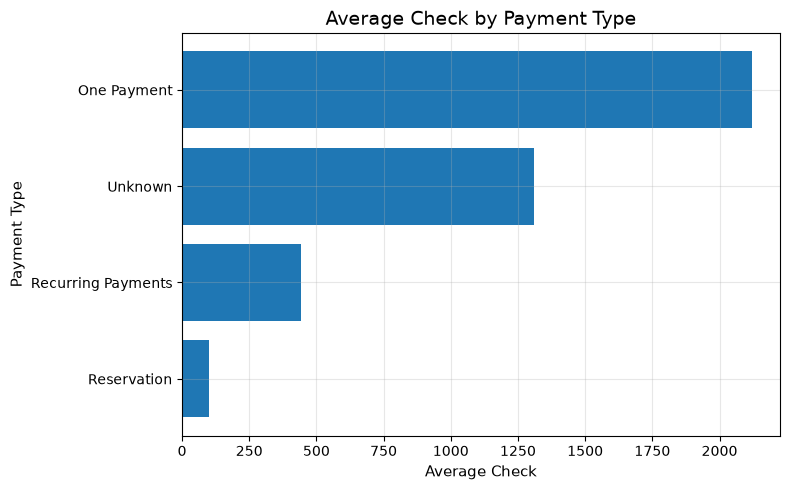

In [165]:
payment_type_avg_revenue_plot = (
    payment_type_summary
    .sort_values('Avg Revenue', ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    payment_type_avg_revenue_plot['Payment Type'],
    payment_type_avg_revenue_plot['Avg Revenue']
)

plt.xlabel('Average Check')
plt.ylabel('Payment Type')
plt.title('Average Check by Payment Type')
plt.tight_layout()
plt.show()

### Product and Payment Analysis Summary

The main contribution to paid deals and revenue comes from three products:

1. `Digital Marketing`: 474 paid deals, or 55.24% of all paid deals, and 556,600 revenue.
2. `UX/UI Design`: 229 paid deals, or 26.69% of paid deals, and 278,600 revenue. Its average check is slightly higher than for `Digital Marketing`, but the volume is lower.
3. `Web Developer`: 137 paid deals, or 15.97% of paid deals, and 143,450 revenue.

`Unknown` includes 17 paid deals without a recorded product and no calculated revenue. These deals are included in conversion but excluded from product revenue analysis. `Find yourself in IT` has a single symbolic payment, so it is not suitable for product-level conclusions.

Among paid deals, `Morning` is the dominant education format: 662 paid deals and 810,650 revenue. `Evening` is less common and has a lower median check. `Unknown` should be treated separately because missing format limits interpretation.

Payment type has a major data limitation: 494 paid deals, or 57.58%, have `Unknown Payment Type`. Among known payment types, `Recurring Payments` are more frequent, but their first payment is lower. `One Payment` is less frequent but has a much higher average and median check.

Product-payment analysis shows that many paid deals are concentrated in `Unknown` and `Recurring Payments`. `One Payment` produces a higher average check across products, which confirms that payment type strongly affects the size of the first payment and calculated revenue.

Product-format analysis shows that `Morning` dominates across the main products. Analysis without symbolic payments does not materially change the product-level picture.

Overall, `Digital Marketing` is the strongest product by scale and revenue, while `UX/UI Design` has a slightly higher average check. `One Payment` is associated with materially larger first payments.

### Key Observations

- `Digital Marketing` is the main product by paid deals and revenue.
- `UX/UI Design` ranks second and has a slightly higher average check than `Digital Marketing`.
- `Web Developer` has a smaller but stable contribution.
- `Morning` is the dominant education format among paid deals.
- `Evening` is less common and has a lower median check.
- `One Payment` has the highest average and median check.
- `Recurring Payments` are more frequent than `One Payment`, but have a lower first payment.
- A large share of `Unknown` in `Payment Type` limits interpretation.
- Symbolic payments do not distort the main product conclusions.

## Geographic Analysis

This section analyzes deal geography and the relationship between German language level and deal success.

The analysis covers:

- deal distribution by city;
- paid deals, conversion and revenue by city;
- deal distribution by German language level;
- paid deals, conversion and revenue by German language level;
- the relationship between `City` and `Level of Deutsch`.

`City` and `Level of Deutsch` have a high share of `Unknown` values, so this section is used as an additional analytical view rather than a primary source of business conclusions.

### Deal Distribution by City

I first review deal distribution by city.

Because most `City` values are unknown, I analyze both all values and known cities separately.

In [166]:
city_summary = (
    deals
    .groupby('City', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

city_summary['Payment Conversion, %'] = (
    city_summary['paid_deals'] / city_summary['deals_count'] * 100
).round(2)

city_summary['Deals Share, %'] = (
    city_summary['deals_count'] / city_summary['deals_count'].sum() * 100
).round(2)

city_summary = city_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

city_summary = city_summary.sort_values(
    'Deals Count',
    ascending=False
)

city_summary.head(20)

,City,Deals Count,Paid Deals,Revenue,"Payment Conversion, %","Deals Share, %"
779,Unknown,19430,136,"234,001.00",0.70,89.98
88,Berlin,182,78,"86,450.00",42.86,0.84
524,München,74,27,"30,600.00",36.49,0.34
290,Hamburg,62,22,"23,650.00",35.48,0.29
575,Nürnberg,45,9,"12,000.00",20.00,0.21
432,Leipzig,45,18,"16,150.00",40.00,0.21
177,Düsseldorf,33,7,"5,800.00",21.21,0.15
169,Dresden,28,9,"9,000.00",32.14,0.13
223,Frankfurt,27,7,"6,800.00",25.93,0.13
168,Dortmund,26,4,"8,500.00",15.38,0.12


In [167]:
city_summary_known = (
    city_summary[
        city_summary['City'] != 'Unknown'
    ]
    .copy()
)

city_summary_known.head(20)

,City,Deals Count,Paid Deals,Revenue,"Payment Conversion, %","Deals Share, %"
88,Berlin,182,78,"86,450.00",42.86,0.84
524,München,74,27,"30,600.00",36.49,0.34
290,Hamburg,62,22,"23,650.00",35.48,0.29
575,Nürnberg,45,9,"12,000.00",20.00,0.21
432,Leipzig,45,18,"16,150.00",40.00,0.21
177,Düsseldorf,33,7,"5,800.00",21.21,0.15
169,Dresden,28,9,"9,000.00",32.14,0.13
223,Frankfurt,27,7,"6,800.00",25.93,0.13
168,Dortmund,26,4,"8,500.00",15.38,0.12
408,Köln,25,9,"10,100.00",36.00,0.12


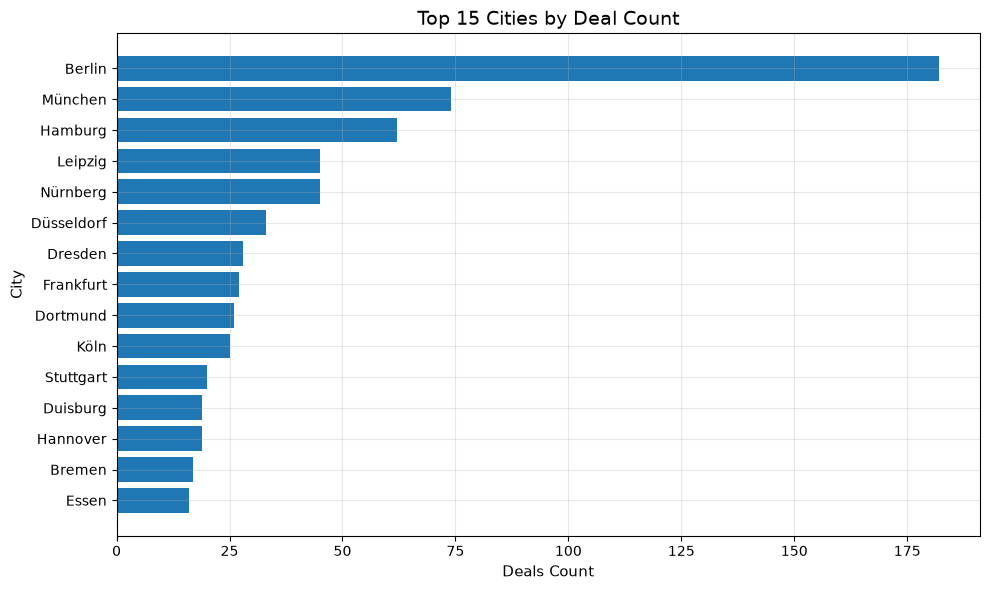

In [168]:
top_cities_by_deals = (
    city_summary_known
    .sort_values('Deals Count', ascending=False)
    .head(15)
)

top_cities_by_deals_plot = top_cities_by_deals.sort_values(
    'Deals Count',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cities_by_deals_plot['City'],
    top_cities_by_deals_plot['Deals Count']
)

plt.xlabel('Deals Count')
plt.ylabel('City')
plt.title('Top 15 Cities by Deal Count')
plt.tight_layout()
plt.show()

### Cities by Paid Deals and Conversion

I then review cities by paid deals and payment conversion.

A minimum deal-count threshold is used to avoid conclusions based on very small samples.

In [169]:
top_cities_by_paid_deals = (
    city_summary_known
    .sort_values('Paid Deals', ascending=False)
    .head(15)
)

top_cities_by_paid_deals

,City,Deals Count,Paid Deals,Revenue,"Payment Conversion, %","Deals Share, %"
88,Berlin,182,78,"86,450.00",42.86,0.84
524,München,74,27,"30,600.00",36.49,0.34
290,Hamburg,62,22,"23,650.00",35.48,0.29
432,Leipzig,45,18,"16,150.00",40.00,0.21
169,Dresden,28,9,"9,000.00",32.14,0.13
408,Köln,25,9,"10,100.00",36.00,0.12
575,Nürnberg,45,9,"12,000.00",20.00,0.21
839,Wien,12,8,"7,400.00",66.67,0.06
177,Düsseldorf,33,7,"5,800.00",21.21,0.15
223,Frankfurt,27,7,"6,800.00",25.93,0.13


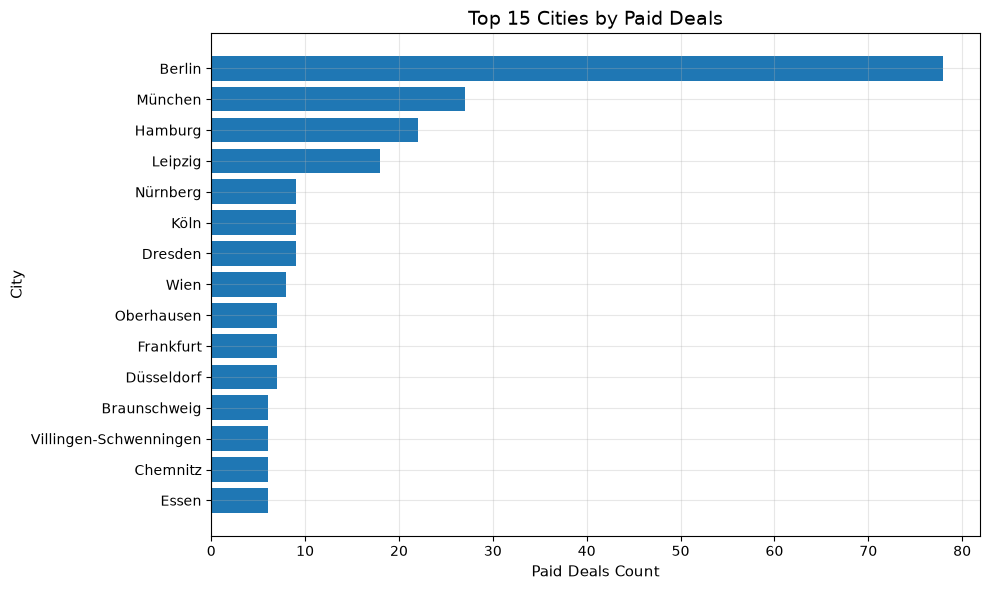

In [170]:
top_cities_by_paid_plot = top_cities_by_paid_deals.sort_values(
    'Paid Deals',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cities_by_paid_plot['City'],
    top_cities_by_paid_plot['Paid Deals']
)

plt.xlabel('Paid Deals Count')
plt.ylabel('City')
plt.title('Top 15 Cities by Paid Deals')
plt.tight_layout()
plt.show()

In [171]:
min_city_deals = 20

top_cities_by_conversion = (
    city_summary_known[
        city_summary_known['Deals Count'] >= min_city_deals
    ]
    .sort_values('Payment Conversion, %', ascending=False)
)

top_cities_by_conversion.head(15)

,City,Deals Count,Paid Deals,Revenue,"Payment Conversion, %","Deals Share, %"
88,Berlin,182,78,"86,450.00",42.86,0.84
432,Leipzig,45,18,"16,150.00",40.00,0.21
524,München,74,27,"30,600.00",36.49,0.34
408,Köln,25,9,"10,100.00",36.00,0.12
290,Hamburg,62,22,"23,650.00",35.48,0.29
169,Dresden,28,9,"9,000.00",32.14,0.13
223,Frankfurt,27,7,"6,800.00",25.93,0.13
177,Düsseldorf,33,7,"5,800.00",21.21,0.15
575,Nürnberg,45,9,"12,000.00",20.00,0.21
168,Dortmund,26,4,"8,500.00",15.38,0.12


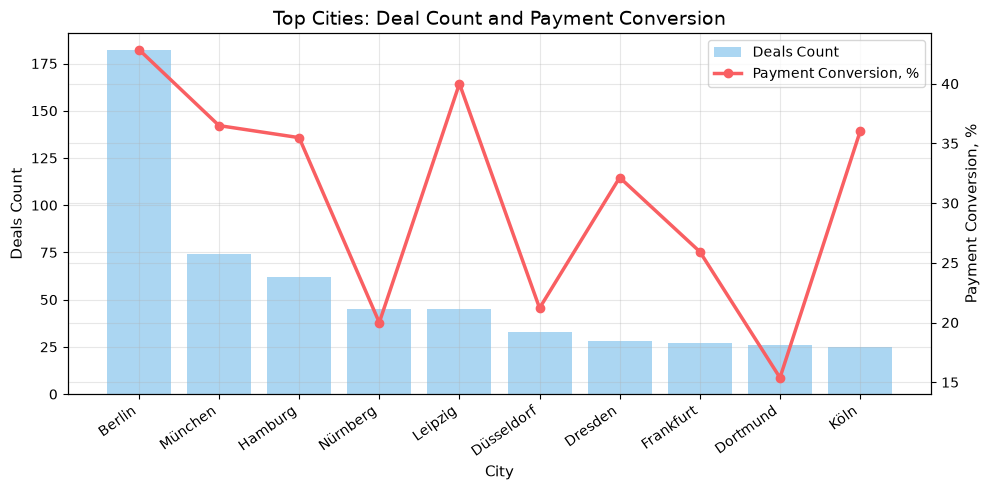

In [172]:
city_plot = (
    city_summary[
        (city_summary['City'] != 'Unknown') &
        (city_summary['Deals Count'] >= 10)
    ]
    .sort_values('Deals Count', ascending=False)
    .head(10)
    .copy()
)

x = np.arange(len(city_plot))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    x,
    city_plot['Deals Count'],
    label='Deals Count',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('City')
ax1.set_ylabel('Deals Count')
ax1.set_xticks(x)
ax1.set_xticklabels(
    city_plot['City'],
    rotation=35,
    ha='right'
)

ax2 = ax1.twinx()

ax2.plot(
    x,
    city_plot['Payment Conversion, %'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Payment Conversion, %'
)

ax2.set_ylabel('Payment Conversion, %')

plt.title('Top Cities: Deal Count and Payment Conversion')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper right'
)

ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### German Language Level and Deal Success

I analyze deal distribution by German language level.

Because most deals have an unknown language level, I review all values and known levels separately.

In [173]:
deutsch_summary = (
    deals
    .groupby('Level of Deutsch', dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

deutsch_summary['Payment Conversion, %'] = (
    deutsch_summary['paid_deals'] / deutsch_summary['deals_count'] * 100
).round(2)

deutsch_summary['Deals Share, %'] = (
    deutsch_summary['deals_count'] / deutsch_summary['deals_count'].sum() * 100
).round(2)

deutsch_summary = deutsch_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

deutsch_summary = deutsch_summary.sort_values(
    'Deals Count',
    ascending=False
)

deutsch_summary

,Level of Deutsch,Deals Count,Paid Deals,Revenue,"Payment Conversion, %","Deals Share, %"
6,Unknown,21096,688,"793,101.00",3.26,97.70
2,B1,382,137,"152,550.00",35.86,1.77
3,B2,76,18,"18,000.00",23.68,0.35
1,A2,28,9,"9,000.00",32.14,0.13
0,A1,6,3,"3,000.00",50.00,0.03
4,C1,4,3,"3,000.00",75.00,0.02
5,C2,1,0,0.00,0.00,0.00


In [174]:
deutsch_summary_known = (
    deutsch_summary[
        deutsch_summary['Level of Deutsch'] != 'Unknown'
    ]
    .copy()
)

deutsch_summary_known

,Level of Deutsch,Deals Count,Paid Deals,Revenue,"Payment Conversion, %","Deals Share, %"
2,B1,382,137,"152,550.00",35.86,1.77
3,B2,76,18,"18,000.00",23.68,0.35
1,A2,28,9,"9,000.00",32.14,0.13
0,A1,6,3,"3,000.00",50.00,0.03
4,C1,4,3,"3,000.00",75.00,0.02
5,C2,1,0,0.00,0.00,0.00


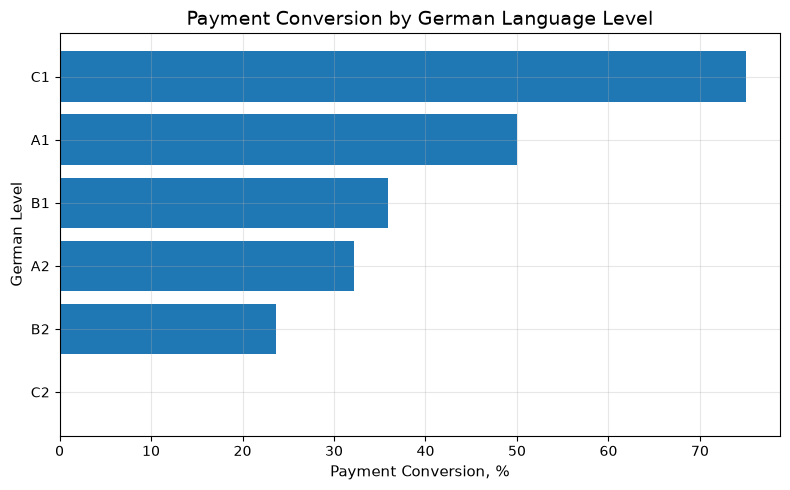

In [175]:
deutsch_conversion_plot = deutsch_summary_known.sort_values(
    'Payment Conversion, %',
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    deutsch_conversion_plot['Level of Deutsch'],
    deutsch_conversion_plot['Payment Conversion, %']
)

plt.xlabel('Payment Conversion, %')
plt.ylabel('German Level')
plt.title('Payment Conversion by German Language Level')
plt.tight_layout()
plt.show()

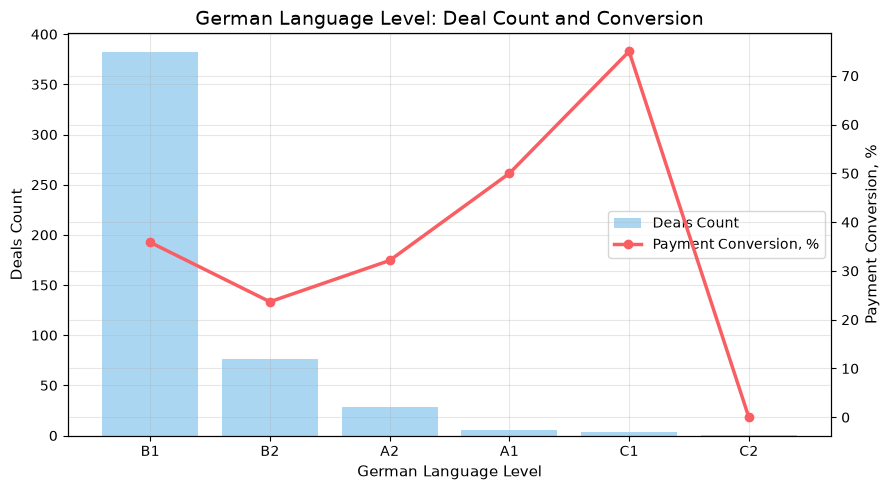

In [176]:
deutsch_plot = (
    deutsch_summary[
        deutsch_summary['Level of Deutsch'] != 'Unknown'
    ]
    .sort_values('Deals Count', ascending=False)
    .copy()
)

x = np.arange(len(deutsch_plot))

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(
    x,
    deutsch_plot['Deals Count'],
    label='Deals Count',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('German Language Level')
ax1.set_ylabel('Deals Count')
ax1.set_xticks(x)
ax1.set_xticklabels(
    deutsch_plot['Level of Deutsch'],
    rotation=0
)

ax2 = ax1.twinx()

ax2.plot(
    x,
    deutsch_plot['Payment Conversion, %'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Payment Conversion, %'
)

ax2.set_ylabel('Payment Conversion, %')

plt.title('German Language Level: Deal Count and Conversion')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='right'
)

ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### City and German Level Relationship

I additionally review the relationship between `City` and `Level of Deutsch`.

Because of the high share of `Unknown`, this is used only as an additional check and not as the basis for strong business conclusions.

In [177]:
city_deutsch_summary = (
    deals[
        (deals['City'] != 'Unknown') &
        (deals['Level of Deutsch'] != 'Unknown')
    ]
    .groupby(['City', 'Level of Deutsch'], dropna=False)
    .agg(
        deals_count=('Id', 'count'),
        paid_deals=('Is Paid', 'sum'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)

city_deutsch_summary['Payment Conversion, %'] = (
    city_deutsch_summary['paid_deals'] / city_deutsch_summary['deals_count'] * 100
).round(2)

city_deutsch_summary = city_deutsch_summary.rename(columns={
    'deals_count': 'Deals Count',
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue'
})

city_deutsch_summary = city_deutsch_summary.sort_values(
    ['Paid Deals', 'Revenue'],
    ascending=False
)

city_deutsch_summary.head(30)

,City,Level of Deutsch,Deals Count,Paid Deals,Revenue,"Payment Conversion, %"
21,Berlin,B1,22,14,"14,000.00",63.64
264,Villingen-Schwenningen,B1,6,4,"4,000.00",66.67
22,Berlin,B2,7,3,"3,000.00",42.86
71,Essen,B1,4,3,"3,000.00",75.00
198,Nürnberg,B1,13,3,"3,000.00",23.08
276,Wolfsburg,B1,4,3,"3,000.00",75.00
102,Halle,B1,2,2,"3,000.00",100.00
7,Aschaffenburg,B1,2,2,"2,000.00",100.00
32,Bremen,B1,4,2,"2,000.00",50.00
156,Leipzig,B1,5,2,"2,000.00",40.00


### Data Limitation for Geographic Analysis

I additionally measure the share of unknown values in `City` and `Level of Deutsch`, because it directly affects result interpretation.

In [178]:
city_known = (
    deals['City'].notna() &
    (deals['City'] != 'Unknown')
)

deutsch_known = (
    deals['Level of Deutsch'].notna() &
    (deals['Level of Deutsch'] != 'Unknown')
)

geo_data_quality = {
    'Total Deals': deals.shape[0],
    'City = Unknown / missing': (~city_known).sum(),
    'City = Unknown / missing, %': round((~city_known).mean() * 100, 2),
    'Level of Deutsch = Unknown / missing': (~deutsch_known).sum(),
    'Level of Deutsch = Unknown / missing, %': round((~deutsch_known).mean() * 100, 2),
    'City and Level of Deutsch filled': (city_known & deutsch_known).sum()
}

geo_data_quality_df = pd.DataFrame(
    geo_data_quality.items(),
    columns=['Metric', 'Value']
)

geo_data_quality_df

,Metric,Value
0,Total Deals,"21,593.00"
1,City = Unknown / missing,"19,430.00"
2,"City = Unknown / missing, %",89.98
3,Level of Deutsch = Unknown / missing,"21,096.00"
4,"Level of Deutsch = Unknown / missing, %",97.70
5,City and Level of Deutsch filled,430.00


In [179]:
city_known = deals['City'].notna() & (deals['City'] != 'Unknown')
deutsch_known = deals['Level of Deutsch'].notna() & (deals['Level of Deutsch'] != 'Unknown')

data_quality_geo_plot = pd.DataFrame({
    'Field': ['City', 'Level of Deutsch'],
    'Known': [
        city_known.sum(),
        deutsch_known.sum()
    ],
    'Unknown': [
        (~city_known).sum(),
        (~deutsch_known).sum()
    ]
})

data_quality_geo_plot['Known Share, %'] = (
    data_quality_geo_plot['Known'] /
    (data_quality_geo_plot['Known'] + data_quality_geo_plot['Unknown']) * 100
).round(2)

data_quality_geo_plot['Unknown Share, %'] = (
    data_quality_geo_plot['Unknown'] /
    (data_quality_geo_plot['Known'] + data_quality_geo_plot['Unknown']) * 100
).round(2)

data_quality_geo_plot

,Field,Known,Unknown,"Known Share, %","Unknown Share, %"
0,City,2163,19430,10.02,89.98
1,Level of Deutsch,497,21096,2.30,97.70


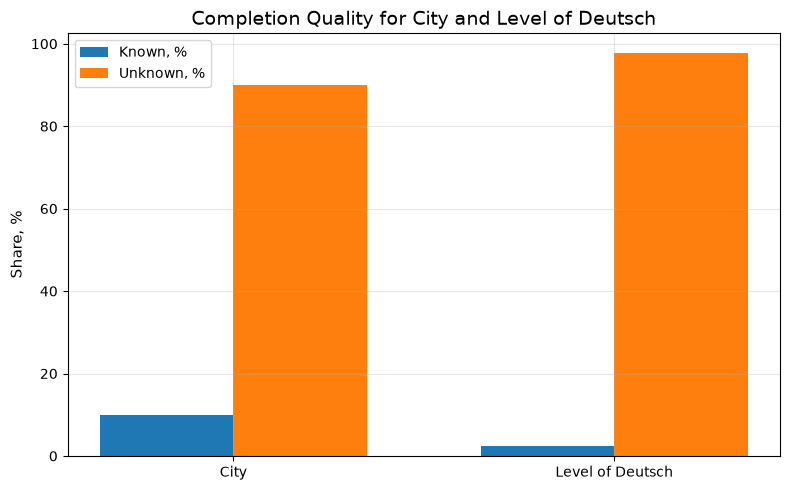

In [180]:
x = np.arange(len(data_quality_geo_plot['Field']))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    data_quality_geo_plot['Known Share, %'],
    width,
    label='Known, %'
)

plt.bar(
    x + width / 2,
    data_quality_geo_plot['Unknown Share, %'],
    width,
    label='Unknown, %'
)

plt.xticks(
    x,
    data_quality_geo_plot['Field']
)

plt.ylabel('Share, %')
plt.title('Completion Quality for City and Level of Deutsch')
plt.legend()
plt.tight_layout()
plt.show()

### Geographic Analysis Summary

Geographic analysis is limited by data completeness. `City = Unknown` accounts for 89.98% of all deals: 19,430 out of 21,593. This means the customer city was usually not recorded or cannot be reliably used for analysis.

Among known cities, `Berlin` stands out: 182 deals, 78 paid deals, 86,450 revenue and 42.86% payment conversion. It is the largest known city by deals and paid deals. Other visible cities include `München`, `Hamburg`, `Leipzig` and `Nürnberg`.

Several known cities show high conversion, but the samples are small. Even `Berlin` represents only 0.84% of all deals, so these results cannot be interpreted as stable city-level advantages without additional validation.

German language level is even more limited: `Level of Deutsch = Unknown` accounts for 97.70% of all deals. Among known levels, `B1` is the most representative, with 382 deals, 137 paid deals and 152,550 revenue. Other levels have much smaller samples.

Only 430 deals have both `City` and `Level of Deutsch` filled. Therefore, the city-language relationship can be used only as a supporting view.

For more reliable future analysis, CRM completion for `City` and `Level of Deutsch` should be improved, especially for paid deals and late-stage leads.

### Key Observations

- `City = Unknown` accounts for 89.98% of all deals, so geographic analysis is limited.
- Among known cities, `Berlin` leads with 182 deals, 78 paid deals and 86,450 revenue.
- Some cities show high conversion, but sample sizes are small.
- `Level of Deutsch = Unknown` accounts for 97.70% of all deals.
- The most representative known language level is `B1`: 382 deals, 137 paid deals and 152,550 revenue.
- High conversion for very small levels such as `A1` or `C1` should not be treated as stable.
- Only 430 deals have both `City` and `Level of Deutsch` filled.
- Future analysis requires better CRM completion for city and language level.

## Financial Summary

This section summarizes revenue metrics for paid deals.

The goal is to capture:

- total revenue;
- average and median check;
- revenue by source;
- revenue by product;
- revenue by manager;
- financial data limitations.

Unit economics is not calculated in this section and is covered in a separate stage.

In [181]:
financial_summary = {
    'Paid Deals': paid_deals.shape[0],
    'Deals with Calculated Revenue': deals_with_revenue.shape[0],
    'Total Revenue': deals_with_revenue['Revenue'].sum(),
    'Average Check': deals_with_revenue['Revenue'].mean(),
    'Median Check': deals_with_revenue['Revenue'].median(),
    'Minimum Payment': deals_with_revenue['Revenue'].min(),
    'Maximum Payment': deals_with_revenue['Revenue'].max(),
    'Payment Done without Payment Amount': deals['Unknown Payment Amount'].sum(),
    'Symbolic Payments': deals['Is Symbolic Payment'].sum()
}

financial_summary_df = pd.DataFrame(
    financial_summary.items(),
    columns=['Metric', 'Value']
)

financial_summary_df

,Metric,Value
0,Paid Deals,858.00
1,Deals with Calculated Revenue,843.00
2,Total Revenue,"978,651.00"
3,Average Check,"1,160.91"
4,Median Check,"1,000.00"
5,Minimum Payment,0.00
6,Maximum Payment,"11,500.00"
7,Payment Done without Payment Amount,15.00
8,Symbolic Payments,4.00


### Revenue by Source

I review which sources contribute the most to revenue.

In [182]:
revenue_by_source = (
    deals_with_revenue
    .groupby('Source', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

revenue_by_source['Revenue Share, %'] = (
    revenue_by_source['revenue'] / revenue_by_source['revenue'].sum() * 100
).round(2)

revenue_by_source = revenue_by_source.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

revenue_by_source = revenue_by_source.sort_values(
    'Revenue',
    ascending=False
)

revenue_by_source

,Source,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Revenue Share, %"
2,Facebook Ads,197,"236,150.00","1,198.73","1,000.00",24.13
4,Organic,146,"183,451.00","1,256.51","1,000.00",18.75
3,Google Ads,169,"174,850.00","1,034.62","1,000.00",17.87
6,SMM,88,"99,750.00","1,133.52","1,000.00",10.19
9,Tiktok Ads,56,"66,650.00","1,190.18","1,000.00",6.81
11,Youtube Ads,53,"62,950.00","1,187.74","1,000.00",6.43
10,Webinar,26,"55,150.00","2,121.15","1,000.00",5.64
7,Telegram posts,39,"45,450.00","1,165.38","1,000.00",4.64
0,Bloggers,39,"33,100.00",848.72,"1,000.00",3.38
1,CRM,23,"15,600.00",678.26,"1,000.00",1.59


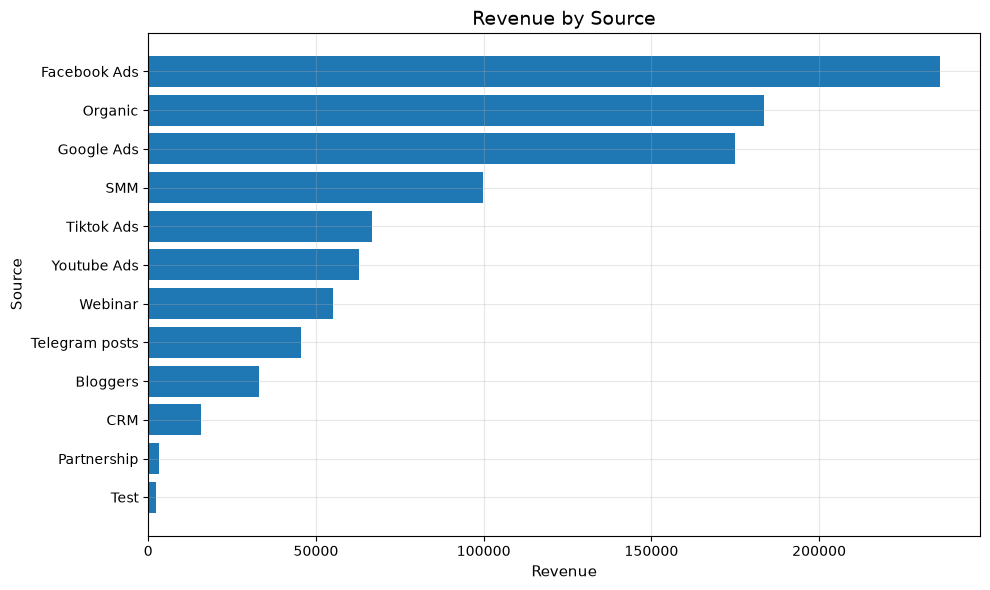

In [183]:
revenue_by_source_plot = revenue_by_source.sort_values(
    'Revenue',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_by_source_plot['Source'],
    revenue_by_source_plot['Revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Source')
plt.title('Revenue by Source')
plt.tight_layout()
plt.show()

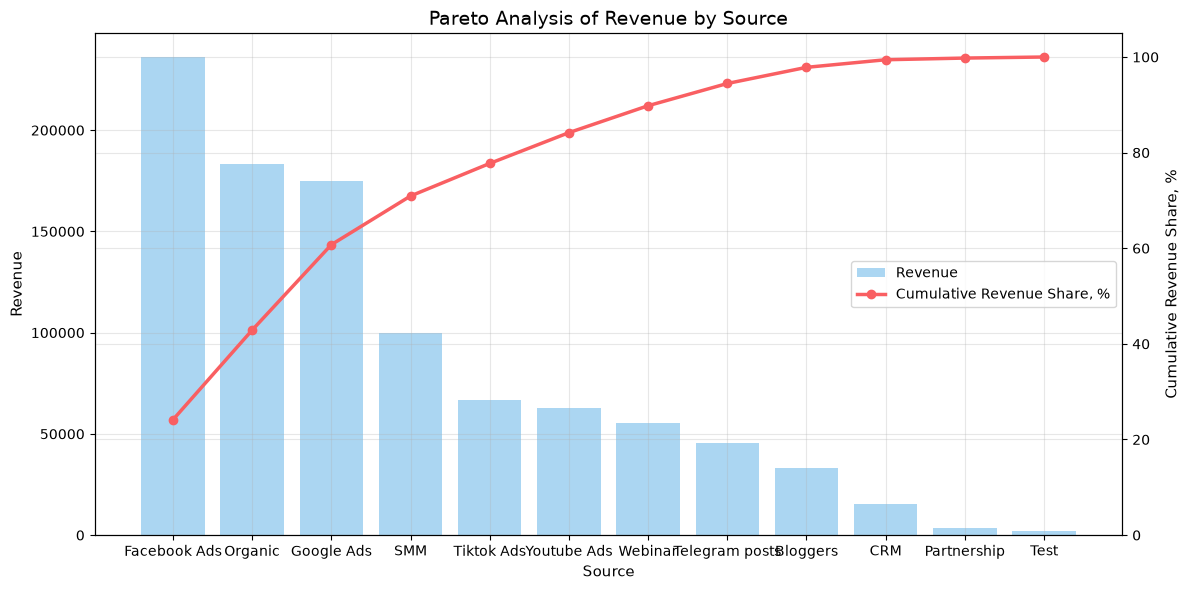

In [184]:
revenue_pareto_source = revenue_by_source.sort_values(
    'Revenue',
    ascending=False
).copy()

revenue_pareto_source['Cumulative Revenue'] = revenue_pareto_source['Revenue'].cumsum()

revenue_pareto_source['Cumulative Revenue Share, %'] = (
    revenue_pareto_source['Cumulative Revenue'] /
    revenue_pareto_source['Revenue'].sum() * 100
).round(2)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    revenue_pareto_source['Source'],
    revenue_pareto_source['Revenue'],
    label='Revenue',
    color=bar_color,
    alpha=0.85
)

ax1.set_xlabel('Source')
ax1.set_ylabel('Revenue')

ax2 = ax1.twinx()

ax2.plot(
    revenue_pareto_source['Source'],
    revenue_pareto_source['Cumulative Revenue Share, %'],
    marker='o',
    linewidth=2.5,
    color=line_color,
    label='Cumulative Revenue Share, %'
)

ax2.set_ylabel('Cumulative Revenue Share, %')
ax2.set_ylim(0, 105)

plt.title('Pareto Analysis of Revenue by Source')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='right'
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Revenue by Product

I review product contribution to total revenue.

In [185]:
revenue_by_product = (
    deals_with_revenue
    .groupby('Product', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

revenue_by_product['Revenue Share, %'] = (
    revenue_by_product['revenue'] / revenue_by_product['revenue'].sum() * 100
).round(2)

revenue_by_product = revenue_by_product.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

revenue_by_product = revenue_by_product.sort_values(
    'Revenue',
    ascending=False
)

revenue_by_product

,Product,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Revenue Share, %"
0,Digital Marketing,474,"556,600.00","1,174.26","1,000.00",56.87
2,UX/UI Design,229,"278,600.00","1,216.59","1,000.00",28.47
4,Web Developer,137,"143,450.00","1,047.08","1,000.00",14.66
1,Find yourself in IT,1,1.00,1.00,1.00,0.00
3,Unknown,2,0.00,0.00,0.00,0.00


### Revenue by Manager

I review which managers contribute the most to revenue.

In [186]:
revenue_by_manager = (
    deals_with_revenue
    .groupby('Deal Owner Name', dropna=False)
    .agg(
        paid_deals=('Id', 'count'),
        revenue=('Revenue', 'sum'),
        avg_revenue=('Revenue', 'mean'),
        median_revenue=('Revenue', 'median')
    )
    .reset_index()
)

revenue_by_manager['Revenue Share, %'] = (
    revenue_by_manager['revenue'] / revenue_by_manager['revenue'].sum() * 100
).round(2)

revenue_by_manager = revenue_by_manager.rename(columns={
    'paid_deals': 'Paid Deals',
    'revenue': 'Revenue',
    'avg_revenue': 'Avg Revenue',
    'median_revenue': 'Median Revenue'
})

revenue_by_manager = revenue_by_manager.sort_values(
    'Revenue',
    ascending=False
)

revenue_by_manager.head(15)

,Deal Owner Name,Paid Deals,Revenue,Avg Revenue,Median Revenue,"Revenue Share, %"
1,Cara Iverson,27,"151,900.00","5,625.93","5,000.00",15.52
2,Charlie Davis,148,"141,750.00",957.77,"1,000.00",14.48
16,Ulysses Adams,141,"127,100.00",901.42,"1,000.00",12.99
14,Paula Underwood,93,"101,650.00","1,093.01","1,000.00",10.39
9,Julia Nelson,93,"85,051.00",914.53,"1,000.00",8.69
15,Quincy Vincent,65,"72,400.00","1,113.85","1,000.00",7.40
18,Victor Barnes,44,"66,700.00","1,515.91","1,000.00",6.82
0,Ben Hall,46,"58,700.00","1,276.09","1,000.00",6.00
13,Oliver Taylor,50,"50,250.00","1,005.00","1,000.00",5.13
12,Nina Scott,45,"40,700.00",904.44,"1,000.00",4.16


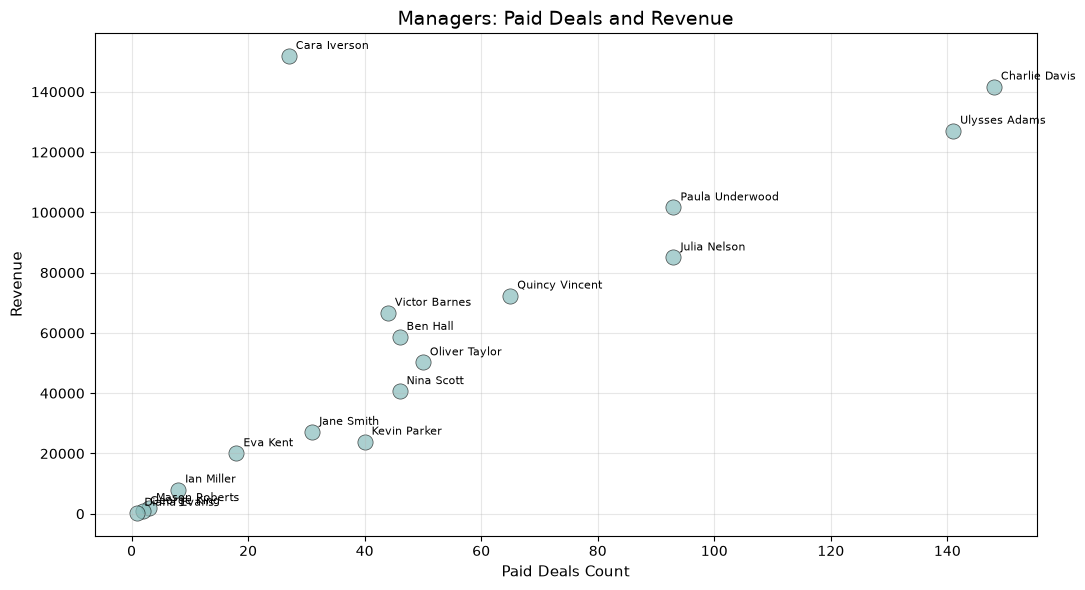

In [187]:
manager_paid_revenue_plot = manager_summary[
    (manager_summary['Paid Deals'] > 0) &
    (manager_summary['Revenue'] > 0)
].copy()

plt.figure(figsize=(11, 6))

plt.scatter(
    manager_paid_revenue_plot['Paid Deals'],
    manager_paid_revenue_plot['Revenue'],
    s=120,
    alpha=0.7,
    color=scatter_color,
    edgecolors='black',
    linewidth=0.5
)

for _, row in manager_paid_revenue_plot.iterrows():
    plt.annotate(
        row['Deal Owner Name'],
        xy=(row['Paid Deals'], row['Revenue']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.xlabel('Paid Deals Count')
plt.ylabel('Revenue')
plt.title('Managers: Paid Deals and Revenue')

plt.tight_layout()
plt.show()

### Financial Data Limitations

I capture limitations that should be considered when interpreting financial metrics.

In [188]:
financial_data_limitations = {
    'Payment Done without Payment Amount': deals['Unknown Payment Amount'].sum(),
    'Symbolic Payments': deals['Is Symbolic Payment'].sum(),
    'Initial Amount Paid > Offer Total Amount': deals['Initial Amount Greater Than Offer'].sum(),

    'Paid Deals without Product': (
        (deals['Is Paid'] == True) &
        (deals['Product'].isna() | (deals['Product'] == 'Unknown'))
    ).sum(),

    'Paid Deals without Payment Type': (
        (deals['Is Paid'] == True) &
        (deals['Payment Type'].isna() | (deals['Payment Type'] == 'Unknown'))
    ).sum(),

    'Paid Deals without Education Type': (
        (deals['Is Paid'] == True) &
        (deals['Education Type'].isna() | (deals['Education Type'] == 'Unknown'))
    ).sum()
}

financial_data_limitations_df = pd.DataFrame(
    financial_data_limitations.items(),
    columns=['Limitation', 'Rows']
)

financial_data_limitations_df

,Limitation,Rows
0,Payment Done without Payment Amount,15
1,Symbolic Payments,4
2,Initial Amount Paid > Offer Total Amount,58
3,Paid Deals without Product,17
4,Paid Deals without Payment Type,494
5,Paid Deals without Education Type,25


### Financial Summary Conclusions

The dataset contains 858 paid deals, of which 843 have calculated revenue. Total recorded revenue is 978,651.

The average check is 1,160.91 and the median check is 1,000.00. This means the typical payment is close to 1,000, while several larger payments increase the average. The maximum payment is 11,500.

By source, the largest revenue contributors are `Facebook Ads`, `Organic` and `Google Ads`. `Facebook Ads` generates 236,150 revenue, or 24.13% of total revenue. `Organic` generates 183,451 revenue without advertising spend in the `Spend` table. `Google Ads` generates 174,850 revenue, but earlier marketing analysis showed weaker cost efficiency compared with several other channels.

By product, almost all revenue is concentrated in `Digital Marketing`, `UX/UI Design` and `Web Developer`. `Digital Marketing` contributes 556,600 revenue, or 56.87% of total revenue. `UX/UI Design` contributes 278,600, and `Web Developer` contributes 143,450.

By manager, `Cara Iverson` generates the highest revenue at 151,900, despite only 27 paid deals. This is explained by a much higher average and median check. `Charlie Davis` and `Ulysses Adams` remain strong by the combination of paid deal volume and revenue.

Financial interpretation should account for several limitations: 15 paid deals without payment amount, 4 symbolic payments, 58 rows where `Initial Amount Paid > Offer Total Amount`, 17 paid deals without product, 494 paid deals without payment type and 25 paid deals without education format. The largest limitation is `Payment Type`, which is missing for more than half of paid deals.

### Key Observations

- Total recorded revenue is 978,651.
- Average check is 1,160.91 and median check is 1,000.00.
- Main revenue sources are `Facebook Ads`, `Organic` and `Google Ads`.
- `Organic` generates meaningful revenue without advertising spend in `Spend`.
- The main revenue product is `Digital Marketing`, which accounts for 56.87% of total revenue.
- `UX/UI Design` and `Web Developer` rank second and third by financial contribution.
- `Cara Iverson` generates the highest manager revenue because of a high average and median check.
- `Charlie Davis` and `Ulysses Adams` are strong by both paid deals and revenue.
- Main financial limitations: paid deals without payment amount, missing `Payment Type`, missing product and rows where `Initial Amount Paid > Offer Total Amount`.

## Final Conclusions from EDA and Business Analysis

This analysis reviewed cleaned online school data across deals, marketing spend, contacts and calls.

The objective was to understand which sources, campaigns, managers, products and lead characteristics are associated with payments, revenue and sales efficiency.

### Key Findings

**1. The sales funnel is strongly shifted toward lost deals.**

The dataset contains 21,593 deals, of which 858 have `Payment Done`. Overall payment conversion is 3.97%. The largest stage is `Lost`, with 15,743 deals or 72.91% of the funnel. This suggests that growth should focus not only on lead volume, but also on lead quality, response speed and movement toward payment.

---

**2. Lead growth does not automatically increase paid deals.**

The largest number of created deals was in April 2024, with 3,082 deals. The highest number of paid deals was earlier, in January 2024, with 114 paid deals. Conversion was higher in late 2023 and January 2024, then declined. Lead volume alone does not guarantee sales growth.

---

**3. Calls are related to deal volume but less strongly related to payments.**

Monthly correlation between deals and calls is high at 0.93, showing that sales activity followed incoming lead flow. Correlation between calls and paid deals is lower at 0.47, so call volume is an activity indicator but does not explain results on its own.

---

**4. Marketing sources differ by scale, lead quality and financial efficiency.**

The largest deal sources are `Facebook Ads`, `Google Ads`, `Organic`, `Tiktok Ads` and `SMM`. Revenue leaders are `Facebook Ads`, `Organic` and `Google Ads`. `Facebook Ads` provides the largest paid volume and revenue, `Organic` performs strongly without recorded ad spend, `SMM` and `Webinar` look efficient by spend-to-revenue metrics, and `Google Ads` requires further optimization due to higher acquisition cost.

---

**5. Campaigns should be evaluated by several metrics, not only lead volume.**

The largest campaign by volume is `performancemax_digitalmarkt_ru_DE`, but it does not have the highest conversion. Smaller campaigns such as `Trigger_DE`, `brand_search_eng_DE` and `gen_analyst_DE` show stronger conversion or lead quality, but need careful interpretation due to lower volumes.

---

**6. Sales manager performance differs by workload, conversion, revenue and average check.**

`Charlie Davis` and `Ulysses Adams` are strong by paid deals and revenue. `Oliver Taylor` has the highest conversion but a much smaller deal volume. `Cara Iverson` stands out with the highest revenue because of a much higher average check, which suggests a different deal structure.

---

**7. SLA matters, but it is not the only success factor.**

The highest payment conversion is in the `5–15 min` SLA group, not the fastest `0–5 min` group. Response delays above 24 hours are associated with lower conversion. The largest deal volume is in the `1–24 hours` group, so improving this range may have a meaningful business effect.

---

**8. Product revenue is concentrated in three main directions.**

`Digital Marketing` is the main product by paid deals and revenue, followed by `UX/UI Design` and `Web Developer`. `UX/UI Design` has a slightly higher average check, but lower paid volume.

---

**9. Education format and payment type affect revenue structure.**

`Morning` dominates among paid deals and revenue. `One Payment` has a higher average and median check, while `Recurring Payments` are more frequent but have a lower first payment. The large share of `Unknown Payment Type` limits interpretation.

---

**10. Geographic and language-level analysis is limited by data quality.**

`City = Unknown` accounts for 89.98% of deals and `Level of Deutsch = Unknown` accounts for 97.70%. These fields are useful only as additional cuts until CRM completion improves.

### Main Data Limitations

The following limitations should be considered when interpreting results:

- 15 paid deals have no recorded payment amount;
- 4 deals are symbolic payments;
- 58 deals have `Initial Amount Paid > Offer Total Amount`;
- 17 paid deals have no recorded product;
- 494 paid deals have no recorded payment type;
- 25 paid deals have no recorded education format;
- `City` is unknown for 89.98% of deals;
- `Level of Deutsch` is unknown for 97.70% of deals;
- campaign-level spend is only partially matched with `Deals`;
- `Call Owner Name` and `Deal Owner Name` may reflect different roles, so calls cannot be directly interpreted as performance of a specific deal owner.

### Business Recommendations

Based on the analysis, several improvement directions can be identified.

**1. Optimize high-volume lead sources.**

`Facebook Ads` and `Google Ads` generate large deal and payment volume but require different strategies. `Facebook Ads` looks strong by scale and revenue contribution. `Google Ads` contributes meaningful volume, but should be optimized by campaign efficiency and lead quality.

**2. Scale efficient channels with good returns.**

`SMM`, `Webinar`, `Telegram posts` and `Organic` show strong results across selected metrics. They should be reviewed for scalability, audience quality and repeatability.

**3. Evaluate campaigns by payments, not only leads.**

Large campaigns are not always the most efficient. Marketing management should use a metric set that includes deals, paid deals, conversion, lead quality, revenue and spend.

**4. Compare managers with source mix in mind.**

Manager results depend not only on individual work, but also on lead sources, lead quality, product mix and workload. Fair comparison requires controlling for the incoming lead flow.

**5. Improve SLA control.**

Delays above 24 hours are associated with lower conversion. Since most deals fall into the `1–24 hours` group, improving response processes within this range may produce a visible business effect.

**6. Strengthen product focus.**

`Digital Marketing`, `UX/UI Design` and `Web Developer` generate almost all revenue. Further analysis should review sources, managers and payment types within these products.

**7. Improve CRM data quality.**

Better completion is needed for `Payment Type`, `Product`, `Education Type`, `City` and `Level of Deutsch`, especially for paid deals and late-stage leads.